In [1]:
import scienceplots
import matplotlib.pyplot as plt
plt.style.use(["science", "grid"])

import warnings
warnings.filterwarnings("ignore")

# Hit and Hi visualisation
We performed experiments using 10 different random initializations. For each run, we calculated the mean squared error (MSE) loss between the predicted output and the ground truth. The result with the minimum loss was selected, along with its associated neural parameter calibration (NPC) cumulative dengue cases prediction. These NPC predictions can then be compared with cumulative dengue cases predicted by Markov Chain Monte Carlo (MCMC) sampling.

In [2]:
import os
import torch
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def select_best_Hit(data, Hit_true):
    """
    For each set of Hit in data, compute the MSE loss with Hit_true,
    and return the Hit set with the lowest loss.
    """
    Hit_true_tensor = torch.tensor(Hit_true, dtype=torch.float32).log1p()
    min_loss = float('inf')
    best_Hit = None
    mse_loss = torch.nn.MSELoss()
    for i in range(data.shape[0]):
        Hit_tensor = torch.tensor(data[i], dtype=torch.float32).log1p()
        loss = mse_loss(Hit_tensor, Hit_true_tensor)
        if loss < min_loss:
            min_loss = loss
            best_Hit = data[i]
    print(f"MSE loss of NPC: {min_loss.item()}")
    return best_Hit

def npc_Hit_pred(base_dir, Hit_true):
    """
        Compute the median and standard deviation of NPC Hit predictions across all unis in the given base directory.
    """
    uni_dirs = sorted(glob.glob(os.path.join(base_dir, "uni*/data_pred_obser.csv")))

    # Load all nn_prediction columns into a list of Series
    npc_predictions = []
    for csv_path in uni_dirs:
        df = pd.read_csv(csv_path)
        if "nn_prediction" in df.columns:
            npc_predictions.append(df["nn_prediction"].reset_index(drop=True))

    # Align all series to the shortest length
    min_len = min(len(s) for s in npc_predictions)
    npc_predictions = [s.iloc[:min_len] for s in npc_predictions]
    data = np.stack([s.values for s in npc_predictions])

    # Compute median and std for Hit across unis for each time point
    Hit_npc = select_best_Hit(data, Hit_true)
    Hit_npc_std = np.std(data, axis=0)

    # Compute Hi (weekly cases) and its std across unis
    hi_npc_all = np.diff(data, axis=1, prepend=data[:, [0]])  # shape: (n_unis, n_time)
    Hit_npc_diff = np.insert(Hit_npc, 0, Hit_true[0])
    hi_npc = np.diff(Hit_npc_diff)  # shape: (n_time,)
    hi_npc_std = np.std(hi_npc_all, axis=0)

    return (
        pd.Series(Hit_npc),
        pd.Series(Hit_npc_std),
        pd.Series(hi_npc),
        pd.Series(hi_npc_std)
    )


### Bello

In [3]:
# BELLO DATA
# Ground truth
bello_hi_true = pd.read_csv(
    '../data/Dengue/bello/DataBello_full.csv')[737:785]['Cases'].reset_index(drop=True)
bello_Hit_true = bello_hi_true.cumsum()

# MCMC predictions
bello_mcmc = pd.read_csv(
    "bello/data_bello_Hit_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
bello_Hit_mcmc = bello_mcmc["CumulativeHumanInfected_mcmc"]
bello_hi_mcmc = bello_Hit_mcmc.diff().fillna(bello_Hit_mcmc.iloc[0])

# NPC predictions
bello_Hit_npc, bello_Hit_npc_std, bello_hi_npc, bello_hi_npc_std = npc_Hit_pred("./bello/data", bello_Hit_true)

MSE loss of NPC: 0.003178004175424576


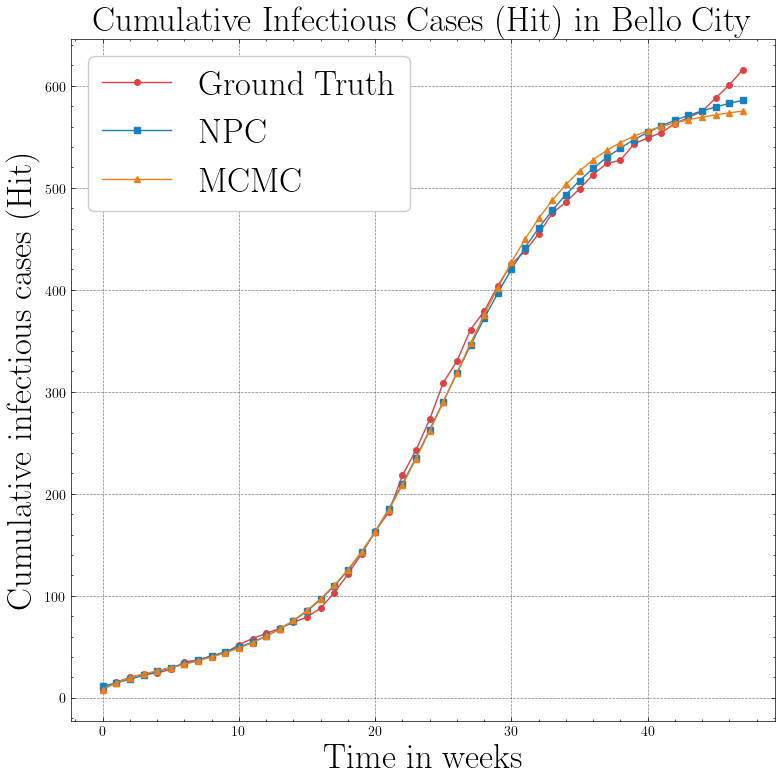

In [4]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# Bello cumulative
plt.plot(bello_Hit_true, label="Ground Truth", marker='o', 
               color='#DD4143',markersize=4)
plt.plot(bello_Hit_npc, label="NPC", marker='s', 
               color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(bello_Hit_npc)),
#     bello_Hit_npc - bello_Hit_npc_std,
#     bello_Hit_npc + bello_Hit_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(bello_Hit_mcmc, label="MCMC", marker='^', 
               color='#ea801c', markersize=4)
plt.title("Cumulative Infectious Cases (Hit) in Bello City", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Cumulative infectious cases (Hit)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# export_path = "final_figures/Hit_hi/bello_Hit.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

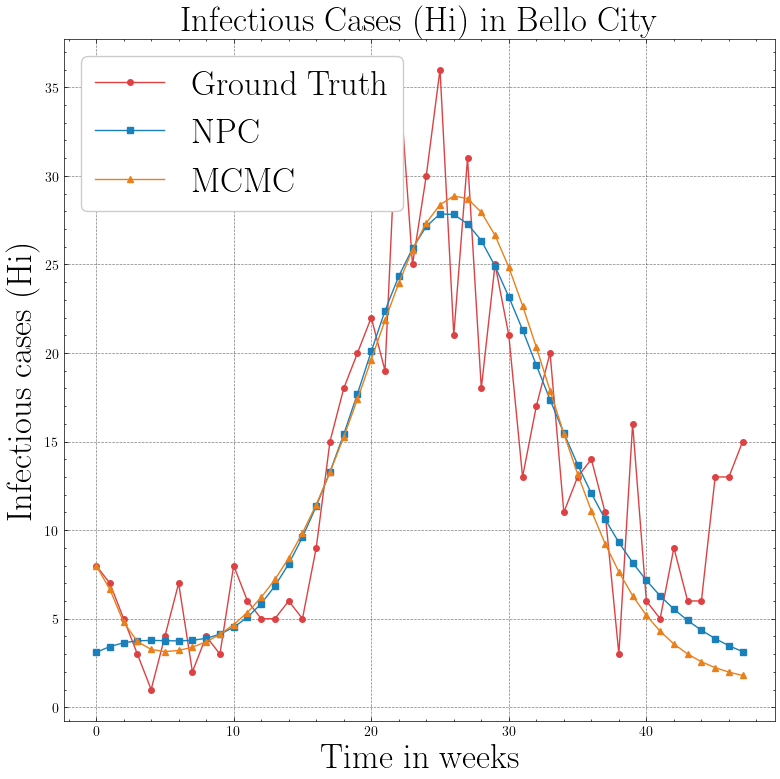

In [5]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# cumulative
plt.plot(bello_hi_true, label="Ground Truth", marker='o', 
               color='#DD4143',markersize=4)
plt.plot(bello_hi_npc, label="NPC", marker='s', 
               color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(bello_hi_npc)),
#     bello_hi_npc - bello_hi_npc_std,
#     bello_hi_npc + bello_hi_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(bello_hi_mcmc, label="MCMC", marker='^', 
               color='#ea801c', markersize=4)
plt.title("Infectious Cases (Hi) in Bello City", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Infectious cases (Hi)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# export_path = "final_figures/Hit_hi/bello_hi.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

### Iquitos

In [6]:
# IQUITOS DATA
# Ground truth
iquitos_hi_true = pd.read_csv(
    '../data/Dengue/iquitos/DataIquitos_full.csv')[265:313]['Cases'].reset_index(drop=True)
iquitos_Hit_true = iquitos_hi_true.cumsum()

# MCMC predictions
iquitos_mcmc = pd.read_csv(
    "iquitos/data_iquitos_Hit_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
iquitos_Hit_mcmc = iquitos_mcmc["CumulativeHumanInfected_mcmc"]
iquitos_hi_mcmc = iquitos_Hit_mcmc.diff().fillna(iquitos_Hit_mcmc.iloc[0])

# NPC predictions
iquitos_Hit_npc, iquitos_Hit_npc_std, iquitos_hi_npc, iquitos_hi_npc_std = npc_Hit_pred("./iquitos/data", iquitos_Hit_true)

MSE loss of NPC: 0.008636112324893475


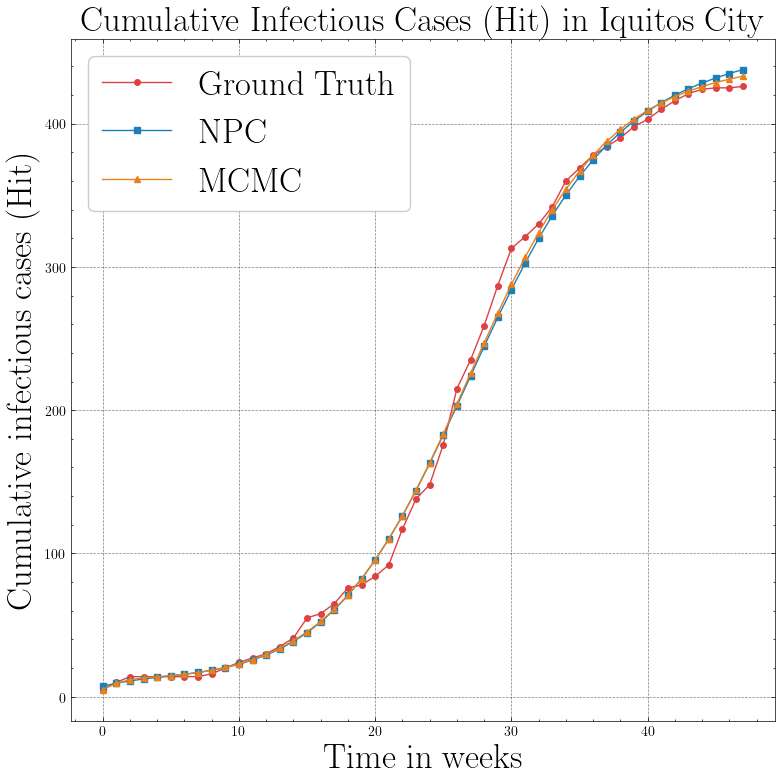

In [7]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# Iquitos cumulative
plt.plot(iquitos_Hit_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(iquitos_Hit_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(iquitos_Hit_npc)),
#     iquitos_Hit_npc - iquitos_Hit_npc_std,
#     iquitos_Hit_npc + iquitos_Hit_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(iquitos_Hit_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Cumulative Infectious Cases (Hit) in Iquitos City", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Cumulative infectious cases (Hit)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# export_path = "final_figures/Hit_hi/iquitos_Hit.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

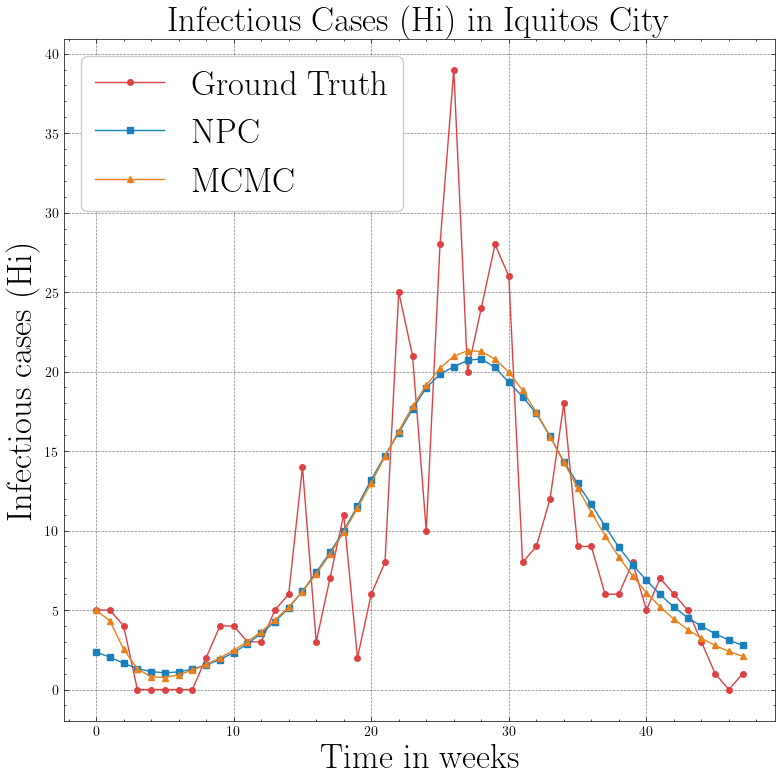

In [8]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# cumulative
plt.plot(iquitos_hi_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(iquitos_hi_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(iquitos_hi_npc)),
#     iquitos_hi_npc - iquitos_hi_npc_std,
#     iquitos_hi_npc + iquitos_hi_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(iquitos_hi_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Infectious Cases (Hi) in Iquitos City", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Infectious cases (Hi)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# Export the figure to a PDF file
# export_path = "final_figures/Hit_hi/iquitos_hi.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

### SanJuan

In [9]:
# SAN JUAN DATA
# Ground truth
sanjuan_hi_true = pd.read_csv(
    '../data/Dengue/sanjuan/DataSanJuan_full.csv')[570:618]['Cases'].reset_index(drop=True)
sanjuan_Hit_true = sanjuan_hi_true.cumsum()

# MCMC predictions
sanjuan_mcmc = pd.read_csv(
    "sanjuan/data_sanjuan_Hit_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
sanjuan_Hit_mcmc = sanjuan_mcmc["CumulativeHumanInfected_mcmc"]
sanjuan_hi_mcmc = sanjuan_Hit_mcmc.diff().fillna(sanjuan_Hit_mcmc.iloc[0])

# NPC predictions
sanjuan_Hit_npc, sanjuan_Hit_npc_std, sanjuan_hi_npc, sanjuan_hi_npc_std = npc_Hit_pred("./sanjuan/data", sanjuan_Hit_true)

MSE loss of NPC: 0.005765948444604874


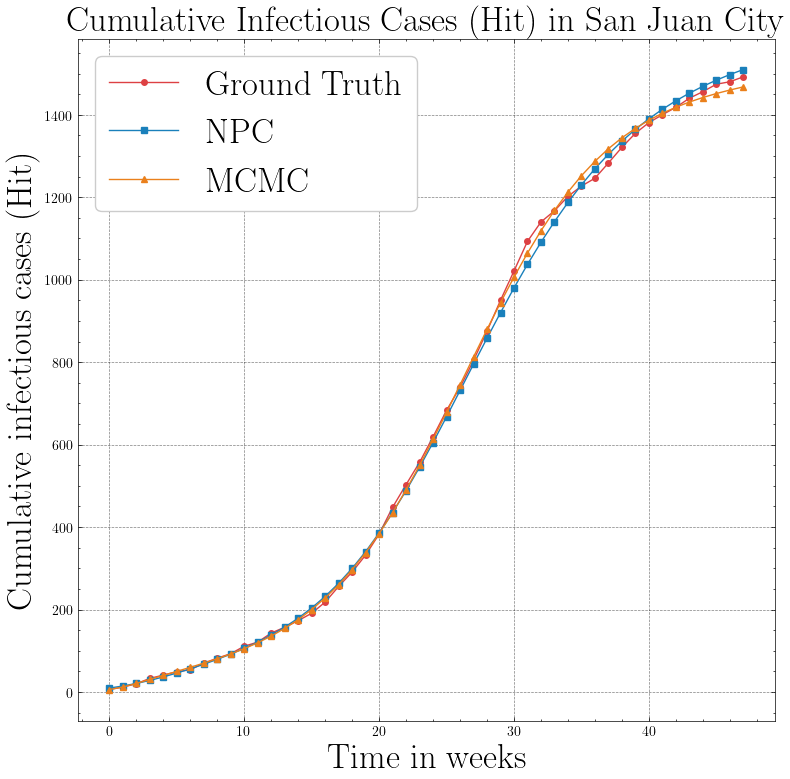

In [10]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# San Juan cumulative
plt.plot(sanjuan_Hit_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(sanjuan_Hit_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(sanjuan_Hit_npc)),
#     sanjuan_Hit_npc - sanjuan_Hit_npc_std,
#     sanjuan_Hit_npc + sanjuan_Hit_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(sanjuan_Hit_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Cumulative Infectious Cases (Hit) in San Juan City", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Cumulative infectious cases (Hit)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# export_path = "final_figures/Hit_hi/sanjuan_Hit.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

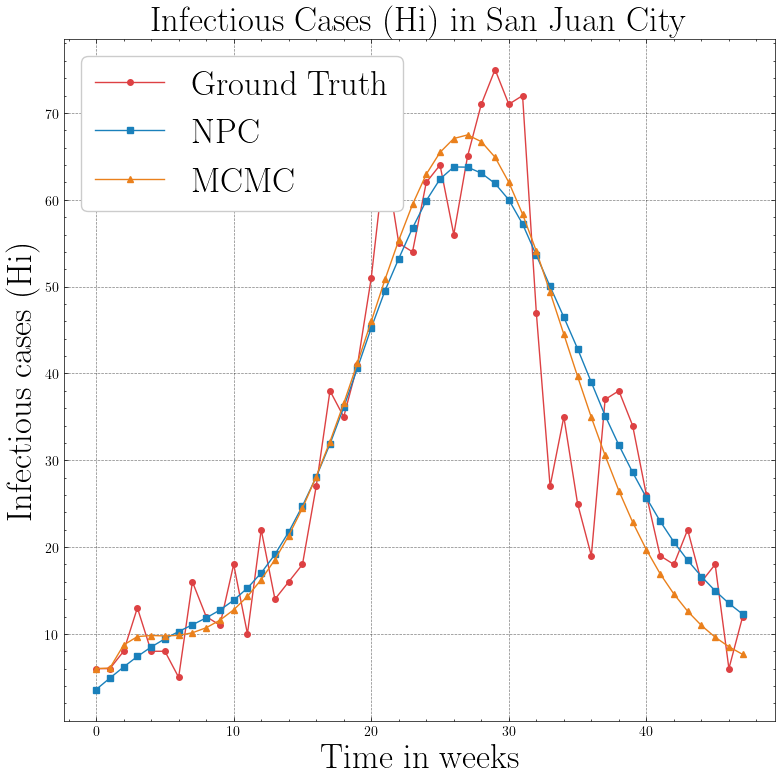

In [11]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# cumulative
plt.plot(sanjuan_hi_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(sanjuan_hi_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(sanjuan_hi_npc)),
#     sanjuan_hi_npc - sanjuan_hi_npc_std,
#     sanjuan_hi_npc + sanjuan_hi_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(sanjuan_hi_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Infectious Cases (Hi) in San Juan City", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Infectious cases (Hi)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# Export the figure to a PDF file
# export_path = "final_figures/Hit_hi/sanjuan_hi.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

### Vietnam

In [12]:
# Vietnam DATA
# MCMC predictions
vietnam = pd.read_csv(
    "vietnam/data_vietnam_Hit_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
vietnam_Hit_mcmc = vietnam["CumulativeHumanInfected_mcmc"].reset_index(drop=True)
vietnam_hi_mcmc = vietnam_Hit_mcmc.diff().fillna(vietnam_Hit_mcmc.iloc[0])

# Ground truth
vietnam_Hit_true = vietnam["CumulativeHumanInfected_true"].reset_index(drop=True)
vietnam_hi_true = vietnam_Hit_true.diff().fillna(vietnam_Hit_true.iloc[0])

# NPC predictions
vietnam_Hit_npc, vietnam_Hit_npc_std, vietnam_hi_npc, vietnam_hi_npc_std = npc_Hit_pred("./vietnam/data", vietnam_Hit_true)

MSE loss of NPC: 0.003762355772778392


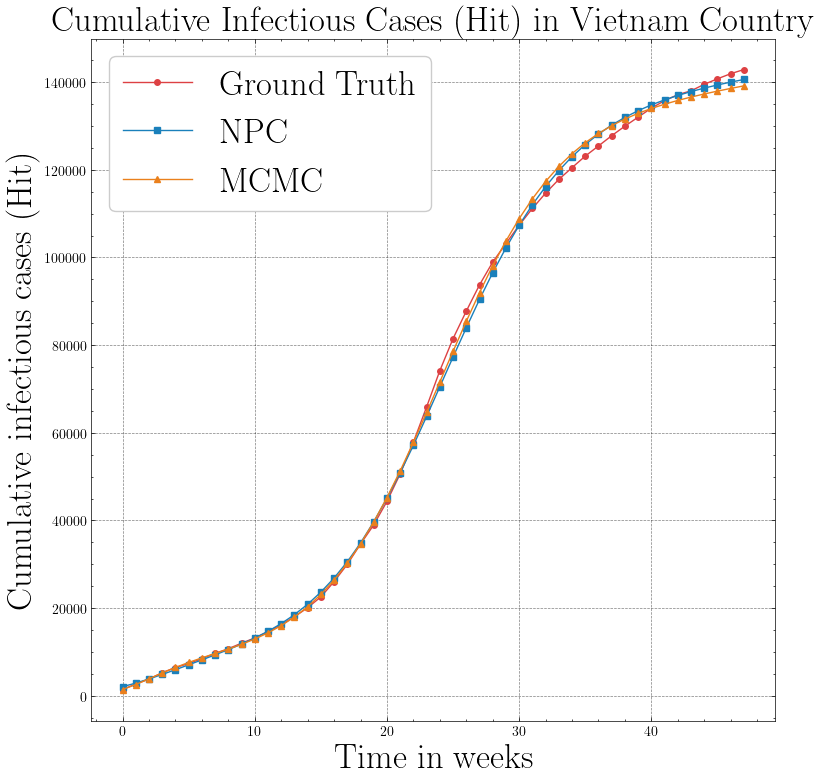

In [13]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# Vietnam cumulative
plt.plot(vietnam_Hit_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(vietnam_Hit_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(vietnam_Hit_npc)),
#     vietnam_Hit_npc - vietnam_Hit_npc_std,
#     vietnam_Hit_npc + vietnam_Hit_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(vietnam_Hit_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Cumulative Infectious Cases (Hit) in Vietnam Country", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Cumulative infectious cases (Hit)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# Export the figure to a PDF file
# export_path = "final_figures/Hit_hi/vietnam_Hit.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

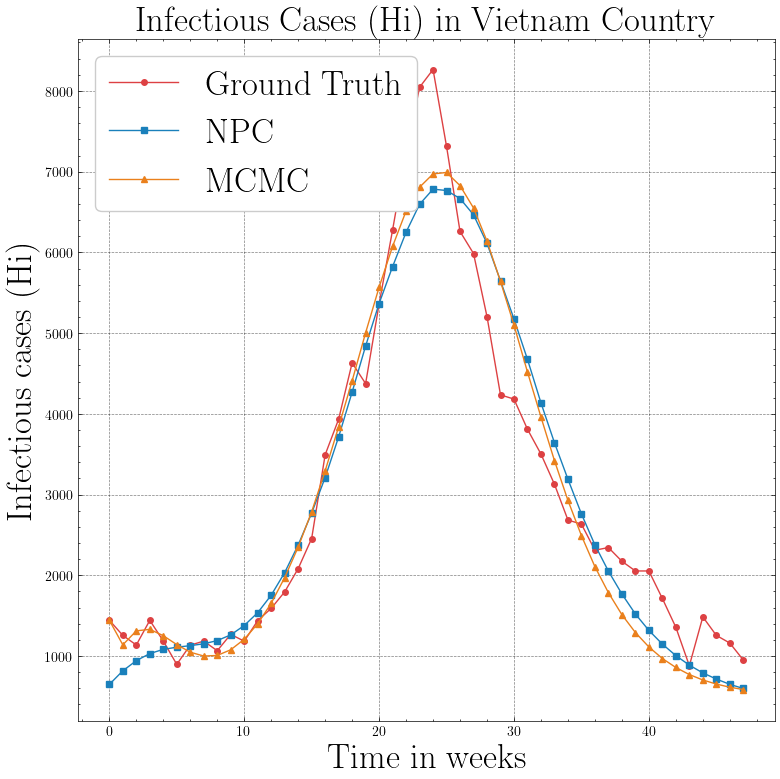

In [14]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# cumulative
plt.plot(vietnam_hi_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(vietnam_hi_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(vietnam_hi_npc)),
#     vietnam_hi_npc - vietnam_hi_npc_std,
#     vietnam_hi_npc + vietnam_hi_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(vietnam_hi_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Infectious Cases (Hi) in Vietnam Country", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Infectious cases (Hi)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# Export the figure to a PDF file
# export_path = "final_figures/Hit_hi/vietnam_hi.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

### Philippines

In [15]:
# Philippines DATA
# MCMC predictions
philippines = pd.read_csv(
    "philippines/data_philippines_Hit_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
philippines_Hit_mcmc = philippines["CumulativeHumanInfected_mcmc"].reset_index(drop=True)
philippines_hi_mcmc = philippines_Hit_mcmc.diff().fillna(philippines_Hit_mcmc.iloc[0])

# Ground truth
philippines_Hit_true = philippines["CumulativeHumanInfected_true"].reset_index(drop=True)
philippines_hi_true = philippines_Hit_true.diff().fillna(philippines_Hit_true.iloc[0])

# NPC predictions
philippines_Hit_npc, philippines_Hit_npc_std, philippines_hi_npc, philippines_hi_npc_std = npc_Hit_pred("./philippines/data", philippines_Hit_true)

MSE loss of NPC: 0.003834296250715852


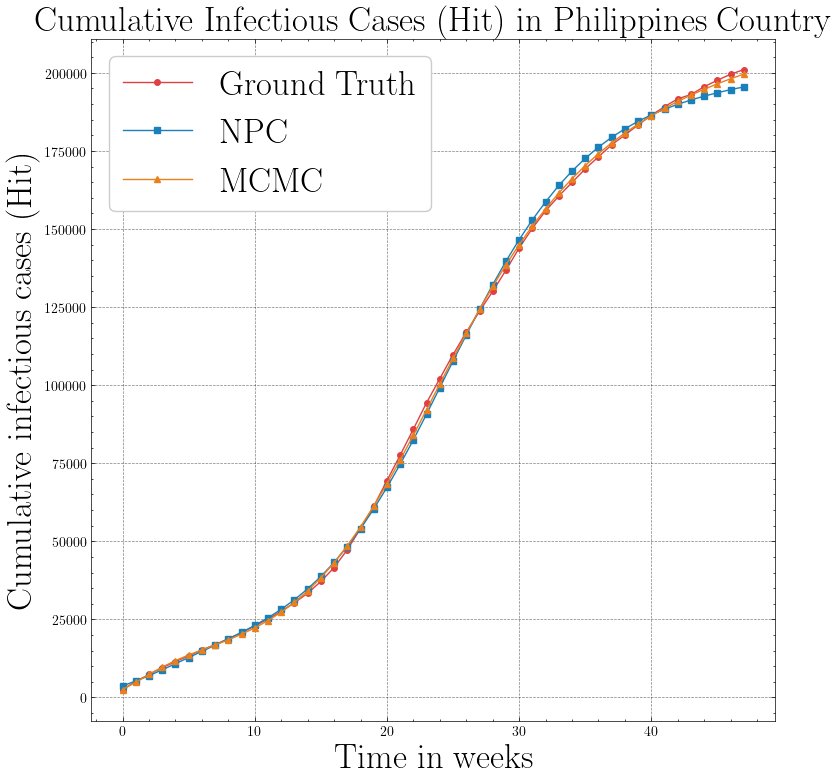

In [16]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# Philippines cumulative
plt.plot(philippines_Hit_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(philippines_Hit_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(philippines_Hit_npc)),
#     philippines_Hit_npc - philippines_Hit_npc_std,
#     philippines_Hit_npc + philippines_Hit_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(philippines_Hit_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Cumulative Infectious Cases (Hit) in Philippines Country", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Cumulative infectious cases (Hit)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# Export the figure to a PDF file
# export_path = "final_figures/Hit_hi/philippines_Hit.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

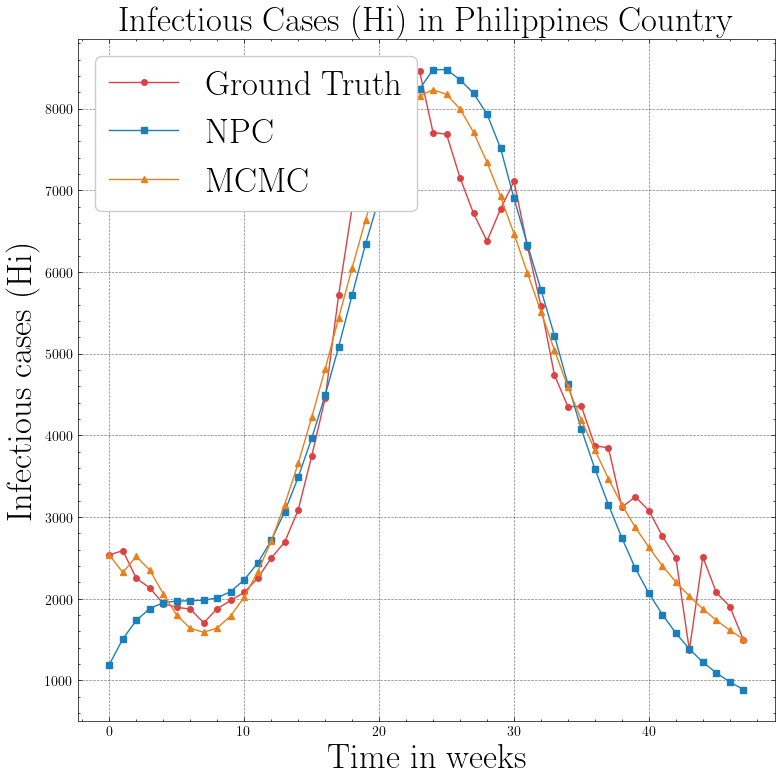

In [17]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# cumulative
plt.plot(philippines_hi_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(philippines_hi_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(philippines_hi_npc)),
#     philippines_hi_npc - philippines_hi_npc_std,
#     philippines_hi_npc + philippines_hi_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(philippines_hi_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Infectious Cases (Hi) in Philippines Country", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Infectious cases (Hi)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# Export the figure to a PDF file
# export_path = "final_figures/Hit_hi/philippines_hi.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

### Cambodia

In [18]:
# Cambodia DATA
# MCMC predictions
cambodia = pd.read_csv(
    "cambodia/data_cambodia_Hit_true_mcmc_cali.csv", index_col=0).reset_index(drop=True)
cambodia_Hit_mcmc = cambodia["CumulativeHumanInfected_mcmc"].reset_index(drop=True)
cambodia_hi_mcmc = cambodia_Hit_mcmc.diff().fillna(cambodia_Hit_mcmc.iloc[0])

# Ground truth
cambodia_Hit_true = cambodia["CumulativeHumanInfected_true"].reset_index(drop=True)
cambodia_hi_true = cambodia_Hit_true.diff().fillna(cambodia_Hit_true.iloc[0])

# NPC predictions
cambodia_Hit_npc, cambodia_Hit_npc_std, cambodia_hi_npc, cambodia_hi_npc_std = npc_Hit_pred("./cambodia/data", cambodia_Hit_true)

MSE loss of NPC: 0.007161302026361227


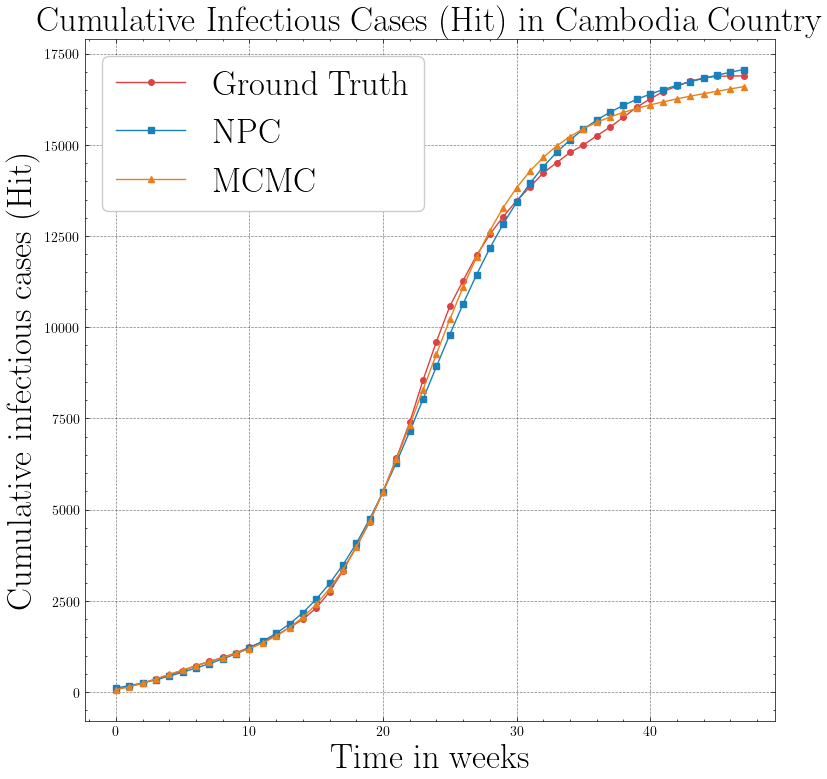

In [19]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# Cambodia cumulative
plt.plot(cambodia_Hit_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(cambodia_Hit_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(cambodia_Hit_npc)),
#     cambodia_Hit_npc - cambodia_Hit_npc_std,
#     cambodia_Hit_npc + cambodia_Hit_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(cambodia_Hit_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Cumulative Infectious Cases (Hit) in Cambodia Country", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Cumulative infectious cases (Hit)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# Export the figure to a PDF file
# export_path = "final_figures/Hit_hi/cambodia_Hit.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

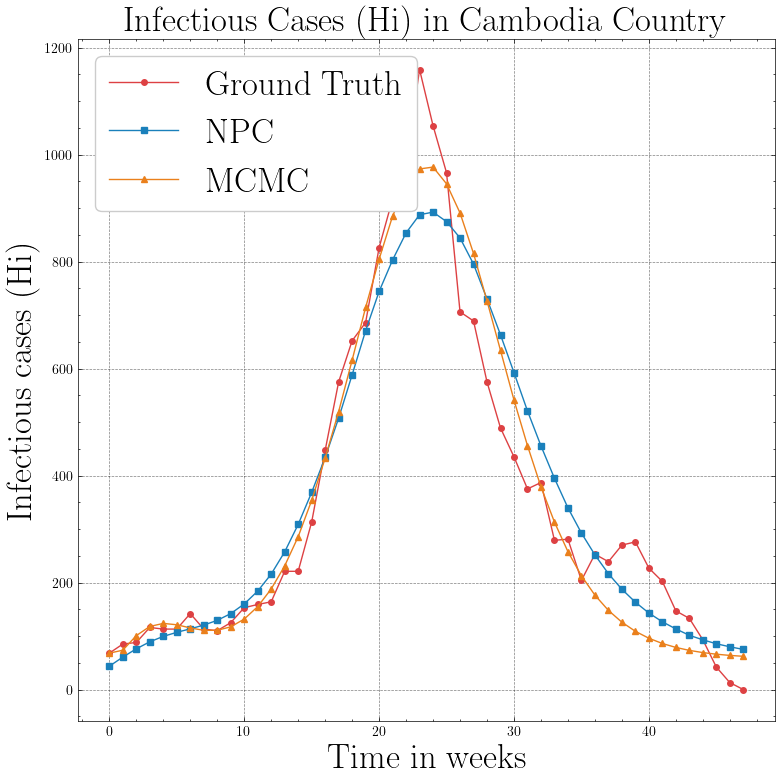

In [20]:
import matplotlib.pyplot as plt

# Create a 2x3 grid: top row for cumulative cases, bottom row for original cases
plt.figure(figsize=(8, 8))

# Top row: Cumulative cases
# cumulative
plt.plot(cambodia_hi_true, label="Ground Truth", marker='o', 
        color='#DD4143',markersize=4)
plt.plot(cambodia_hi_npc, label="NPC", marker='s', 
        color='#1a80bb', markersize=4)
# plt.fill_between(
#     np.arange(len(cambodia_hi_npc)),
#     cambodia_hi_npc - cambodia_hi_npc_std,
#     cambodia_hi_npc + cambodia_hi_npc_std,
#     color="#1a80bb", alpha=0.2
# )
plt.plot(cambodia_hi_mcmc, label="MCMC", marker='^', 
        color='#ea801c', markersize=4)
plt.title("Infectious Cases (Hi) in Cambodia Country", fontsize=25)
plt.xlabel("Time in weeks", fontsize=25)
plt.ylabel("Infectious cases (Hi)", fontsize=25)
plt.grid(True)
plt.legend(loc='upper left', fontsize=25)

plt.tight_layout()
# Export the figure to a PDF file
# export_path = "final_figures/Hit_hi/cambodia_hi.jpg"
# plt.savefig(export_path, dpi=300)
plt.show()

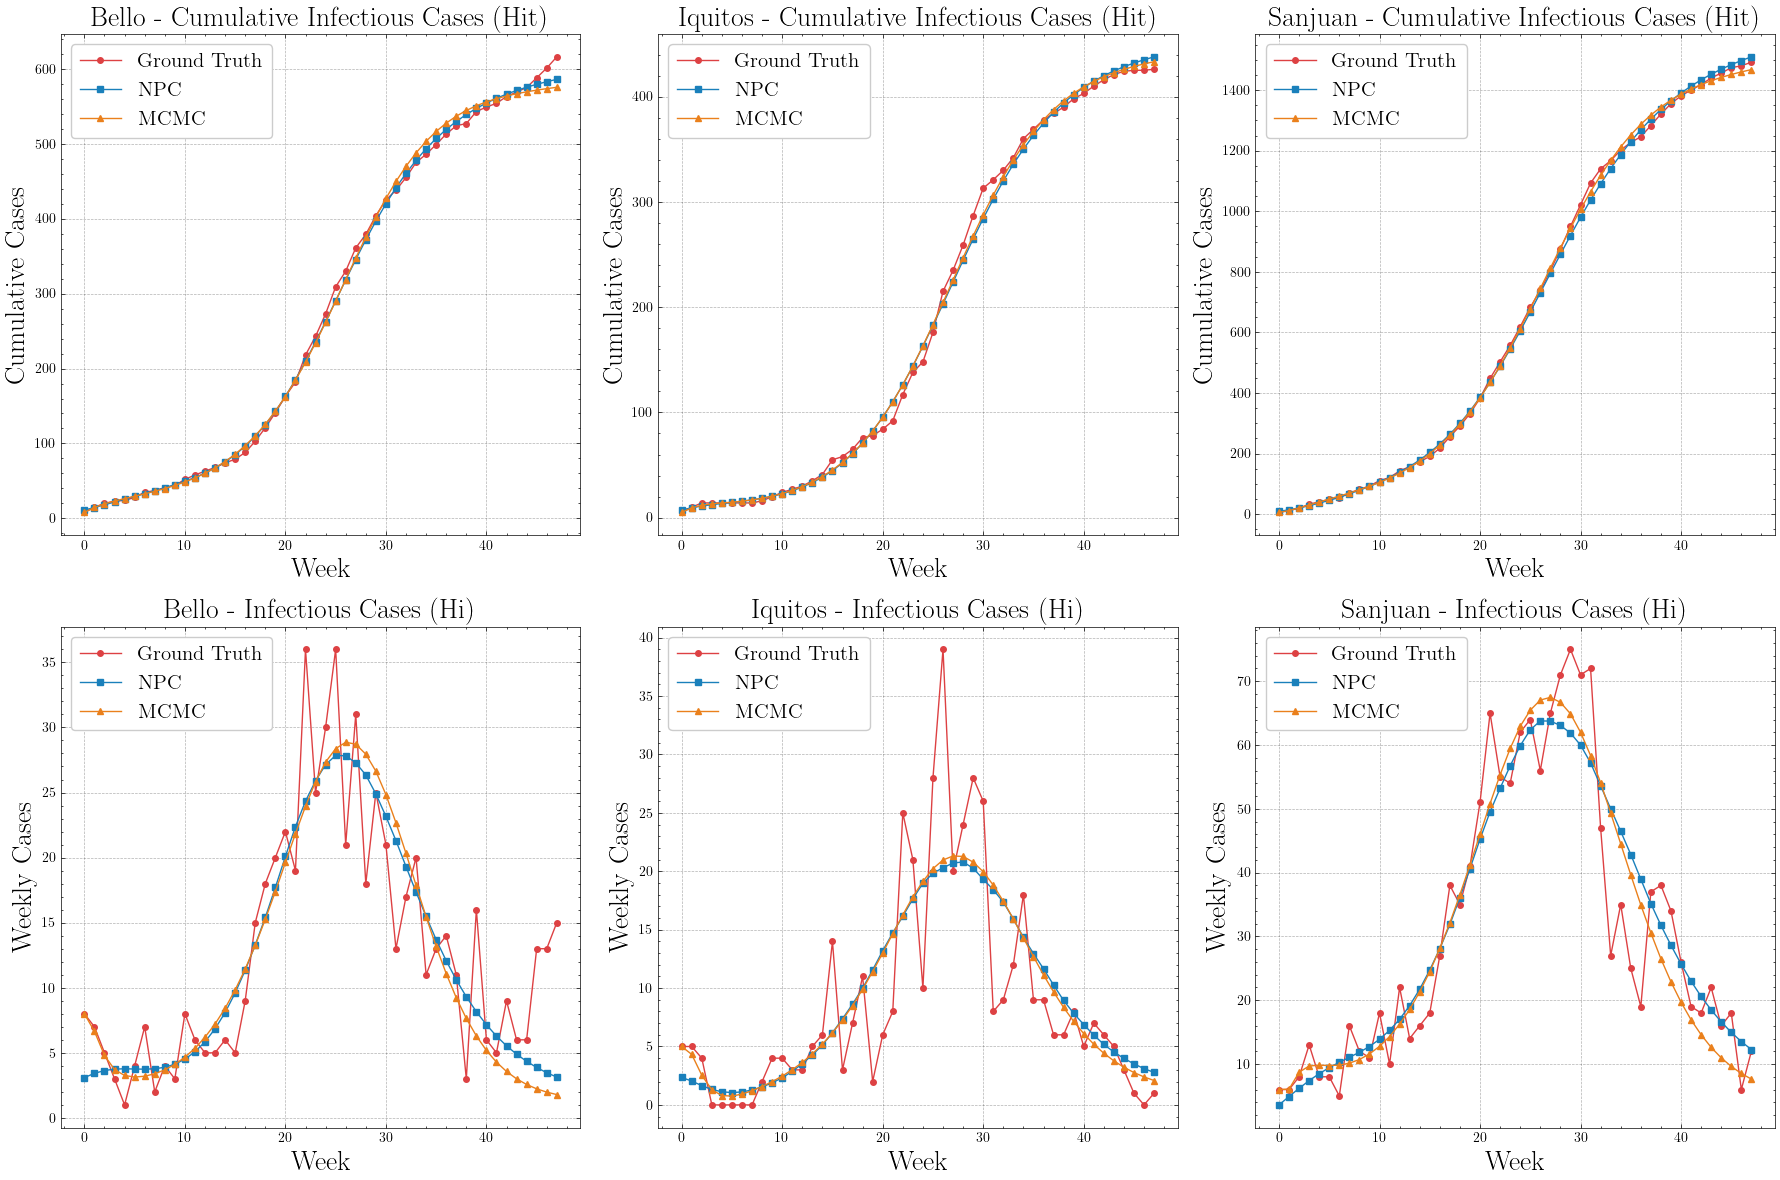

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x3 subplot layout (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
n_rows, n_cols = axes.shape

# Define cities (adjust based on your available data)
cities = ['bello', 'iquitos', 'sanjuan']  # Add 'philippines', 'sanjuan', 'vietnam' as needed

for col, city in enumerate(cities):
    # Hit plot (top row)
    ax_Hit = axes[0, col]
    ax_Hit.plot(eval(f"{city}_Hit_true"), label="Ground Truth", marker='o', color='#DD4143', markersize=4)
    ax_Hit.plot(eval(f"{city}_Hit_npc"), label="NPC", marker='s', color='#1a80bb', markersize=4)
    ax_Hit.plot(eval(f"{city}_Hit_mcmc"), label="MCMC", marker='^', color='#ea801c', markersize=4)

    ax_Hit.set_title(f"{city.title()} - Cumulative Infectious Cases (Hit)", fontsize=20)
    ax_Hit.set_xlabel("Week", fontsize=20)
    ax_Hit.set_ylabel("Cumulative Cases", fontsize=20)
    ax_Hit.legend(loc='upper left', fontsize=15)
    ax_Hit.grid(True, alpha=0.3)

    # Hi plot (bottom row) 
    ax_hi = axes[1, col]
    ax_hi.plot(eval(f"{city}_hi_true"), label="Ground Truth", marker='o', color='#DD4143', markersize=4)
    ax_hi.plot(eval(f"{city}_hi_npc"), label="NPC", marker='s', color='#1a80bb', markersize=4)
    ax_hi.plot(eval(f"{city}_hi_mcmc"), label="MCMC", marker='^', color='#ea801c', markersize=4)

    ax_hi.set_title(f"{city.title()} - Infectious Cases (Hi)", fontsize=20)
    ax_hi.set_xlabel("Week", fontsize=20)
    ax_hi.set_ylabel("Weekly Cases", fontsize=20)
    ax_hi.legend(loc='upper left', fontsize=15)
    ax_hi.grid(True, alpha=0.3)

plt.tight_layout()
# Save figure with 1200 dpi to TIFF file
fig.savefig("./final_figures/revise_version/hi_Hit_visualization_city.tiff", dpi=900, format='tiff')
plt.show()

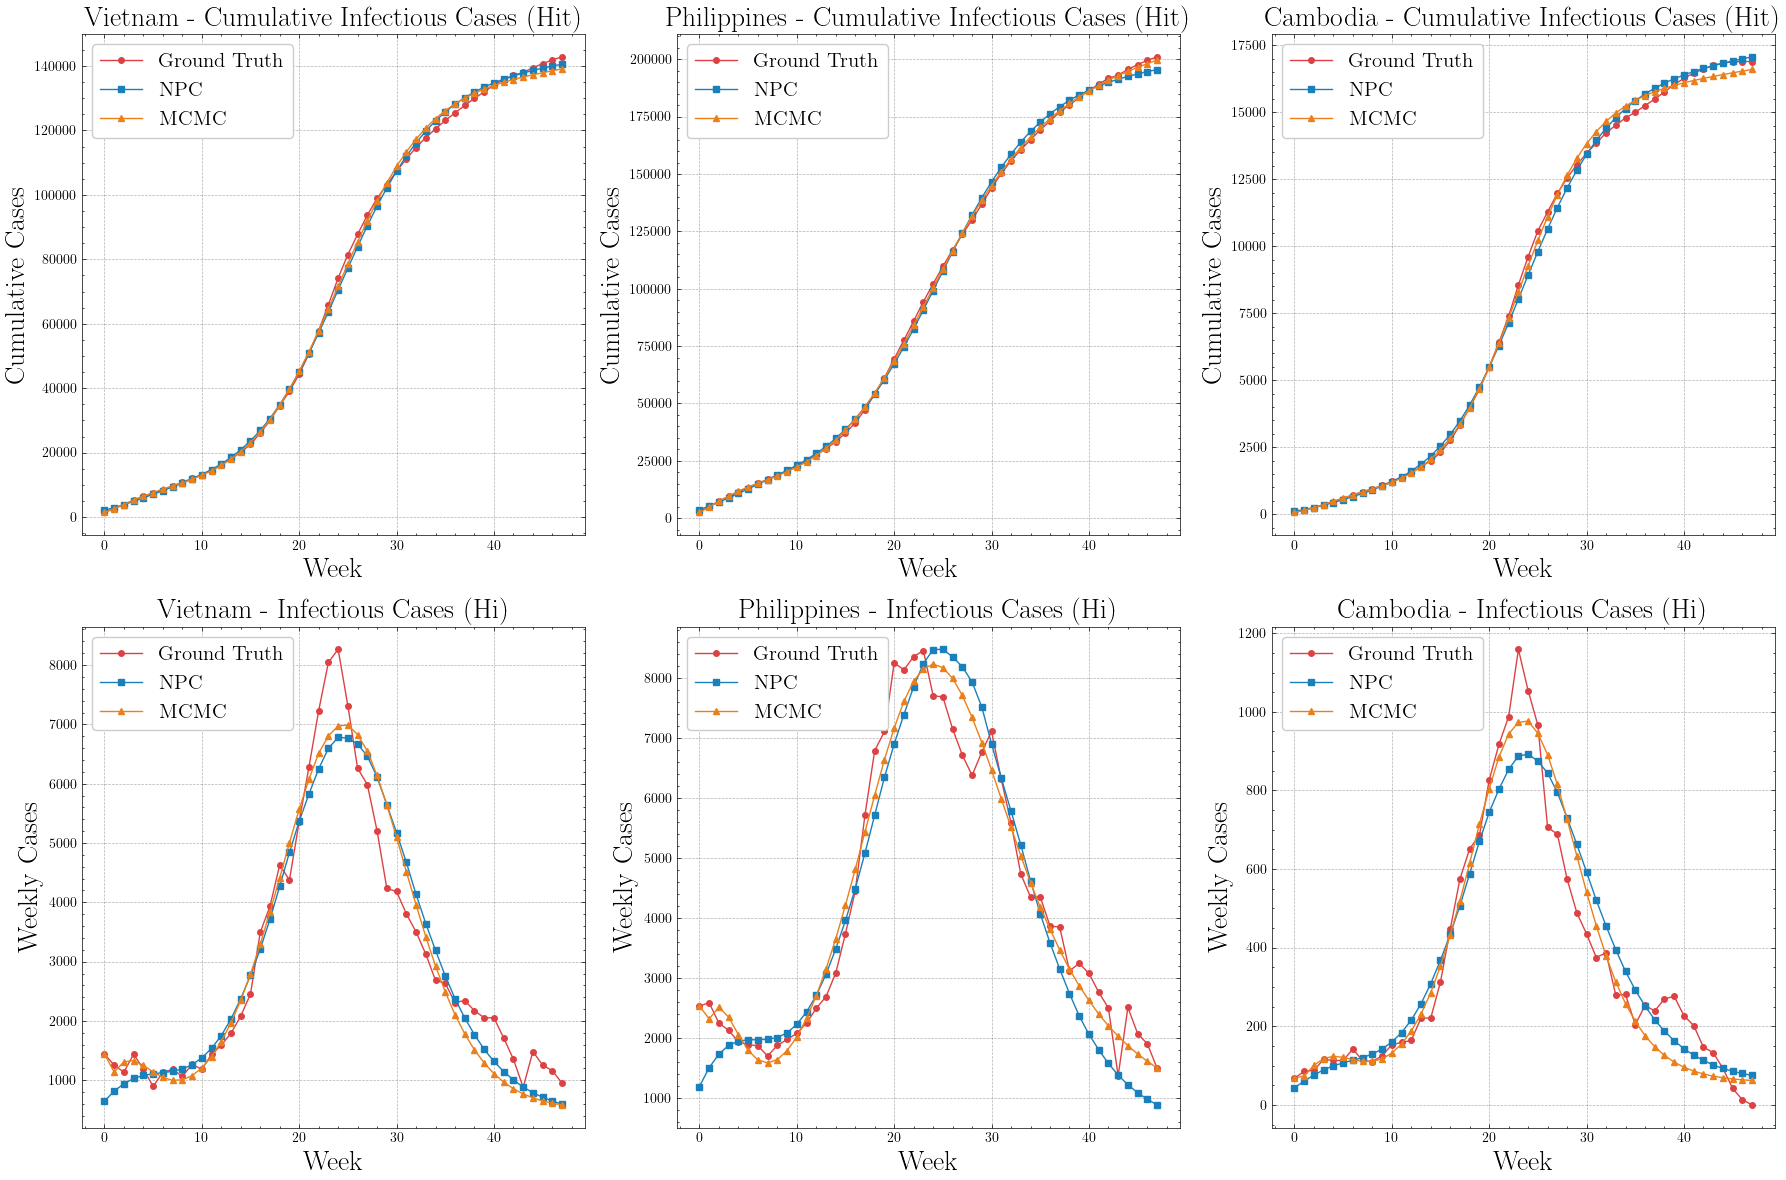

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x3 subplot layout (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
n_rows, n_cols = axes.shape

# Define countries (adjust based on your available data)
countries = ['vietnam', 'philippines', 'cambodia']  # Add 'philippines', 'sanjuan', 'vietnam' as needed

for col, country in enumerate(countries):
    # Hit plot (top row)
    ax_Hit = axes[0, col]
    ax_Hit.plot(eval(f"{country}_Hit_true"), label="Ground Truth", marker='o', color='#DD4143', markersize=4)
    ax_Hit.plot(eval(f"{country}_Hit_npc"), label="NPC", marker='s', color='#1a80bb', markersize=4)
    ax_Hit.plot(eval(f"{country}_Hit_mcmc"), label="MCMC", marker='^', color='#ea801c', markersize=4)

    ax_Hit.set_title(f"{country.title()} - Cumulative Infectious Cases (Hit)", fontsize=20)
    ax_Hit.set_xlabel("Week", fontsize=20)
    ax_Hit.set_ylabel("Cumulative Cases", fontsize=20)
    ax_Hit.legend(loc='upper left', fontsize=15)
    ax_Hit.grid(True, alpha=0.3)

    # Hi plot (bottom row) 
    ax_hi = axes[1, col]
    ax_hi.plot(eval(f"{country}_hi_true"), label="Ground Truth", marker='o', color='#DD4143', markersize=4)
    ax_hi.plot(eval(f"{country}_hi_npc"), label="NPC", marker='s', color='#1a80bb', markersize=4)
    ax_hi.plot(eval(f"{country}_hi_mcmc"), label="MCMC", marker='^', color='#ea801c', markersize=4)

    ax_hi.set_title(f"{country.title()} - Infectious Cases (Hi)", fontsize=20)
    ax_hi.set_xlabel("Week", fontsize=20)
    ax_hi.set_ylabel("Weekly Cases", fontsize=20)
    ax_hi.legend(loc='upper left', fontsize=15)
    ax_hi.grid(True, alpha=0.3)

plt.tight_layout()
# Save figure with 1200 dpi to TIFF file
fig.savefig("./final_figures/revise_version/hi_Hit_visualization_country.tiff", dpi=900, format='tiff')
plt.show()

# Marginal visualisation
A marginal posterior distribution represents the probability distribution of a single parameter obtained by integrating the joint posterior distribution over all other parameters.

Regarding NPC (Neural Parameter Calibration), we train for 2000 epochs, with each epoch producing a set of parameter estimates. The marginal distribution in NPC represents the probability distribution of each parameter obtained from the collection of parameter values generated across all epochs. In MCMC, the marginal distribution of each parameter is obtained through the sampling process, where samples are drawn from the posterior distribution and marginal distributions are derived by considering only the samples of individual parameters while disregarding the values of other parameters.

In [23]:
import h5py
import scipy
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Hi0, Me0, Hr0, Hs0, He0, Ms0, Mi0, beta_h, beta_m, gamma_h, lambda, mu_m, theta_h, theta_m
def plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale, quantile_threshold=0.99):
    """Plot density curves for a parameter with proper normalization"""
    
    # Calculate KDE for each distribution with Scott's rule
    x_range = np.linspace(min_scale, max_scale, 200)
    
    try:
        # Neural Network distribution
        kde_npc = gaussian_kde(data_npc, bw_method=1)
        y_npc = kde_npc(x_range)
        
        # MCMC distribution
        kde_mcmc = gaussian_kde(data_mcmc, bw_method=1)
        y_mcmc = kde_mcmc(x_range)
        
    except np.linalg.LinAlgError:
        # Fallback to histogram-based density estimation
        y_npc, bin_edges = np.histogram(data_npc, bins=50, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        y_mcmc, _ = np.histogram(data_mcmc, bins=bin_edges, density=True)
        x_range = bin_centers
    
    # Plot densities
    ax.plot(x_range, y_npc, color='#1a80bb', lw=2, label='npc')
    ax.fill_between(x_range, y_npc, alpha=0.3, color='#1a80bb')
    ax.plot(x_range, y_mcmc, color='#ea801c', lw=2, label='MCMC')
    ax.fill_between(x_range, y_mcmc, alpha=0.3, color='#ea801c')
    
    # Compute and plot means using direct data
    mean_npc = np.mean(data_npc)
    mean_mcmc = np.mean(data_mcmc)
    
    # Plot mean markers at their actual densities
    ax.scatter(mean_npc, kde_npc(mean_npc),
              color='black', s=30, marker='o', zorder=5)
    ax.scatter(mean_mcmc, kde_mcmc(mean_mcmc),
              color='black', s=30, marker='o', zorder=5)
    
    # Compute and plot modes within parameter range
    mode_idx_npc = np.argmax(y_npc)
    mode_idx_mcmc = np.argmax(y_mcmc)
    mode_npc = x_range[mode_idx_npc]
    mode_mcmc = x_range[mode_idx_mcmc]
    ax.scatter(mode_npc, y_npc[mode_idx_npc], color='grey', s=30, marker='D', zorder=5)
    ax.scatter(mode_mcmc, y_mcmc[mode_idx_mcmc], color='grey', s=30, marker='D', zorder=5)

### Bello

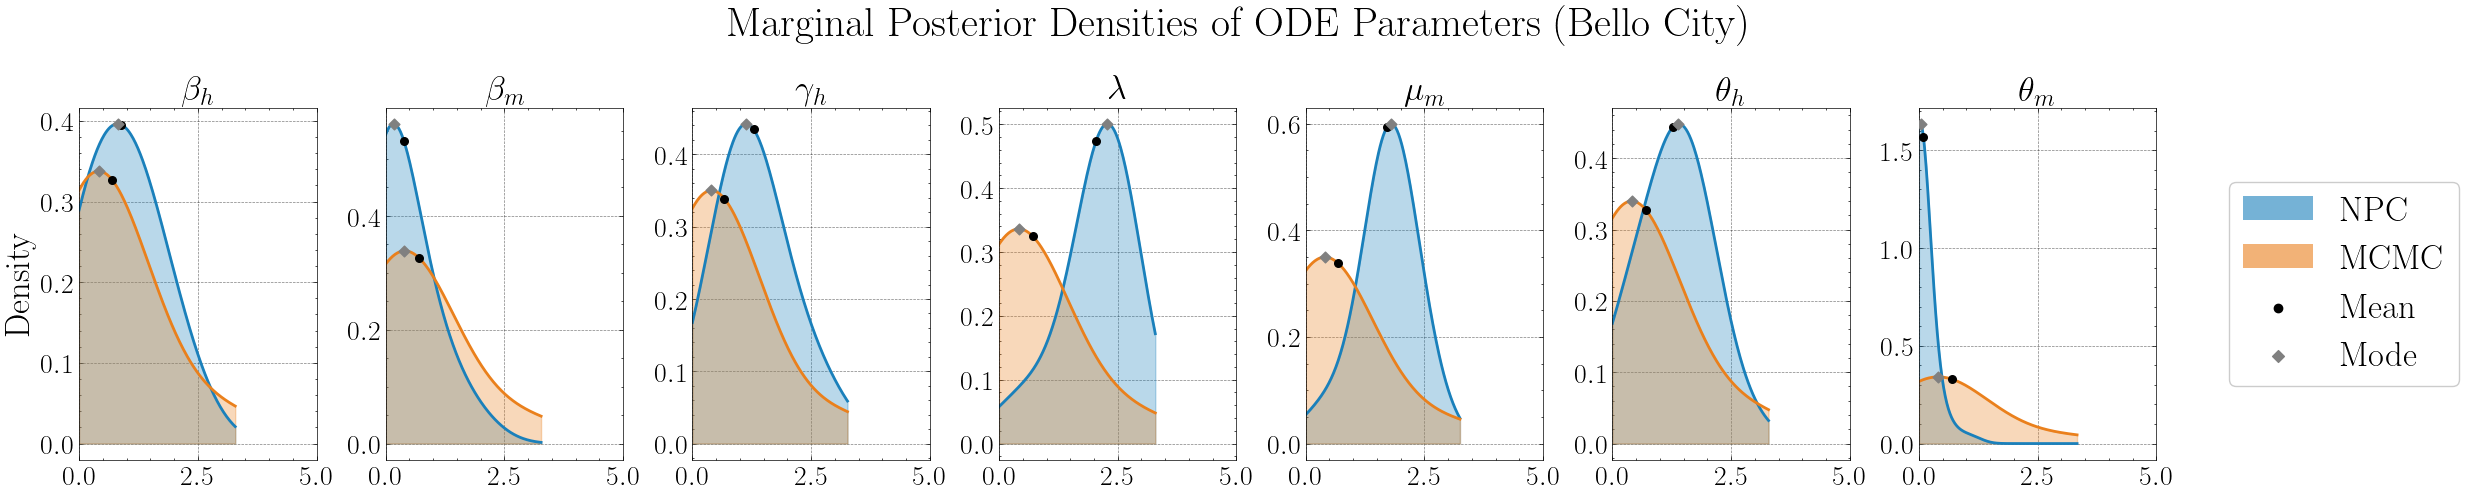

In [24]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda', 
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Load MCMC parameters
mat = scipy.io.loadmat("../data/Dengue/bello/bello_MCMC_matlab.mat")
params_mcmc = mat['bello_mcmc']  # shape: (n_samples, n_parameters)

# Load NPC parameters
param_list = []
folders = sorted([f for f in os.listdir("bello/data") if f.startswith("uni")])
for folder in folders:
    h5_path = os.path.join("bello/data", folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        param_list.append(params)
params_npc = np.vstack(param_list)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}
    
# Set up plot grid
nrows, ncols = 1, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(25, 5))
axs = axs.flatten()

# Add a main title to the top center
fig.suptitle("Marginal Posterior Densities of ODE Parameters (Bello City)", fontsize=30, y=1)

# Plot densities for each parameter
for i, param in enumerate(param_names):
    ax = axs[i]
    data_npc = params_npc[:, i]
    data_mcmc = params_mcmc[:, i]

    # If parameter is an initial condition, convert from log-space
    if param in initial_conditions:
        data_npc = data_npc * population
        data_mcmc = data_mcmc * population
    
    min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
    plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)
    
    ax.set_title(math_param_names[param], fontsize=25)
    if i == 0:
        ax.set_ylabel("Density", fontsize=25)

    # Increase y-axis tick label size
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=20)

    # Set x-axis limit
    ax.set_xlim(0, 5)

# Add legend to empty subplot
if len(param_names) < len(axs):
    legend_ax = axs[-1]
    legend_ax.axis("off")
    handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
              plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
              plt.scatter([0], [0], color='black', marker='o'),
              plt.scatter([0], [0], color='grey', marker='D')]
    labels = ['NPC', 'MCMC', 'Mean', 'Mode']
    legend_ax.legend(handles, labels, loc='center', fontsize=25)

# Remove unused subplot
plt.tight_layout()
plt.savefig('final_figures/revise_version/marginal_densities_bello.tiff', dpi=900, format='tiff')
plt.show()

### Iquitos

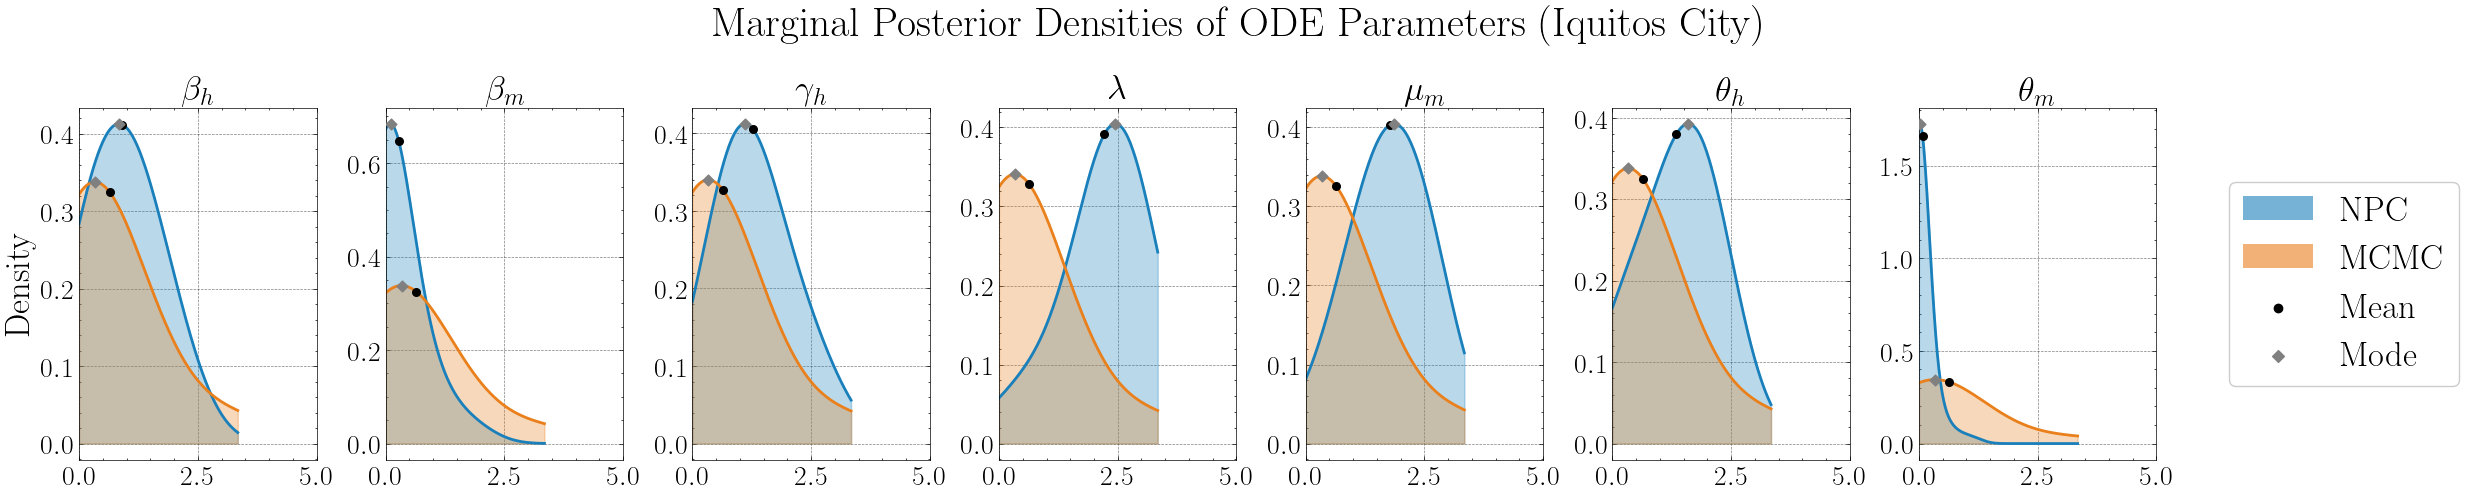

In [ ]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda', 
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Load MCMC parameters
mat = scipy.io.loadmat("../data/Dengue/iquitos/iquitos_MCMC_matlab.mat")
params_mcmc = mat['iquitos_mcmc']  # shape: (n_samples, n_parameters)

# Load NPC parameters
param_list = []
folders = sorted([f for f in os.listdir("iquitos/data") if f.startswith("uni")])
for folder in folders:
    h5_path = os.path.join("iquitos/data", folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        param_list.append(params)
params_npc = np.vstack(param_list)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}
    
# Set up plot grid
nrows, ncols = 1, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(25, 5))
axs = axs.flatten()

# Add a main title to the top center
fig.suptitle("Marginal Posterior Densities of ODE Parameters (Iquitos City)", fontsize=30, y=1)

# Plot densities for each parameter
for i, param in enumerate(param_names):
    ax = axs[i]
    data_npc = params_npc[:, i]
    data_mcmc = params_mcmc[:, i]

    # If parameter is an initial condition, convert from log-space
    if param in initial_conditions:
        data_npc = data_npc * population
        data_mcmc = data_mcmc * population
    
    min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
    plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)
    
    ax.set_title(math_param_names[param], fontsize=25)
    if i == 0:
        ax.set_ylabel("Density", fontsize=25)

    # Increase y-axis tick label size
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=20)

    # Set x-axis limit
    ax.set_xlim(0, 5)

# Add legend to empty subplot
if len(param_names) < len(axs):
    legend_ax = axs[-1]
    legend_ax.axis("off")
    handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
              plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
              plt.scatter([0], [0], color='black', marker='o'),
              plt.scatter([0], [0], color='grey', marker='D')]
    labels = ['NPC', 'MCMC', 'Mean', 'Mode']
    legend_ax.legend(handles, labels, loc='center', fontsize=25)

# Remove unused subplot
plt.tight_layout()
# plt.savefig('final_figures/marginal_densities_iquitos.jpg', dpi=300, bbox_inches='tight')
plt.show()

### SanJuan

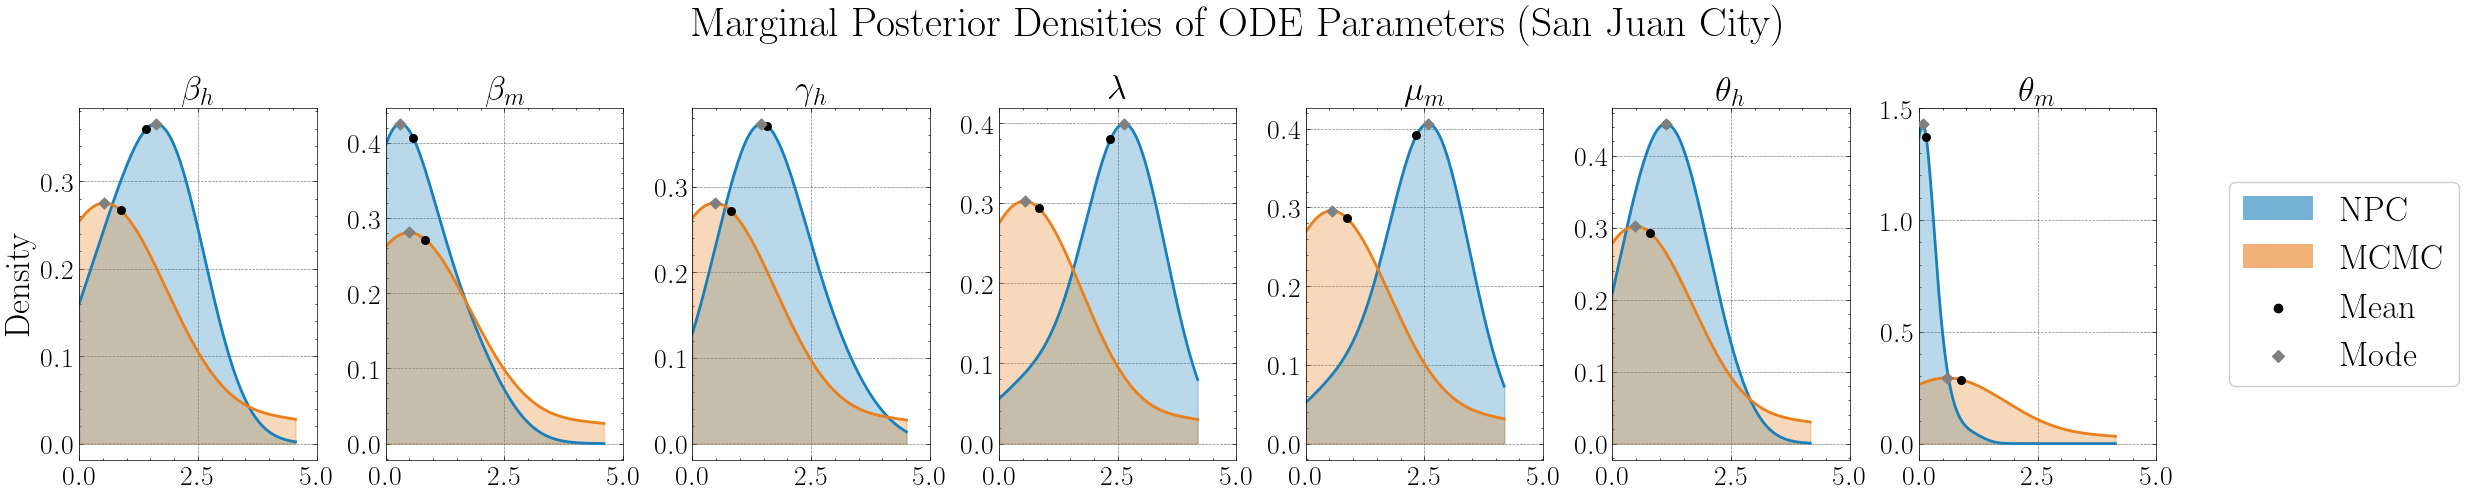

In [ ]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda', 
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Load MCMC parameters
mat = scipy.io.loadmat("../data/Dengue/sanjuan/sanjuan_MCMC_matlab.mat")
params_mcmc = mat['sanjuan_mcmc']  # shape: (n_samples, n_parameters)

# Load NPC parameters
param_list = []
folders = sorted([f for f in os.listdir("sanjuan/data") if f.startswith("uni")])
for folder in folders:
    h5_path = os.path.join("sanjuan/data", folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        param_list.append(params)
params_npc = np.vstack(param_list)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}
    
# Set up plot grid
nrows, ncols = 1, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(25, 5))
axs = axs.flatten()

# Add a main title to the top center
fig.suptitle("Marginal Posterior Densities of ODE Parameters (San Juan City)", fontsize=30, y=1)

# Plot densities for each parameter
for i, param in enumerate(param_names):
    ax = axs[i]
    data_npc = params_npc[:, i]
    data_mcmc = params_mcmc[:, i]

    # If parameter is an initial condition, convert from log-space
    if param in initial_conditions:
        data_npc = data_npc * population
        data_mcmc = data_mcmc * population
    
    min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
    plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)
    
    ax.set_title(math_param_names[param], fontsize=25)
    if i == 0:
        ax.set_ylabel("Density", fontsize=25)

    # Increase y-axis tick label size
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=20)

    # Set x-axis limit
    ax.set_xlim(0, 5)

# Add legend to empty subplot
if len(param_names) < len(axs):
    legend_ax = axs[-1]
    legend_ax.axis("off")
    handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
              plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
              plt.scatter([0], [0], color='black', marker='o'),
              plt.scatter([0], [0], color='grey', marker='D')]
    labels = ['NPC', 'MCMC', 'Mean', 'Mode']
    legend_ax.legend(handles, labels, loc='center', fontsize=25)

# Remove unused subplot
plt.tight_layout()
# plt.savefig('final_figures/marginal_densities_sanjuan.jpg', dpi=300, bbox_inches='tight')
plt.show()

### 3 cities together

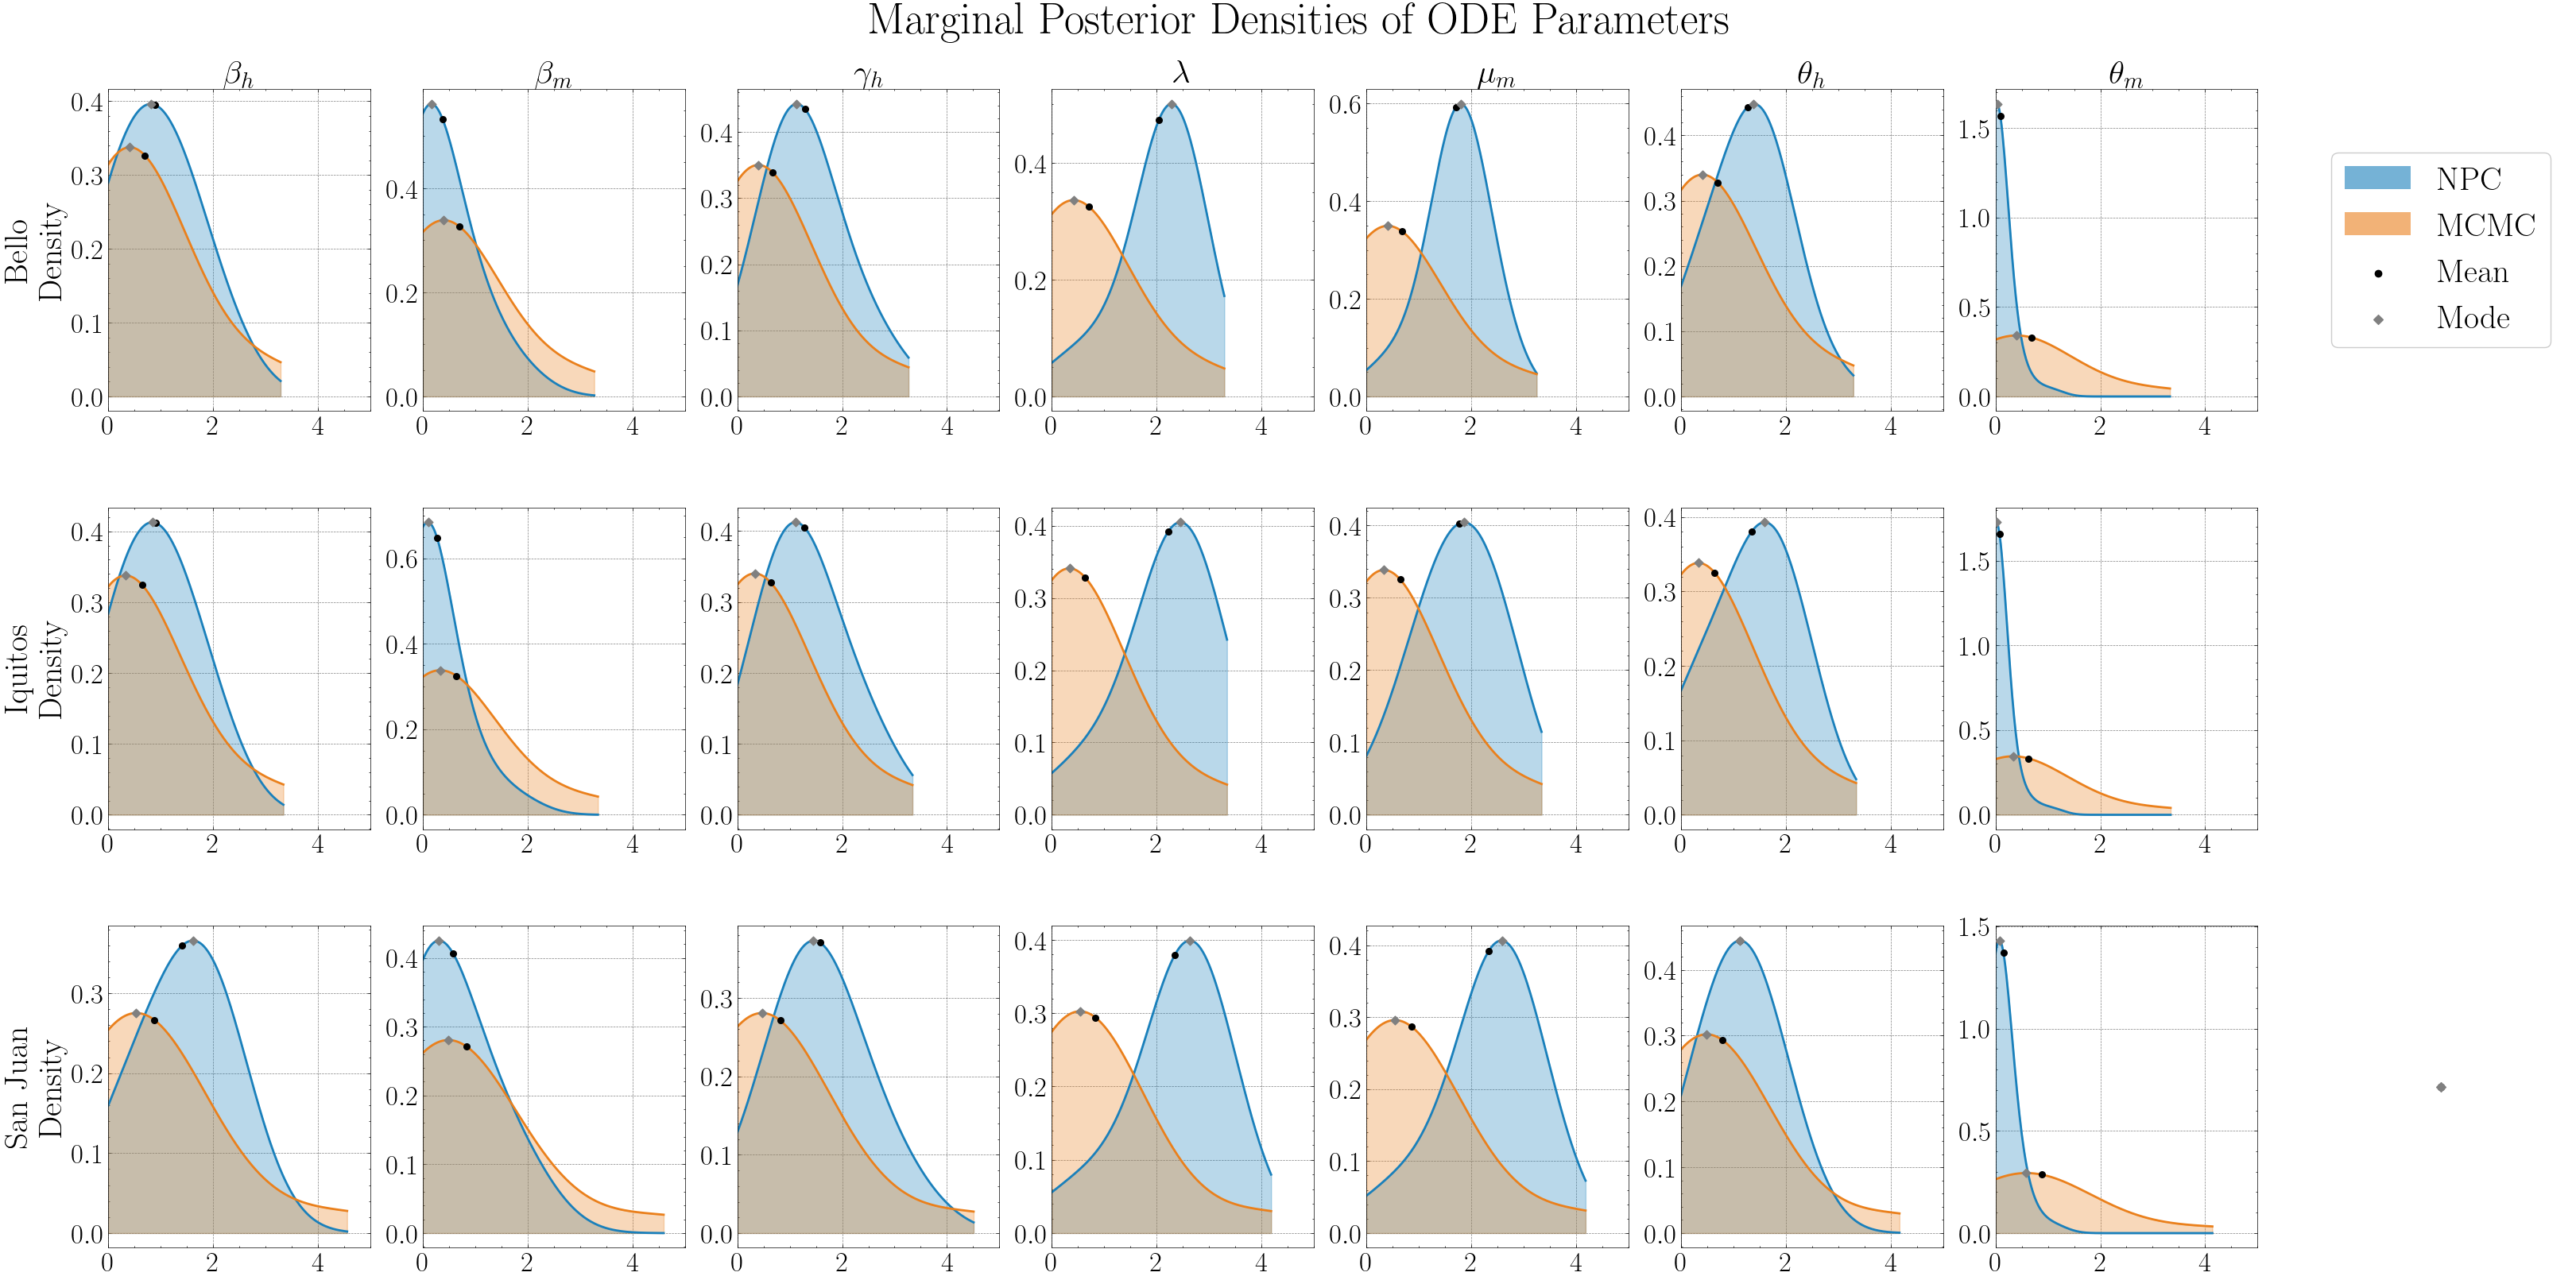

In [27]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda',
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Define cities to plot
cities = ['bello', 'iquitos', 'sanjuan']
city_titles = ['Bello', 'Iquitos', 'San Juan']

# Load data for all cities
all_params_mcmc = []
all_params_npc = []

for city in cities:
    # Load MCMC parameters
    mat = scipy.io.loadmat(f"../data/Dengue/{city}/{city}_MCMC_matlab.mat")
    params_mcmc = mat[f'{city}_mcmc']
    all_params_mcmc.append(params_mcmc)

    # Load NPC parameters
    param_list = []
    folders = sorted([f for f in os.listdir(f"{city}/data") if f.startswith("uni")])
    for folder in folders:
        h5_path = os.path.join(f"{city}/data", folder, "data.h5")
        if not os.path.exists(h5_path):
            print(f"File not found: {h5_path}")
            continue
        with h5py.File(h5_path, "r") as hf:
            params = hf["Dengue"]["parameters"][:]
            param_list.append(params)
    params_npc = np.vstack(param_list)
    all_params_npc.append(params_npc)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}

# Set up plot grid (3 rows, 8 columns)
nrows, ncols = 3, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(40, 18))

# Add a main title with proper spacing
fig.suptitle("Marginal Posterior Densities of ODE Parameters", fontsize=40, y=0.98)

# Plot densities for each city and parameter
for city_idx, (city, city_title) in enumerate(zip(cities, city_titles)):
    params_mcmc = all_params_mcmc[city_idx]
    params_npc = all_params_npc[city_idx]

    for param_idx, param in enumerate(param_names):
        ax = axs[city_idx, param_idx]
        data_npc = params_npc[:, param_idx]
        data_mcmc = params_mcmc[:, param_idx]

        # If parameter is an initial condition, convert from log-space
        if param in initial_conditions:
            data_npc = data_npc * population
            data_mcmc = data_mcmc * population

        min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
        plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)

        # Set titles only for top row
        if city_idx == 0:
            ax.set_title(math_param_names[param], fontsize=30)

        # Set y-label only for first column
        if param_idx == 0:
            ax.set_ylabel(f"{city_title}\nDensity", fontsize=30)

        # Increase tick label size
        ax.tick_params(axis='y', labelsize=25)
        ax.tick_params(axis='x', labelsize=25)

        # Set x-axis limit
        ax.set_xlim(0, 5)

# Add legend only once in the top right corner
legend_ax = axs[0, -1]
legend_ax.axis("off")
handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
          plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
          plt.scatter([0], [0], color='black', marker='o'),
          plt.scatter([0], [0], color='grey', marker='D')]
labels = ['NPC', 'MCMC', 'Mean', 'Mode']
legend_ax.legend(handles, labels, loc='center', fontsize=30)

# Hide the legend positions for other rows
for city_idx in [1, 2]:
    axs[city_idx, -1].axis("off")

# Adjust layout with more spacing
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.2)
plt.savefig('final_figures/revise_version/marginal_densities_cities.tiff', dpi=900, format='tiff')
plt.show()

### Vietnam

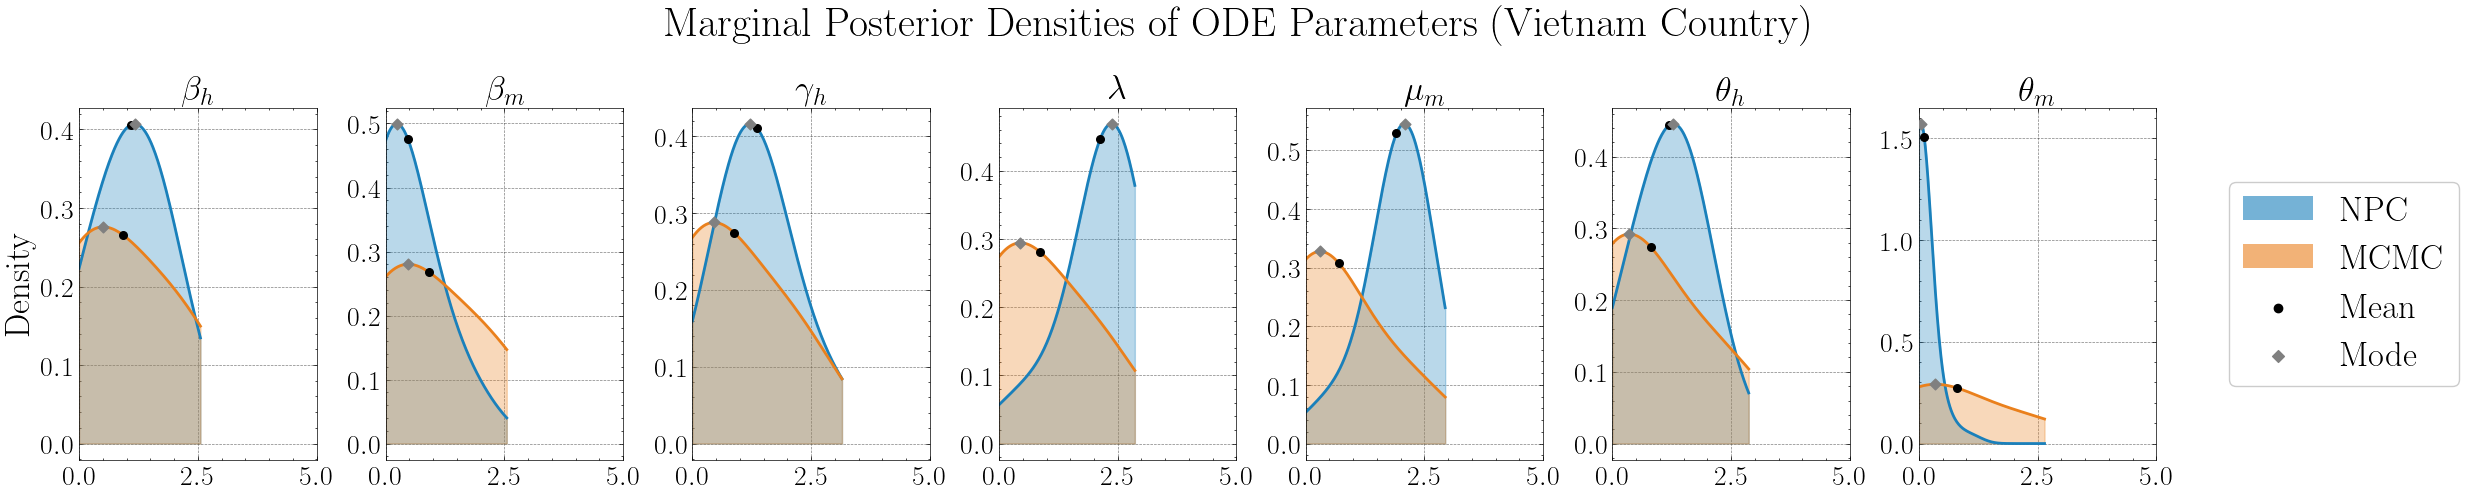

In [28]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda', 
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Load MCMC parameters
mat = scipy.io.loadmat("../data/Dengue/vietnam/vietnam_MCMC_matlab.mat")
params_mcmc = mat['vietnam_mcmc']  # shape: (n_samples, n_parameters)

# Load NPC parameters
param_list = []
folders = sorted([f for f in os.listdir("vietnam/data") if f.startswith("uni")])
for folder in folders:
    h5_path = os.path.join("vietnam/data", folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        param_list.append(params)
params_npc = np.vstack(param_list)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}
    
# Set up plot grid
nrows, ncols = 1, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(25, 5))
axs = axs.flatten()

# Add a main title to the top center
fig.suptitle("Marginal Posterior Densities of ODE Parameters (Vietnam Country)", fontsize=30, y=1)

# Plot densities for each parameter
for i, param in enumerate(param_names):
    ax = axs[i]
    data_npc = params_npc[:, i]
    data_mcmc = params_mcmc[:, i]

    # If parameter is an initial condition, convert from log-space
    if param in initial_conditions:
        data_npc = data_npc * population
        data_mcmc = data_mcmc * population
    
    min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
    plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)
    
    ax.set_title(math_param_names[param], fontsize=25)
    if i == 0:
        ax.set_ylabel("Density", fontsize=25)

    # Increase y-axis tick label size
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=20)

    # Set x-axis limit
    ax.set_xlim(0, 5)

# Add legend to empty subplot
if len(param_names) < len(axs):
    legend_ax = axs[-1]
    legend_ax.axis("off")
    handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
              plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
              plt.scatter([0], [0], color='black', marker='o'),
              plt.scatter([0], [0], color='grey', marker='D')]
    labels = ['NPC', 'MCMC', 'Mean', 'Mode']
    legend_ax.legend(handles, labels, loc='center', fontsize=25)

# Remove unused subplot
plt.tight_layout()
# plt.savefig('final_figures//marginal_densities_vietnam.jpg', dpi=300, bbox_inches='tight')
plt.show()

### Philippines

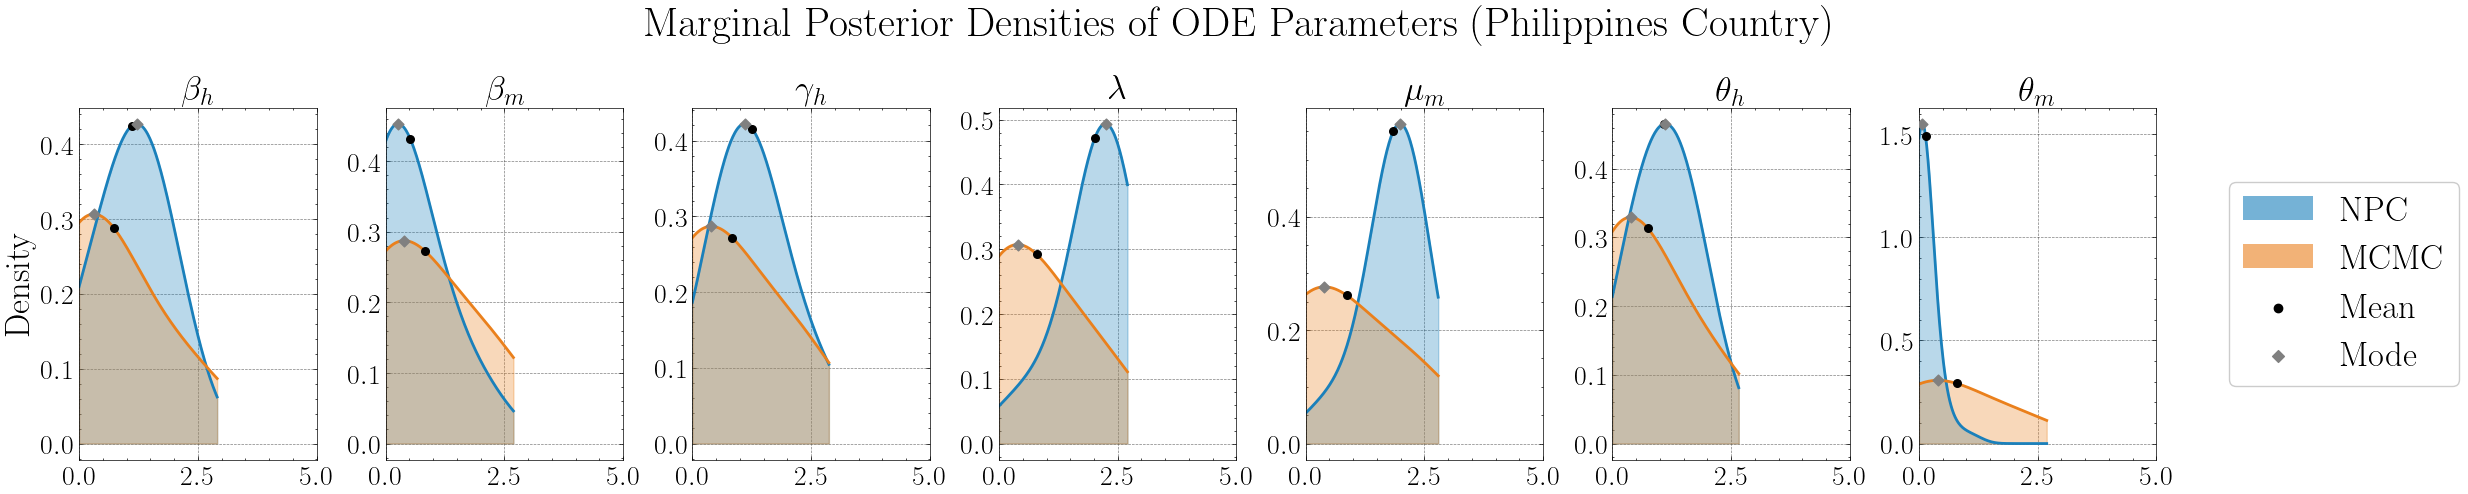

In [29]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda', 
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Load MCMC parameters
mat = scipy.io.loadmat("../data/Dengue/philippines/philippines_MCMC_matlab.mat")
params_mcmc = mat['philippines_mcmc']  # shape: (n_samples, n_parameters)

# Load NPC parameters
param_list = []
folders = sorted([f for f in os.listdir("philippines/data") if f.startswith("uni")])
for folder in folders:
    h5_path = os.path.join("philippines/data", folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        param_list.append(params)
params_npc = np.vstack(param_list)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}
    
# Set up plot grid
nrows, ncols = 1, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(25, 5))
axs = axs.flatten()

# Add a main title to the top center
fig.suptitle("Marginal Posterior Densities of ODE Parameters (Philippines Country)", fontsize=30, y=1)

# Plot densities for each parameter
for i, param in enumerate(param_names):
    ax = axs[i]
    data_npc = params_npc[:, i]
    data_mcmc = params_mcmc[:, i]

    # If parameter is an initial condition, convert from log-space
    if param in initial_conditions:
        data_npc = data_npc * population
        data_mcmc = data_mcmc * population
    
    min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
    plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)
    
    ax.set_title(math_param_names[param], fontsize=25)
    if i == 0:
        ax.set_ylabel("Density", fontsize=25)

    # Increase y-axis tick label size
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=20)

    # Set x-axis limit
    ax.set_xlim(0, 5)

# Add legend to empty subplot
if len(param_names) < len(axs):
    legend_ax = axs[-1]
    legend_ax.axis("off")
    handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
              plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
              plt.scatter([0], [0], color='black', marker='o'),
              plt.scatter([0], [0], color='grey', marker='D')]
    labels = ['NPC', 'MCMC', 'Mean', 'Mode']
    legend_ax.legend(handles, labels, loc='center', fontsize=25)

# Remove unused subplot
plt.tight_layout()
# plt.savefig('final_figures/marginal_densities_philippines.jpg', dpi=300, bbox_inches='tight')
plt.show()

### Cambodia

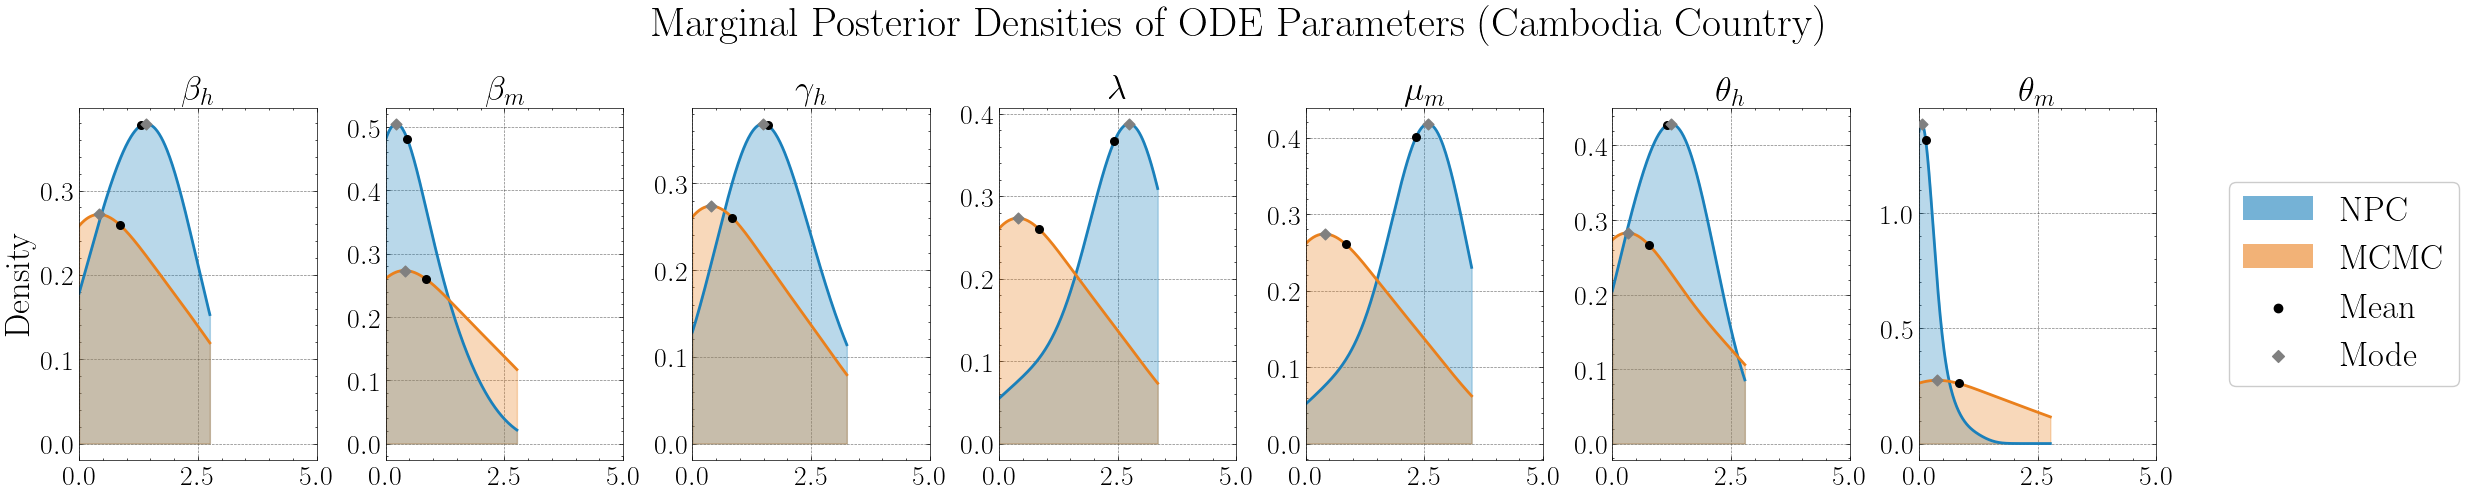

In [30]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda', 
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Load MCMC parameters
mat = scipy.io.loadmat("../data/Dengue/cambodia/cambodia_MCMC_matlab.mat")
params_mcmc = mat['cambodia_mcmc']  # shape: (n_samples, n_parameters)

# Load NPC parameters
param_list = []
folders = sorted([f for f in os.listdir("cambodia/data") if f.startswith("uni")])
for folder in folders:
    h5_path = os.path.join("cambodia/data", folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        param_list.append(params)
params_npc = np.vstack(param_list)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}
    
# Set up plot grid
nrows, ncols = 1, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(25, 5))
axs = axs.flatten()

# Add a main title to the top center
fig.suptitle("Marginal Posterior Densities of ODE Parameters (Cambodia Country)", fontsize=30, y=1)

# Plot densities for each parameter
for i, param in enumerate(param_names):
    ax = axs[i]
    data_npc = params_npc[:, i]
    data_mcmc = params_mcmc[:, i]

    # If parameter is an initial condition, convert from log-space
    if param in initial_conditions:
        data_npc = data_npc * population
        data_mcmc = data_mcmc * population
    
    min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
    plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)
    
    ax.set_title(math_param_names[param], fontsize=25)
    if i == 0:
        ax.set_ylabel("Density", fontsize=25)

    # Increase y-axis tick label size
    ax.tick_params(axis='y', labelsize=20)
    ax.tick_params(axis='x', labelsize=20)

    # Set x-axis limit
    ax.set_xlim(0, 5)

# Add legend to empty subplot
if len(param_names) < len(axs):
    legend_ax = axs[-1]
    legend_ax.axis("off")
    handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
              plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
              plt.scatter([0], [0], color='black', marker='o'),
              plt.scatter([0], [0], color='grey', marker='D')]
    labels = ['NPC', 'MCMC', 'Mean', 'Mode']
    legend_ax.legend(handles, labels, loc='center', fontsize=25)

# Remove unused subplot
plt.tight_layout()
# plt.savefig('final_figures/marginal_densities_cambodia.jpg', dpi=300, bbox_inches='tight')
plt.show()

### 3 countries together

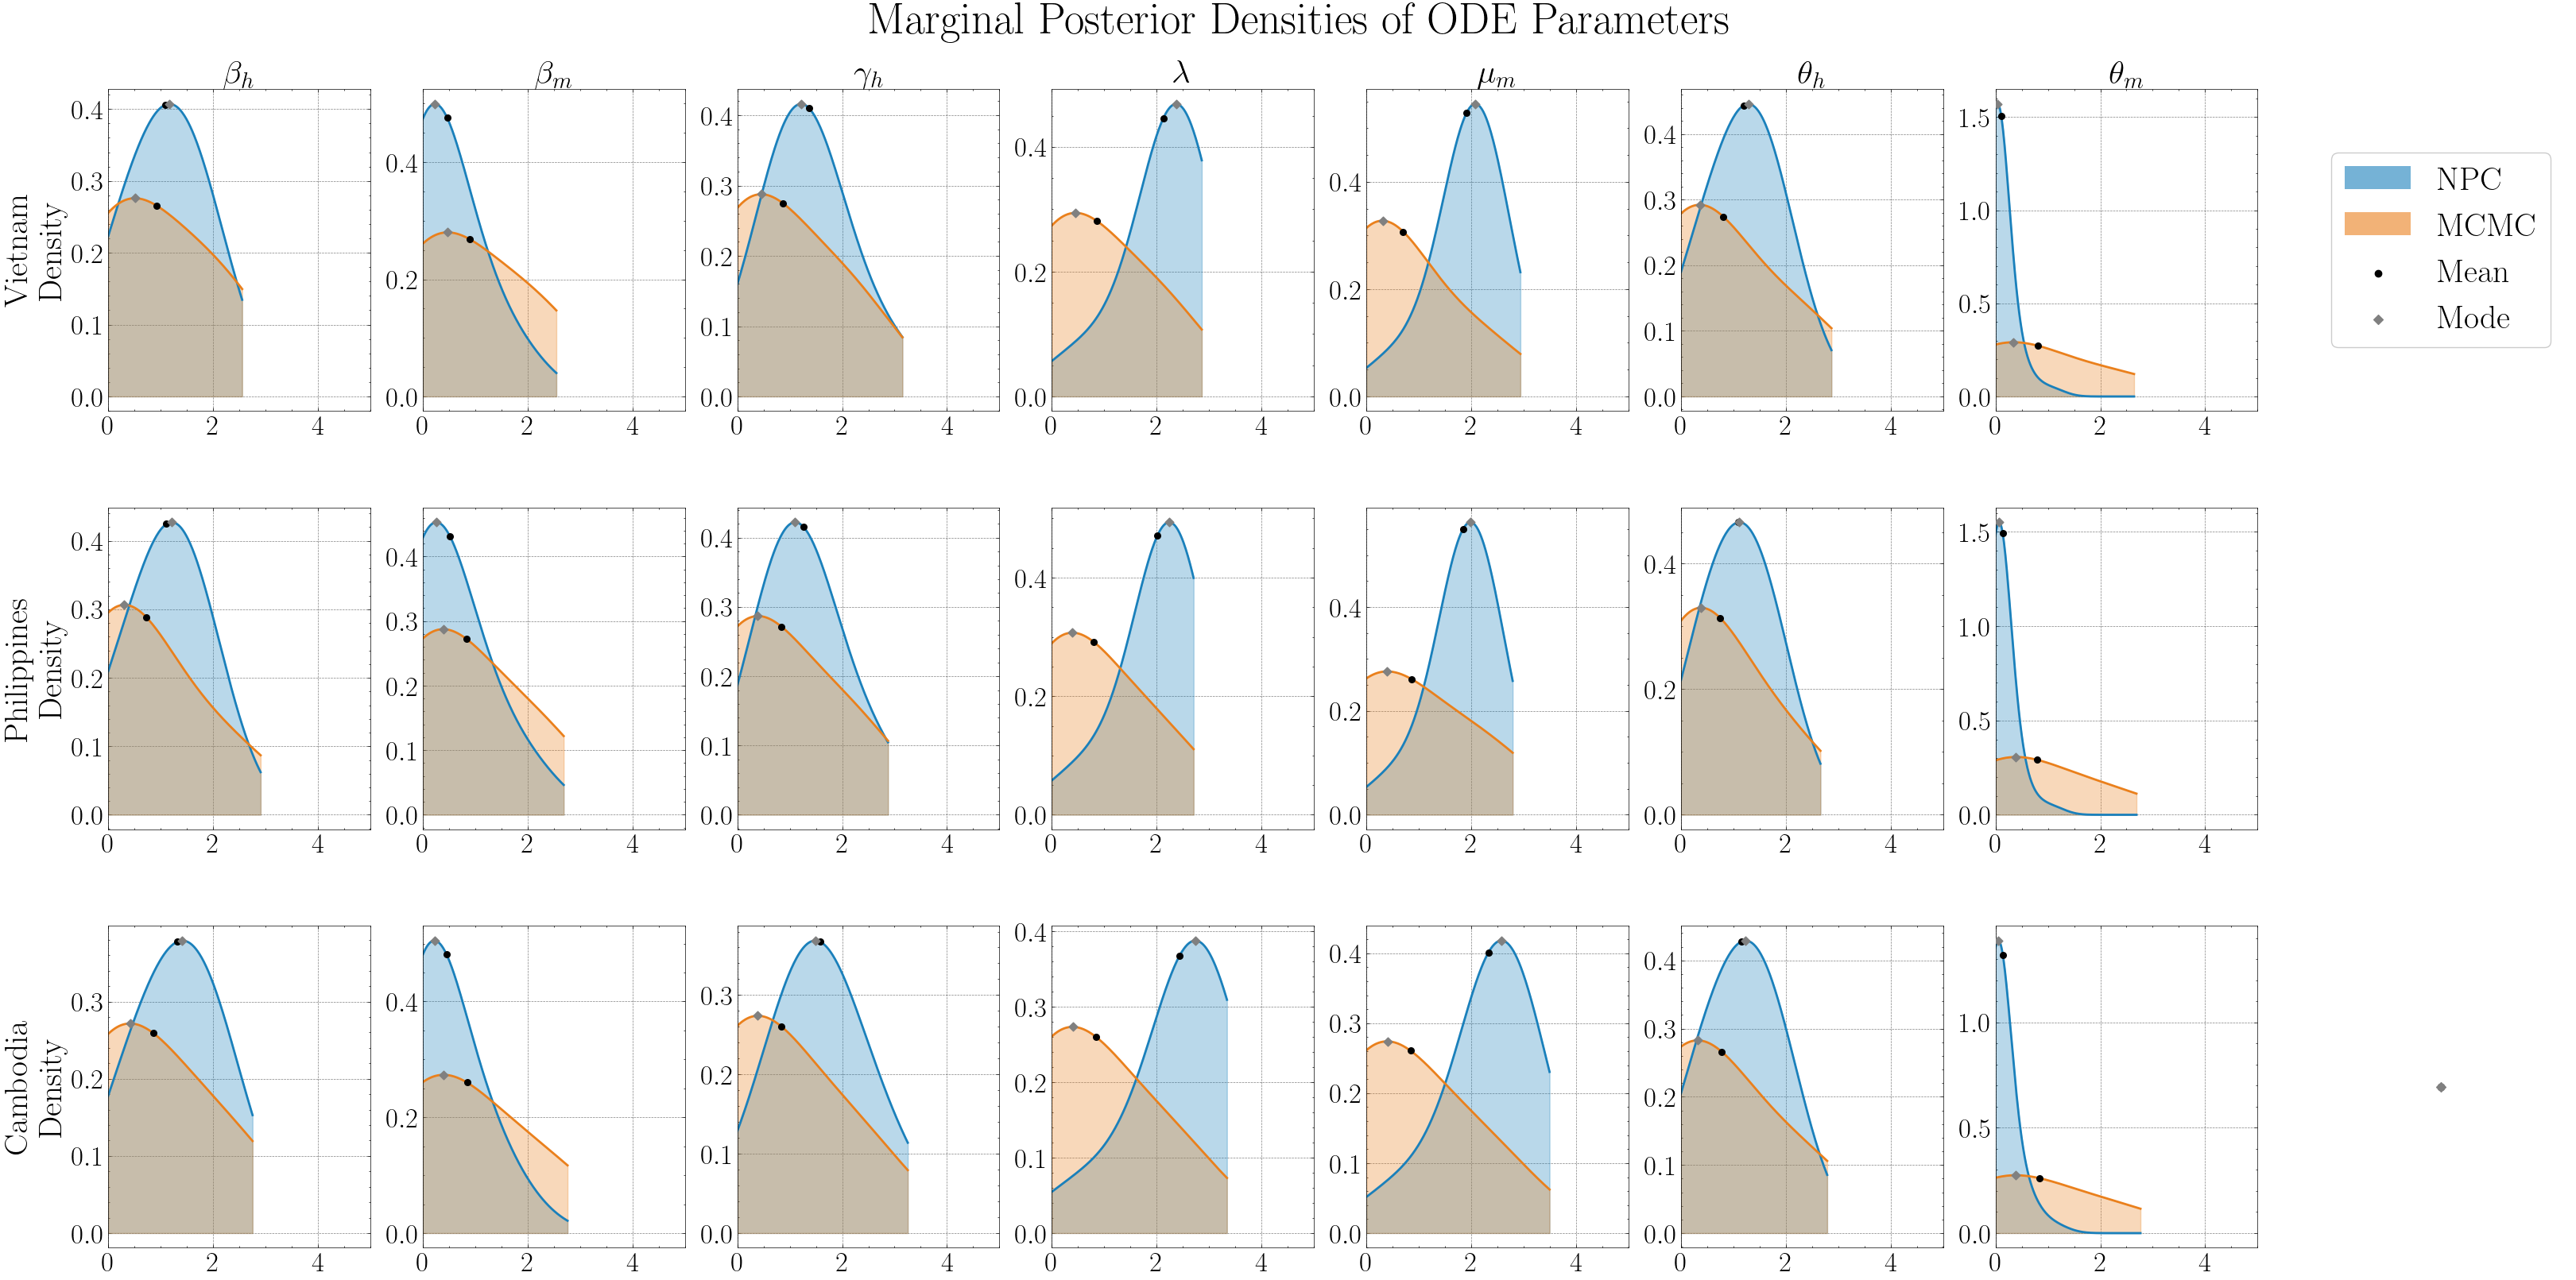

In [31]:
param_names = ['beta_h', 'beta_m', 'gamma_h', 'lambda',
               'mu_m', 'theta_h', 'theta_m']
initial_conditions = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0']
population = 544549

# Define countries to plot
countries = ['vietnam', 'philippines', 'cambodia']
country_titles = ['Vietnam', 'Philippines', 'Cambodia']

# Load data for all countries
all_params_mcmc = []
all_params_npc = []

for country in countries:
    # Load MCMC parameters
    mat = scipy.io.loadmat(f"../data/Dengue/{country}/{country}_MCMC_matlab.mat")
    params_mcmc = mat[f'{country}_mcmc']
    all_params_mcmc.append(params_mcmc)

    # Load NPC parameters
    param_list = []
    folders = sorted([f for f in os.listdir(f"{country}/data") if f.startswith("uni")])
    for folder in folders:
        h5_path = os.path.join(f"{country}/data", folder, "data.h5")
        if not os.path.exists(h5_path):
            print(f"File not found: {h5_path}")
            continue
        with h5py.File(h5_path, "r") as hf:
            params = hf["Dengue"]["parameters"][:]
            param_list.append(params)
    params_npc = np.vstack(param_list)
    all_params_npc.append(params_npc)

# Define parameter names and ranges
math_param_names = {
    "Hi0": r"$Hi_{0}$", "Me0": r"$Me_{0}$", "Hr0": r"$Hr_{0}$",
    "Hs0": r"$Hs_{0}$", "He0": r"$He_{0}$", "Ms0": r"$Ms_{0}$",
    "Mi0": r"$Mi_{0}$", "beta_h": r"$\beta_{h}$", "beta_m": r"$\beta_{m}$",
    "gamma_h": r"$\gamma_{h}$", "lambda": r"$\lambda$", "mu_m": r"$\mu_{m}$",
    "theta_h": r"$\theta_{h}$", "theta_m": r"$\theta_{m}$"
}

# Set up plot grid (3 rows, 8 columns)
nrows, ncols = 3, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(40, 18))

# Add a main title with proper spacing
fig.suptitle("Marginal Posterior Densities of ODE Parameters", fontsize=40, y=0.98)

# Plot densities for each country and parameter
for country_idx, (country, country_title) in enumerate(zip(countries, country_titles)):
    params_mcmc = all_params_mcmc[country_idx]
    params_npc = all_params_npc[country_idx]

    for param_idx, param in enumerate(param_names):
        ax = axs[country_idx, param_idx]
        data_npc = params_npc[:, param_idx]
        data_mcmc = params_mcmc[:, param_idx]

        # If parameter is an initial condition, convert from log-space
        if param in initial_conditions:
            data_npc = data_npc * population
            data_mcmc = data_mcmc * population

        min_scale, max_scale = min(data_npc.min(), data_mcmc.min()), max(data_npc.max(), data_mcmc.max())
        plot_density(ax, data_npc, data_mcmc, param, min_scale, max_scale)

        # Set titles only for top row
        if country_idx == 0:
            ax.set_title(math_param_names[param], fontsize=30)

        # Set y-label only for first column
        if param_idx == 0:
            ax.set_ylabel(f"{country_title}\nDensity", fontsize=30)

        # Increase tick label size
        ax.tick_params(axis='y', labelsize=25)
        ax.tick_params(axis='x', labelsize=25)

        # Set x-axis limit
        ax.set_xlim(0, 5)

# Add legend only once in the top right corner
legend_ax = axs[0, -1]
legend_ax.axis("off")
handles = [plt.Rectangle((0,0),1,1, fc='#1a80bb', alpha=0.6),
          plt.Rectangle((0,0),1,1, fc='#ea801c', alpha=0.6),
          plt.scatter([0], [0], color='black', marker='o'),
          plt.scatter([0], [0], color='grey', marker='D')]
labels = ['NPC', 'MCMC', 'Mean', 'Mode']
legend_ax.legend(handles, labels, loc='center', fontsize=30)

# Hide the legend positions for other rows
for country_idx in [1, 2]:
    axs[country_idx, -1].axis("off")

# Adjust layout with more spacing
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.2)
plt.savefig('final_figures/revise_version/marginal_densities_countries.tiff', dpi=900, format='tiff')
plt.show()

# Compute MSE of NPC and MCMC
This section presents the computation of Hit using two approaches: NPC after training, and MCMC following sampling performed in Matlab. Subsequently, we calculate the Mean Squared Error (MSE) loss of Hit by comparing the ground truth with NPC and MCMC results, respectively, and visualize these outcomes for comparison.

In [32]:
import os
import glob
import torch
import scipy
import numpy as np
import pandas as pd
import ruamel.yaml as yaml
from torchdiffeq import odeint
from os.path import dirname as up
from dantro._import_tools import import_module_from_path

In [33]:
# NEURAL PARAMETERS CALIBRATION
def load_checkpoint(net, filepath):
    """Load model checkpoint from file

    Args:
        net: Model instance to load weights into
        filepath (str): Path to checkpoint file
    """
    try:
        # Load checkpoint
        checkpoint = torch.load(filepath)

        # Restore model state
        net.load_state_dict(checkpoint["model_state_dict"])
        net.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        net.current_loss = checkpoint["loss"]

        print(f"Model checkpoint loaded from {filepath}")
        return net

    except Exception as e:
        print(f"Error loading checkpoint: {str(e)}")
        raise


def load_model(filepath):
    """Load model from file

    Args:
        filepath (str): Path to model file
    """
    yamlc = yaml.YAML(typ="safe")
    with open(filepath) as cfg_file:
        cfg = yamlc.load(cfg_file)

    current_dir = os.getcwd()
    model_cfg = cfg["parameter_space"]["Dengue"]
    to_learn = model_cfg["Training"]["to_learn"]
    include_path = up(current_dir) + "/include"
    base = import_module_from_path(mod_path=include_path, mod_str="include")

    net = base.NeuralNet(
        # input_size=batch_size,
        input_size=1,  # only Hit at t=0
        output_size=len(to_learn),
        **model_cfg["NeuralNet"],
    )
    return net, model_cfg


def apollo_model_7(t, y, params):
    """ODE system for the Dengue model
    Args:
        t: Time point
        y: State vector [Hit, Hi, Me, Hr, Hs, He, Ms, Mi]
        parameters: Dictionary containing model parameters
    """
    Hit, Hi, Me, Hr, Hs, He, Ms, Mi = y
    lambda_, beta_m, mu_m, theta_m, mu_h, beta_h, theta_h, gamma_h = params

    # Calculate total populations
    H = Hr + Hs + He + Hi  # Total human population
    M = Me + Ms + Mi  # Total mosquito population

    # Ensure populations are not zero
    H = torch.clamp(H, min=1e-8)
    M = torch.clamp(M, min=1e-8)

    # ODE system
    dydt = torch.stack(
        [
            theta_h * He,
            theta_h * He - (gamma_h + mu_h) * Hi,
            beta_m * Hi * Ms / H - (theta_m + mu_m) * Me,
            gamma_h * Hi - mu_h * Hr,
            mu_h * H - beta_h * Mi * Hs / M - mu_h * Hs,
            beta_h * Mi * Hs / M - (theta_h + mu_h) * He,
            lambda_ - beta_m * Hi * Ms / H - mu_m * Ms,
            theta_m * Me - mu_m * Mi,
        ]
    )

    return dydt


def nn_calibrate(nn, Hit_true, model_cfg):
    """
    Function to calibrate the model using the neural network predictions.
    """
    # NN predicts parameters & rescale
    Hit_true_tensor = torch.tensor(Hit_true, dtype=torch.float32).log1p()
    Hit0 = torch.tensor(Hit_true_tensor[0], dtype=torch.float32).reshape(1, 1)
    pred_params = nn(Hit0)
    to_learn = {key: idx for idx, key in enumerate(
        model_cfg["Training"]["to_learn"])}
    all_params = [
        "Hi0", "Me0", "Hr0", "Hs0", "He0", "Ms0", "Mi0", 
        "beta_h", "beta_m", "gamma_h", "lambda", "mu_m", "mu_h", "theta_h", "theta_m",
    ]
    parameters = {
        p: (
            pred_params[to_learn[p]]
            if p in to_learn.keys()
            else torch.tensor(0.0004, dtype=torch.float64)  # mu_h is constant 0.0004
        )
        for p in all_params
    }
    print("Initial conditions and parameters inferred from NPC:")
    print({print(param, ": ", val) for param, val in parameters.items()})

    # Perform numerical solver
    Hit0 = Hit0.squeeze()
    y0 = torch.stack(
        [
            Hit0,
            parameters["Hi0"],
            parameters["Me0"],
            parameters["Hr0"],
            parameters["Hs0"],
            parameters["He0"],
            parameters["Ms0"],
            parameters["Mi0"],
        ]
    )
    params = torch.stack(
        [
            parameters["lambda"],
            parameters["beta_m"],
            parameters["mu_m"],
            parameters["theta_m"],
            parameters["mu_h"],
            parameters["beta_h"],
            parameters["theta_h"],
            parameters["gamma_h"],
        ]
    )
    # Setup time points for integration
    t_true = torch.arange(0, 49, dtype=torch.float32)

    # Solve ODE system
    solution = odeint(
        func=lambda y, t: apollo_model_7(y, t, params),
        y0=y0,
        t=t_true,
        method="dopri5",  # dopri5, euler, or rk4
        rtol=1e-3,  # Relaxed tolerance
        atol=1e-6,  # Relaxed absolute tolerance
    )
    # Post-process solution
    npc_Hit_pred = torch.abs(solution[1:, 0].squeeze())  # Hit variable
    npc_Hit_pred = torch.expm1(npc_Hit_pred)
    return npc_Hit_pred

In [34]:
# MCMC CALIBRATION
def run_dengue_ode(parameters, Hit0, t_true):
    """
    Run the dengue ODE system for a given parameter set and initial Hit value.
    Returns the predicted Hit time series.
    """
    def apollo_model_7(t, y, params):
        """ODE system for the Dengue model
        Args:
            t: Time point
            y: State vector [Hit, Hi, Me, Hr, Hs, He, Ms, Mi]
            parameters: Dictionary containing model parameters
        """
        Hit, Hi, Me, Hr, Hs, He, Ms, Mi = y
        lambda_, beta_m, mu_m, theta_m, mu_h, beta_h, theta_h, gamma_h = params

        # Calculate total populations
        H = Hr + Hs + He + Hi  # Total human population
        M = Me + Ms + Mi  # Total mosquito population

        # Ensure populations are not zero
        H = torch.clamp(H, min=1e-8)
        M = torch.clamp(M, min=1e-8)

        # ODE system
        dydt = torch.stack(
            [
                theta_h * He,
                theta_h * He - (gamma_h + mu_h) * Hi,
                beta_m * Hi * Ms / H - (theta_m + mu_m) * Me,
                gamma_h * Hi - mu_h * Hr,
                mu_h * H - beta_h * Mi * Hs / M - mu_h * Hs,
                beta_h * Mi * Hs / M - (theta_h + mu_h) * He,
                lambda_ - beta_m * Hi * Ms / H - mu_m * Ms,
                theta_m * Me - mu_m * Mi,
            ]
        )
        return dydt

    # Initial state
    Hit0 = Hit0.squeeze(1)
    y0 = torch.stack(
        [
            Hit0,
            parameters["Hi0"],
            parameters["Me0"],
            parameters["Hr0"],
            parameters["Hs0"],
            parameters["He0"],
            parameters["Ms0"],
            parameters["Mi0"],
        ]
    )
    params = torch.stack(
        [
            parameters["lambda"],
            parameters["beta_m"],
            parameters["mu_m"],
            parameters["theta_m"],
            parameters["mu_h"],
            parameters["beta_h"],
            parameters["theta_h"],
            parameters["gamma_h"],
        ]
    )
    
    # Solve ODE system
    solution = odeint(
        func=lambda y, t: apollo_model_7(y, t, params),
        y0=y0,
        t=t_true,
        method="dopri5",  # dopri5, euler, or rk4
        rtol=1e-3,  # Relaxed tolerance
        atol=1e-6,  # Relaxed absolute tolerance
    )
    
    # Post-process solution
    mcmc_Hit_pred = torch.abs(solution[1:, 0].squeeze())  # Hit variable
    mcmc_Hit_pred = torch.expm1(mcmc_Hit_pred)
    return mcmc_Hit_pred


def mcmc_estimate(mat_path, mat_name, Hit_true, npc_Hit, t_points, param_names=None):
    """
    Load MCMC parameters from .mat file, run ODE for each, compute loss to ground truth,
    and select the prediction with the smallest loss but closest to NPC prediction.
    Returns: best_pred_Hit, best_loss, best_params
    """
    if param_names is None:
        param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0',
                       'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']
    mat = scipy.io.loadmat(mat_path)
    params_mcmc = mat[mat_name]  # shape: (n_parameters, 1)
    Hit_true_tensor = torch.tensor(Hit_true, dtype=torch.float64).log1p()
    mse_loss = torch.nn.MSELoss()
    best_params = None

    p = params_mcmc[:]
    params = {name: torch.tensor(p[j]) for j, name in enumerate(param_names)}
    params["mu_h"] = torch.tensor([0.0004], dtype=torch.float64)  # constant
    best_params = params
    Hit0 = torch.tensor(Hit_true_tensor[0], dtype=torch.float64).reshape(1, 1)

    # Run ODE with current parameters
    mcmc_Hit = run_dengue_ode(params, Hit0, t_points)
    mcmc_Hit_tensor = torch.tensor(mcmc_Hit, dtype=torch.float64).log1p()
    mcmc_loss = mse_loss(mcmc_Hit_tensor, Hit_true_tensor).item()
    
    return mcmc_Hit, mcmc_loss, best_params

## Compute MSE for Calibration dataset

### Bello

In [35]:
cfg_file_path = "../models/Dengue/cfgs/bello/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
bello_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/bello/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
bello_Hit_true_tensor = bello_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./bello/data/uni05/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
bello_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
bello_Hit_npc = nn_calibrate(bello_nn, bello_Hit_true, model_cfg)
bello_Hit_npc_tensor = bello_Hit_npc.log1p()

# Compute loss of NPC on calibration set
mse_Hit_npc_bello_cali = mse_loss(
    bello_Hit_npc_tensor, bello_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
bello_Hit_mcmc, _, best_params = mcmc_estimate(
    "../data/Dengue/bello/bello_MCMC_best_params.mat", "bello_mcmc", bello_Hit_true,
    bello_Hit_npc, t_points)
bello_Hit_mcmc_tensor = torch.tensor(bello_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Calibration set
mse_Hit_mcmc_bello_cali = mse_loss(
    bello_Hit_mcmc_tensor, bello_Hit_true_tensor
)

print(f"Bello MSE NPC on calibration set: {mse_Hit_npc_bello_cali}")
print(f"Bello MSE MCMC on calibration set: {mse_Hit_mcmc_bello_cali}\n")

Loading checkpoint from ./bello/data/uni05/data_npc_checkpoint.pth
Model checkpoint loaded from ./bello/data/uni05/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.0001, grad_fn=<SelectBackward0>)
Me0 :  tensor(1.2517e-05, grad_fn=<SelectBackward0>)
Hr0 :  tensor(2.0438, grad_fn=<SelectBackward0>)
Hs0 :  tensor(2.5917, grad_fn=<SelectBackward0>)
He0 :  tensor(1.5249, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.4725, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.0785, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.6132, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.3355, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.0014, grad_fn=<SelectBackward0>)
lambda :  tensor(1.4822, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0003, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2046, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.1090, grad_fn=<SelectBackward0>)
{None}
Bello MSE NPC on calibration set: 0.003259857

In [36]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params.items():
    print(f'{key}: {value[0]}')

Hi0: 1.6131847757435e-06
Me0: 0.4818522197859998
Hr0: 1.1104813686390353
Hs0: 3.288216027318831
He0: 0.8046307992341207
Ms0: 6.472763182153173e-06
Mi0: 3.838992380543742e-14
beta_h: 0.9343688657670515
beta_m: 0.06088400253249314
gamma_h: 1.3787041838715056e-05
lambda: 1.8423248677675206
mu_m: 0.03335749531713348
theta_h: 1.0260442185320107
theta_m: 0.2064074997932324
mu_h: 0.0004


### Iquitos

In [37]:
cfg_file_path = "../models/Dengue/cfgs/iquitos/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
iquitos_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/iquitos/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
iquitos_Hit_true_tensor = iquitos_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./iquitos/data/uni04/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
iquitos_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
iquitos_Hit_npc = nn_calibrate(iquitos_nn, iquitos_Hit_true, model_cfg)
iquitos_Hit_npc_tensor = iquitos_Hit_npc.log1p()

# Compute loss of NPC on calibration set
mse_Hit_npc_iquitos_cali = mse_loss(
    iquitos_Hit_npc_tensor, iquitos_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
iquitos_Hit_mcmc, _, best_params = mcmc_estimate(
    "../data/Dengue/iquitos/iquitos_MCMC_best_params.mat", "iquitos_mcmc", iquitos_Hit_true,
    iquitos_Hit_npc, t_points)
iquitos_Hit_mcmc_tensor = torch.tensor(iquitos_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Calibration set
mse_Hit_mcmc_iquitos_cali = mse_loss(
    iquitos_Hit_mcmc_tensor, iquitos_Hit_true_tensor
)

print(f"Iquitos MSE NPC on calibration set: {mse_Hit_npc_iquitos_cali}")
print(f"Iquitos MSE MCMC on calibration set: {mse_Hit_mcmc_iquitos_cali}\n")

Loading checkpoint from ./iquitos/data/uni04/data_npc_checkpoint.pth
Model checkpoint loaded from ./iquitos/data/uni04/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.4117, grad_fn=<SelectBackward0>)
Me0 :  tensor(0.0024, grad_fn=<SelectBackward0>)
Hr0 :  tensor(1.4399, grad_fn=<SelectBackward0>)
Hs0 :  tensor(3.2067, grad_fn=<SelectBackward0>)
He0 :  tensor(1.0232, grad_fn=<SelectBackward0>)
Ms0 :  tensor(1.9653, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.0013, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.5317, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.2626, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.1283, grad_fn=<SelectBackward0>)
lambda :  tensor(0.0772, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0055, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.3702, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0985, grad_fn=<SelectBackward0>)
{None}
Iquitos MSE NPC on calibration set: 0.0087877

In [38]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params.items():
    print(f'{key}: {value[0]}')

Hi0: 0.06636595397133503
Me0: 2.7299917007677188e-14
Hr0: 0.03104366940734174
Hs0: 3.3419205922518254
He0: 0.9066370612103022
Ms0: 1.6206706854992385
Mi0: 1.000000028552119e-06
beta_h: 1.4238252491888665
beta_m: 0.10446776371708079
gamma_h: 0.27976496745080603
lambda: 0.20824799908101213
mu_m: 1.4924622307766453e-06
theta_h: 0.8928339999999777
theta_m: 0.15681693496318977
mu_h: 0.0004


### San Juan

In [39]:
cfg_file_path = "../models/Dengue/cfgs/sanjuan/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
sanjuan_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/sanjuan/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
sanjuan_Hit_true_tensor = sanjuan_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./sanjuan/data/uni04/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
sanjuan_npc = load_checkpoint(net, checkpoint_path)

# Calibrate & estimate latent variables
sanjuan_Hit_npc = nn_calibrate(sanjuan_npc, sanjuan_Hit_true, model_cfg)
sanjuan_Hit_npc_tensor = sanjuan_Hit_npc.log1p()

# Compute loss of NPC on calibration set
mse_Hit_npc_sanjuan_cali = mse_loss(
    sanjuan_Hit_npc_tensor, sanjuan_Hit_true_tensor
)

# Compute loss of MCMC on calibration set
t_points = torch.arange(0, 49, dtype=torch.float32)
sanjuan_Hit_mcmc, _, best_params = mcmc_estimate(
    "../data/Dengue/sanjuan/sanjuan_MCMC_best_params.mat", "sanjuan_mcmc", sanjuan_Hit_true,
    sanjuan_Hit_npc, t_points)
sanjuan_Hit_mcmc_tensor = torch.tensor(sanjuan_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on calibration set
mse_Hit_mcmc_sanjuan_cali = mse_loss(
    sanjuan_Hit_mcmc_tensor, sanjuan_Hit_true_tensor
)

print(f"Sanjuan MSE NPC on calibration set: {mse_Hit_npc_sanjuan_cali}")
print(f"Sanjuan MSE MCMC on calibration set: {mse_Hit_mcmc_sanjuan_cali}\n")

Loading checkpoint from ./sanjuan/data/uni04/data_npc_checkpoint.pth
Model checkpoint loaded from ./sanjuan/data/uni04/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.9710, grad_fn=<SelectBackward0>)
Me0 :  tensor(0.0005, grad_fn=<SelectBackward0>)
Hr0 :  tensor(2.0600, grad_fn=<SelectBackward0>)
Hs0 :  tensor(3.2037, grad_fn=<SelectBackward0>)
He0 :  tensor(2.1180, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.8975, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.0845, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.3714, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.4409, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.0233, grad_fn=<SelectBackward0>)
lambda :  tensor(0.0183, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0030, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2361, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0302, grad_fn=<SelectBackward0>)
{None}
Sanjuan MSE NPC on calibration set: 0.0079485

In [40]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params.items():
    print(f'{key}: {value[0]}')

Hi0: 0.00016342449867498036
Me0: 0.8279705210723719
Hr0: 1.6484607412365395
Hs0: 4.557693662334342
He0: 0.7037101590887095
Ms0: 0.4061104922786206
Mi0: 0.33099073023926906
beta_h: 0.8904898451821236
beta_m: 0.10736815509623458
gamma_h: 0.0015427403929115032
lambda: 1.8317099987665235
mu_m: 0.05142292127556542
theta_h: 0.862492011925729
theta_m: 0.07806869717274466
mu_h: 0.0004


### Vienam

In [41]:
cfg_file_path = "../models/Dengue/cfgs/vietnam/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
vietnam_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/vietnam/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
vietnam_Hit_true_tensor = vietnam_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./vietnam/data/uni05/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
vietnam_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
vietnam_Hit_npc = nn_calibrate(vietnam_nn, vietnam_Hit_true, model_cfg)
vietnam_Hit_npc_tensor = vietnam_Hit_npc.log1p()

# Compute loss of NPC on calibration set
mse_Hit_npc_vietnam_cali = mse_loss(
    vietnam_Hit_npc_tensor, vietnam_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
vietnam_Hit_mcmc, _, best_params = mcmc_estimate(
    "../data/Dengue/vietnam/vietnam_MCMC_best_params.mat", "vietnam_mcmc", vietnam_Hit_true,
    vietnam_Hit_npc, t_points)
vietnam_Hit_mcmc_tensor = torch.tensor(vietnam_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on calibration set
mse_Hit_mcmc_vietnam_cali = mse_loss(
    vietnam_Hit_mcmc_tensor, vietnam_Hit_true_tensor
)

print(f"Vietnam MSE NPC on calibration set: {mse_Hit_npc_vietnam_cali}")
print(f"Vietnam MSE MCMC on calibration set: {mse_Hit_mcmc_vietnam_cali}\n")

Loading checkpoint from ./vietnam/data/uni05/data_npc_checkpoint.pth
Model checkpoint loaded from ./vietnam/data/uni05/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.0001, grad_fn=<SelectBackward0>)
Me0 :  tensor(0.0003, grad_fn=<SelectBackward0>)
Hr0 :  tensor(1.8988, grad_fn=<SelectBackward0>)
Hs0 :  tensor(2.7970, grad_fn=<SelectBackward0>)
He0 :  tensor(1.7054, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.2764, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.1192, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.8366, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.2130, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.0001, grad_fn=<SelectBackward0>)
lambda :  tensor(1.3629, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0003, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2183, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0972, grad_fn=<SelectBackward0>)
{None}
Vietnam MSE NPC on calibration set: 0.0037560

In [42]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params.items():
    print(f'{key}: {value[0]}')

Hi0: 1.7859135470426593
Me0: 0.5670808678366992
Hr0: 2.2068279993284174
Hs0: 2.5558622651317138
He0: 1.8906668309351802
Ms0: 0.022752547048931187
Mi0: 1.0000000400279797e-06
beta_h: 1.0329015372069843
beta_m: 0.2050992105072137
gamma_h: 7.328193028142224e-07
lambda: 2.25108661017595
mu_m: 0.013479680994806663
theta_h: 0.35787602711676453
theta_m: 0.0458449465548255
mu_h: 0.0004


### Philippines

In [43]:
cfg_file_path = "../models/Dengue/cfgs/philippines/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
philippines_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/philippines/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
philippines_Hit_true_tensor = philippines_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./philippines/data/uni05/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
philippines_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
philippines_Hit_npc = nn_calibrate(philippines_nn, philippines_Hit_true, model_cfg)
philippines_Hit_npc_tensor = philippines_Hit_npc.log1p()

# Compute loss of NPC on calibration set
mse_Hit_npc_philippines_cali = mse_loss(
    philippines_Hit_npc_tensor, philippines_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
philippines_Hit_mcmc, _, best_params = mcmc_estimate(
    "../data/Dengue/philippines/philippines_MCMC_best_params.mat", "philippines_mcmc", philippines_Hit_true,
    philippines_Hit_npc, t_points)
philippines_Hit_mcmc_tensor = torch.tensor(philippines_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on calibration set
mse_Hit_mcmc_philippines_cali = mse_loss(
    philippines_Hit_mcmc_tensor, philippines_Hit_true_tensor
)

print(f"Philippines MSE NPC on calibration set: {mse_Hit_npc_philippines_cali}")
print(f"Philippines MSE MCMC on calibration set: {mse_Hit_mcmc_philippines_cali}\n")

Loading checkpoint from ./philippines/data/uni05/data_npc_checkpoint.pth
Model checkpoint loaded from ./philippines/data/uni05/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(2.8312e-06, grad_fn=<SelectBackward0>)
Me0 :  tensor(8.2612e-05, grad_fn=<SelectBackward0>)
Hr0 :  tensor(1.8033, grad_fn=<SelectBackward0>)
Hs0 :  tensor(2.6236, grad_fn=<SelectBackward0>)
He0 :  tensor(1.6521, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.2537, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.2309, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.4957, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.3426, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.0002, grad_fn=<SelectBackward0>)
lambda :  tensor(1.3094, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0011, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2365, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0953, grad_fn=<SelectBackward0>)
{None}
Philippines MSE NPC on calibr

In [44]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params.items():
    print(f'{key}: {value[0]}')

Hi0: 2.2657396377636507e-05
Me0: 0.003292195981165599
Hr0: 1.8125986181842229
Hs0: 2.90761375555966
He0: 1.6202314913429132
Ms0: 2.239589616292214
Mi0: 0.07692536902002563
beta_h: 0.6134114938333739
beta_m: 0.22603602310780013
gamma_h: 0.04947039722330503
lambda: 0.006633354560178032
mu_m: 0.17381195756459467
theta_h: 0.4889545053366613
theta_m: 0.032853047944700245
mu_h: 0.0004


### Cambodia

In [45]:
cfg_file_path = "../models/Dengue/cfgs/cambodia/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth calibration data
cambodia_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/cambodia/data_cali.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
cambodia_Hit_true_tensor = cambodia_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./cambodia/data/uni05/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
cambodia_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
cambodia_Hit_npc = nn_calibrate(cambodia_nn, cambodia_Hit_true, model_cfg)
cambodia_Hit_npc_tensor = cambodia_Hit_npc.log1p()

# Compute loss of NPC on calibration set
mse_Hit_npc_cambodia_cali = mse_loss(
    cambodia_Hit_npc_tensor, cambodia_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
cambodia_Hit_mcmc, _, best_params = mcmc_estimate(
    "../data/Dengue/cambodia/cambodia_MCMC_best_params.mat", "cambodia_mcmc", cambodia_Hit_true,
    cambodia_Hit_npc, t_points)
cambodia_Hit_mcmc_tensor = torch.tensor(cambodia_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on calibration set
mse_Hit_mcmc_cambodia_cali = mse_loss(
    cambodia_Hit_mcmc_tensor, cambodia_Hit_true_tensor
)

print(f"Cambodia MSE NPC on calibration set: {mse_Hit_npc_cambodia_cali}")
print(f"Cambodia MSE MCMC on calibration set: {mse_Hit_mcmc_cambodia_cali}\n")

Loading checkpoint from ./cambodia/data/uni05/data_npc_checkpoint.pth
Model checkpoint loaded from ./cambodia/data/uni05/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.0865, grad_fn=<SelectBackward0>)
Me0 :  tensor(0.0002, grad_fn=<SelectBackward0>)
Hr0 :  tensor(2.2534, grad_fn=<SelectBackward0>)
Hs0 :  tensor(3.1628, grad_fn=<SelectBackward0>)
He0 :  tensor(2.2502, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.2255, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.1029, grad_fn=<SelectBackward0>)
beta_h :  tensor(1.0457, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.1822, grad_fn=<SelectBackward0>)
gamma_h :  tensor(7.1049e-05, grad_fn=<SelectBackward0>)
lambda :  tensor(1.4887, grad_fn=<SelectBackward0>)
mu_m :  tensor(6.0052e-06, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2181, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0990, grad_fn=<SelectBackward0>)
{None}
Cambodia MSE NPC on calibration set

In [46]:
# Initial conditions and parameters inferred from MCMC
for key, value in best_params.items():
    print(f'{key}: {value[0]}')

Hi0: 0.9248869458878589
Me0: 1.0011141309591103e-05
Hr0: 1.8533059061279227
Hs0: 2.612859817178273
He0: 2.7537568369346217
Ms0: 0.020393755933268466
Mi0: 0.0003130403545716028
beta_h: 1.4941253503956966
beta_m: 0.12688519392622166
gamma_h: 5.663440361238564e-07
lambda: 1.8676539644125576
mu_m: 0.00012657163454958233
theta_h: 0.2990626450577667
theta_m: 0.06804145742487523
mu_h: 0.0004


## Compute MSE for Projection set

### Bello

In [47]:
cfg_file_path = "../models/Dengue/cfgs/bello/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
bello_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/bello/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
bello_Hit_true_tensor = bello_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./bello/data/uni05/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
bello_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
bello_Hit_npc = nn_calibrate(bello_nn, bello_Hit_true, model_cfg)
bello_Hit_npc_tensor = bello_Hit_npc.log1p()

# Compute loss of NPC on Projection set
mse_Hit_npc_bello_proj = mse_loss(
    bello_Hit_npc_tensor, bello_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
bello_Hit_mcmc, _, _ = mcmc_estimate(
    "../data/Dengue/bello/bello_MCMC_best_params.mat", "bello_mcmc", bello_Hit_true,
    bello_Hit_npc, t_points)
bello_Hit_mcmc_tensor = torch.tensor(bello_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hit_mcmc_bello_proj = mse_loss(
    bello_Hit_mcmc_tensor, bello_Hit_true_tensor
)

print(f"Bello MSE NPC on Projection set: {mse_Hit_npc_bello_proj}")
print(f"Bello MSE MCMC on Projection set: {mse_Hit_mcmc_bello_proj}\n")

Loading checkpoint from ./bello/data/uni05/data_npc_checkpoint.pth
Model checkpoint loaded from ./bello/data/uni05/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.0001, grad_fn=<SelectBackward0>)
Me0 :  tensor(1.2517e-05, grad_fn=<SelectBackward0>)
Hr0 :  tensor(2.0438, grad_fn=<SelectBackward0>)
Hs0 :  tensor(2.5917, grad_fn=<SelectBackward0>)
He0 :  tensor(1.5249, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.4725, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.0785, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.6132, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.3355, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.0014, grad_fn=<SelectBackward0>)
lambda :  tensor(1.4822, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0003, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2046, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.1090, grad_fn=<SelectBackward0>)
{None}
Bello MSE NPC on Projection set: 0.0816677585

### Iquitos

In [48]:
cfg_file_path = "../models/Dengue/cfgs/iquitos/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
iquitos_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/iquitos/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
iquitos_Hit_true_tensor = iquitos_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./iquitos/data/uni04/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
iquitos_npc = load_checkpoint(net, checkpoint_path)

# Calibrate & estimate latent variables
iquitos_Hit_npc = nn_calibrate(iquitos_npc, iquitos_Hit_true, model_cfg)
iquitos_Hit_npc_tensor = iquitos_Hit_npc.log1p()

# Compute loss of NPC on Projection set
mse_Hit_npc_iquitos_proj = mse_loss(
    iquitos_Hit_npc_tensor, iquitos_Hit_true_tensor
)

# Compute loss of MCMC on Projection set
t_points = torch.arange(0, 49, dtype=torch.float32)
iquitos_Hit_mcmc, _, params = mcmc_estimate(
    "../data/Dengue/iquitos/iquitos_MCMC_best_params.mat", "iquitos_mcmc", iquitos_Hit_true,
    iquitos_Hit_npc, t_points)
iquitos_Hit_mcmc_tensor = torch.tensor(iquitos_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hit_mcmc_iquitos_proj = mse_loss(
    iquitos_Hit_mcmc_tensor, iquitos_Hit_true_tensor
)

print(f"Iquitos MSE NPC on Projection set: {mse_Hit_npc_iquitos_proj}")
print(f"Iquitos MSE MCMC on Projection set: {mse_Hit_mcmc_iquitos_proj}\n")

Loading checkpoint from ./iquitos/data/uni04/data_npc_checkpoint.pth
Model checkpoint loaded from ./iquitos/data/uni04/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.4117, grad_fn=<SelectBackward0>)
Me0 :  tensor(0.0024, grad_fn=<SelectBackward0>)
Hr0 :  tensor(1.4399, grad_fn=<SelectBackward0>)
Hs0 :  tensor(3.2067, grad_fn=<SelectBackward0>)
He0 :  tensor(1.0232, grad_fn=<SelectBackward0>)
Ms0 :  tensor(1.9653, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.0013, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.5317, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.2626, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.1283, grad_fn=<SelectBackward0>)
lambda :  tensor(0.0772, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0055, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.3702, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0985, grad_fn=<SelectBackward0>)
{None}
Iquitos MSE NPC on Projection set: 0.50005948

### San Juan

In [49]:
cfg_file_path = "../models/Dengue/cfgs/sanjuan/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
sanjuan_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/sanjuan/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
sanjuan_Hit_true_tensor = sanjuan_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./sanjuan/data/uni04/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
sanjuan_npc = load_checkpoint(net, checkpoint_path)

# Calibrate & estimate latent variables
sanjuan_Hit_npc = nn_calibrate(sanjuan_npc, sanjuan_Hit_true, model_cfg)
sanjuan_Hit_npc_tensor = sanjuan_Hit_npc.log1p()

# Compute loss of NPC on Projection set
mse_Hit_npc_sanjuan_proj = mse_loss(
    sanjuan_Hit_npc_tensor, sanjuan_Hit_true_tensor
)

# Compute loss of MCMC on Projection set
t_points = torch.arange(0, 49, dtype=torch.float32)
sanjuan_Hit_mcmc, _, params = mcmc_estimate(
    "../data/Dengue/sanjuan/sanjuan_MCMC_best_params.mat", "sanjuan_mcmc", sanjuan_Hit_true,
    sanjuan_Hit_npc, t_points)
sanjuan_Hit_mcmc_tensor = torch.tensor(sanjuan_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hit_mcmc_sanjuan_proj = mse_loss(
    sanjuan_Hit_mcmc_tensor, sanjuan_Hit_true_tensor
)

print(f"Sanjuan MSE NPC on Projection set: {mse_Hit_npc_sanjuan_proj}")
print(f"Sanjuan MSE MCMC on Projection set: {mse_Hit_mcmc_sanjuan_proj}\n")

Loading checkpoint from ./sanjuan/data/uni04/data_npc_checkpoint.pth
Model checkpoint loaded from ./sanjuan/data/uni04/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.9728, grad_fn=<SelectBackward0>)
Me0 :  tensor(0.0011, grad_fn=<SelectBackward0>)
Hr0 :  tensor(2.0645, grad_fn=<SelectBackward0>)
Hs0 :  tensor(3.2099, grad_fn=<SelectBackward0>)
He0 :  tensor(2.1187, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.9014, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.0810, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.3652, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.4431, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.0237, grad_fn=<SelectBackward0>)
lambda :  tensor(0.0162, grad_fn=<SelectBackward0>)
mu_m :  tensor(8.6010e-05, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2349, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0244, grad_fn=<SelectBackward0>)
{None}
Sanjuan MSE NPC on Projection set: 0.7044

### Vietnam

In [50]:
cfg_file_path = "../models/Dengue/cfgs/vietnam/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
vietnam_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/vietnam/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
vietnam_Hit_true_tensor = vietnam_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./vietnam/data/uni05/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
vietnam_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
vietnam_Hit_npc = nn_calibrate(vietnam_nn, vietnam_Hit_true, model_cfg)
vietnam_Hit_npc_tensor = vietnam_Hit_npc.log1p()

# Compute loss of NPC on Projection set
mse_Hit_npc_vietnam_proj = mse_loss(
    vietnam_Hit_npc_tensor, vietnam_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
vietnam_Hit_mcmc, _, _ = mcmc_estimate(
    "../data/Dengue/vietnam/vietnam_MCMC_best_params.mat", "vietnam_mcmc", vietnam_Hit_true,
    vietnam_Hit_npc, t_points)
vietnam_Hit_mcmc_tensor = torch.tensor(vietnam_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hit_mcmc_vietnam_proj = mse_loss(
    vietnam_Hit_mcmc_tensor, vietnam_Hit_true_tensor
)

print(f"Vietnam MSE NPC on Projection set: {mse_Hit_npc_vietnam_proj}")
print(f"Vietnam MSE MCMC on Projection set: {mse_Hit_mcmc_vietnam_proj}\n")

Loading checkpoint from ./vietnam/data/uni05/data_npc_checkpoint.pth
Model checkpoint loaded from ./vietnam/data/uni05/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.0001, grad_fn=<SelectBackward0>)
Me0 :  tensor(0.0003, grad_fn=<SelectBackward0>)
Hr0 :  tensor(1.9002, grad_fn=<SelectBackward0>)
Hs0 :  tensor(2.7962, grad_fn=<SelectBackward0>)
He0 :  tensor(1.7048, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.2773, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.1203, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.8366, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.2132, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.0001, grad_fn=<SelectBackward0>)
lambda :  tensor(1.3630, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0003, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2190, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0975, grad_fn=<SelectBackward0>)
{None}
Vietnam MSE NPC on Projection set: 0.33238267

### Philippines

In [51]:
cfg_file_path = "../models/Dengue/cfgs/philippines/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
philippines_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/philippines/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
philippines_Hit_true_tensor = philippines_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./philippines/data/uni05/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
philippines_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
philippines_Hit_npc = nn_calibrate(philippines_nn, philippines_Hit_true, model_cfg)
philippines_Hit_npc_tensor = philippines_Hit_npc.log1p()

# Compute loss of NPC on Projection set
mse_Hit_npc_philippines_proj = mse_loss(
    philippines_Hit_npc_tensor, philippines_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
philippines_Hit_mcmc, _, _ = mcmc_estimate(
    "../data/Dengue/philippines/philippines_MCMC_best_params.mat", "philippines_mcmc", philippines_Hit_true,
    philippines_Hit_npc, t_points)
philippines_Hit_mcmc_tensor = torch.tensor(philippines_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hit_mcmc_philippines_proj = mse_loss(
    philippines_Hit_mcmc_tensor, philippines_Hit_true_tensor
)

print(f"Philippines MSE NPC on Projection set: {mse_Hit_npc_philippines_proj}")
print(f"Philippines MSE MCMC on Projection set: {mse_Hit_mcmc_philippines_proj}\n")

Loading checkpoint from ./philippines/data/uni05/data_npc_checkpoint.pth
Model checkpoint loaded from ./philippines/data/uni05/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(9.8646e-06, grad_fn=<SelectBackward0>)
Me0 :  tensor(6.6578e-05, grad_fn=<SelectBackward0>)
Hr0 :  tensor(1.8041, grad_fn=<SelectBackward0>)
Hs0 :  tensor(2.6232, grad_fn=<SelectBackward0>)
He0 :  tensor(1.6518, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.2542, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.2303, grad_fn=<SelectBackward0>)
beta_h :  tensor(0.4957, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.3427, grad_fn=<SelectBackward0>)
gamma_h :  tensor(0.0001, grad_fn=<SelectBackward0>)
lambda :  tensor(1.3096, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0007, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2370, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0954, grad_fn=<SelectBackward0>)
{None}
Philippines MSE NPC on Projec

### Cambodia

In [52]:
cfg_file_path = "../models/Dengue/cfgs/cambodia/run.yml"
net, model_cfg = load_model(cfg_file_path)
mse_loss = torch.nn.MSELoss()

# Load ground truth projection data
cambodia_Hit_true = torch.tensor(pd.read_csv(
    "../data/Dengue/cambodia/data_proj.csv").reset_index(drop=True)["CumulativeHumanInfected"], dtype=torch.float32)
cambodia_Hit_true_tensor = cambodia_Hit_true.log1p()  # Log scaling

# Load model
checkpoint_path = "./cambodia/data/uni05/data_npc_checkpoint.pth"
print(f"Loading checkpoint from {checkpoint_path}")
cambodia_nn = load_checkpoint(net, checkpoint_path)

# NPC variables estimation
cambodia_Hit_npc = nn_calibrate(cambodia_nn, cambodia_Hit_true, model_cfg)
cambodia_Hit_npc_tensor = cambodia_Hit_npc.log1p()

# Compute loss of NPC on Projection set
mse_Hit_npc_cambodia_proj = mse_loss(
    cambodia_Hit_npc_tensor, cambodia_Hit_true_tensor
)

# MCMC variables estimation
t_points = torch.arange(0, 49, dtype=torch.float32)
cambodia_Hit_mcmc, _, _ = mcmc_estimate(
    "../data/Dengue/cambodia/cambodia_MCMC_best_params.mat", "cambodia_mcmc", cambodia_Hit_true,
    cambodia_Hit_npc, t_points)
cambodia_Hit_mcmc_tensor = torch.tensor(cambodia_Hit_mcmc, dtype=torch.float32).log1p()

# Compute loss of MCMC on Projection set
mse_Hit_mcmc_cambodia_proj = mse_loss(
    cambodia_Hit_mcmc_tensor, cambodia_Hit_true_tensor
)

print(f"Cambodia MSE NPC on Projection set: {mse_Hit_npc_cambodia_proj}")
print(f"Cambodia MSE MCMC on Projection set: {mse_Hit_mcmc_cambodia_proj}\n")

Loading checkpoint from ./cambodia/data/uni05/data_npc_checkpoint.pth
Model checkpoint loaded from ./cambodia/data/uni05/data_npc_checkpoint.pth
Initial conditions and parameters inferred from NPC:
Hi0 :  tensor(0.0867, grad_fn=<SelectBackward0>)
Me0 :  tensor(0.0005, grad_fn=<SelectBackward0>)
Hr0 :  tensor(2.2525, grad_fn=<SelectBackward0>)
Hs0 :  tensor(3.1653, grad_fn=<SelectBackward0>)
He0 :  tensor(2.2516, grad_fn=<SelectBackward0>)
Ms0 :  tensor(0.2243, grad_fn=<SelectBackward0>)
Mi0 :  tensor(0.1041, grad_fn=<SelectBackward0>)
beta_h :  tensor(1.0456, grad_fn=<SelectBackward0>)
beta_m :  tensor(0.1821, grad_fn=<SelectBackward0>)
gamma_h :  tensor(4.3452e-05, grad_fn=<SelectBackward0>)
lambda :  tensor(1.4890, grad_fn=<SelectBackward0>)
mu_m :  tensor(0.0006, grad_fn=<SelectBackward0>)
mu_h :  tensor(0.0004, dtype=torch.float64)
theta_h :  tensor(0.2168, grad_fn=<SelectBackward0>)
theta_m :  tensor(0.0983, grad_fn=<SelectBackward0>)
{None}
Cambodia MSE NPC on Projection set: 0.1

## Visualize Calibration and Projection MSE

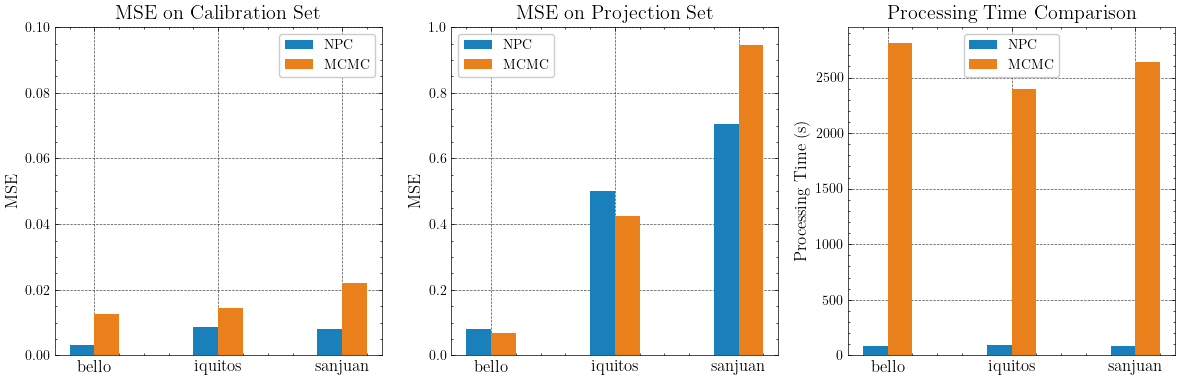

In [53]:
# Visualize the time and error
mse_cali = {
    "bello":    [mse_Hit_npc_bello_cali.detach(), mse_Hit_mcmc_bello_cali.detach()], 
    "iquitos":  [mse_Hit_npc_iquitos_cali.detach(), mse_Hit_mcmc_iquitos_cali.detach()], 
    "sanjuan":  [mse_Hit_npc_sanjuan_cali.detach(), mse_Hit_mcmc_sanjuan_cali.detach()],
}
mse_proj = {
    "bello":    [mse_Hit_npc_bello_proj.detach(), mse_Hit_mcmc_bello_proj.detach()], 
    "iquitos":  [mse_Hit_npc_iquitos_proj.detach(), mse_Hit_mcmc_iquitos_proj.detach()], 
    "sanjuan":  [mse_Hit_npc_sanjuan_proj.detach(), mse_Hit_mcmc_sanjuan_proj.detach()],
}
process_time = {"bello": [86, 2812.6453], "iquitos": [95, 2397.2065], "sanjuan": [83, 2638.1834]}

# Cities and labels
cities = list(mse_cali.keys())
labels = ["NPC", "MCMC"]

# Generate bar plot for MSE
x = np.arange(len(cities))
width = 0.2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# MSE on Calibration set
ax[0].bar(
    x - width / 2,
    [mse_cali[city][0] for city in cities],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[0].bar(
    x + width / 2,
    [mse_cali[city][1] for city in cities],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[0].set_title("MSE on Calibration Set", fontsize="x-large")
ax[0].set_ylabel("MSE", fontsize="large")
ax[0].set_xticks(x)
ax[0].set_xticklabels(cities, fontsize="large")
ax[0].legend(fontsize="medium")
ax[0].grid(True, linestyle="--", alpha=0.7)

# MSE on Projection set
ax[1].bar(
    x - width / 2,
    [mse_proj[city][0] for city in cities],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[1].bar(
    x + width / 2,
    [mse_proj[city][1] for city in cities],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[1].set_title("MSE on Projection Set", fontsize="x-large")
ax[1].set_ylabel("MSE", fontsize="large")
ax[1].set_xticks(x)
ax[1].set_xticklabels(cities, fontsize="large")
ax[1].legend(fontsize="medium")
ax[1].grid(True, linestyle="--", alpha=0.7)

# Processing time plot
ax[2].bar(
    x - width / 2,
    [process_time[city][0] for city in cities],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[2].bar(
    x + width / 2,
    [process_time[city][1] for city in cities],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[2].set_title("Processing Time Comparison", fontsize="x-large")
ax[2].set_ylabel("Processing Time (s)", fontsize="large")
ax[2].set_xticks(x)
ax[2].set_xticklabels(cities, fontsize="large")
ax[2].legend(fontsize="medium")
ax[2].grid(True, linestyle="--", alpha=0.7)

# Set y-axis range to (0, 1)
ax[0].set_ylim(0, 0.1)
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("final_figures/revise_version/mse_calibration_projection_processing_time_city.tiff", dpi=900, format='tiff')
plt.show()

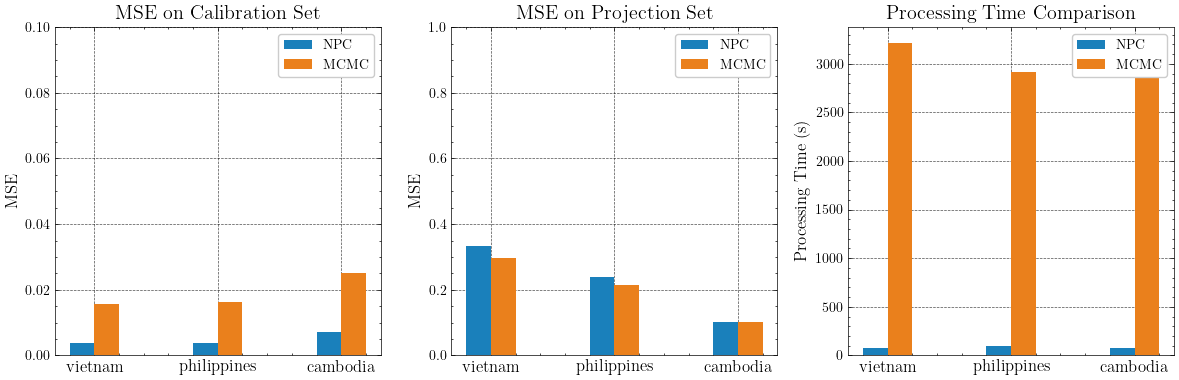

In [54]:
# Visualize the time and error
mse_cali = {
    "vietnam":    [mse_Hit_npc_vietnam_cali.detach(), mse_Hit_mcmc_vietnam_cali.detach()], 
    "philippines":  [mse_Hit_npc_philippines_cali.detach(), mse_Hit_mcmc_philippines_cali.detach()], 
    "cambodia":  [mse_Hit_npc_cambodia_cali.detach(), mse_Hit_mcmc_cambodia_cali.detach()],
}
mse_proj = {
    "vietnam":    [mse_Hit_npc_vietnam_proj.detach(), mse_Hit_mcmc_vietnam_proj.detach()], 
    "philippines":  [mse_Hit_npc_philippines_proj.detach(), mse_Hit_mcmc_philippines_proj.detach()], 
    "cambodia":  [mse_Hit_npc_cambodia_proj.detach(), mse_Hit_mcmc_cambodia_proj.detach()],
}
process_time = {"vietnam": [81, 3217.0232], "philippines": [92, 2915.1864], "cambodia": [76, 2864.2839]}

# Cities and labels
countries = list(mse_cali.keys())
labels = ["NPC", "MCMC"]

# Generate bar plot for MSE
x = np.arange(len(countries))
width = 0.2

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# MSE on Calibration set
ax[0].bar(
    x - width / 2,
    [mse_cali[country][0] for country in countries],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[0].bar(
    x + width / 2,
    [mse_cali[country][1] for country in countries],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[0].set_title("MSE on Calibration Set", fontsize="x-large")
ax[0].set_ylabel("MSE", fontsize="large")
ax[0].set_xticks(x)
ax[0].set_xticklabels(countries, fontsize="large")
ax[0].legend(fontsize="medium")
ax[0].grid(True, linestyle="--", alpha=0.7)

# MSE on Projection set
ax[1].bar(
    x - width / 2,
    [mse_proj[country][0] for country in countries],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[1].bar(
    x + width / 2,
    [mse_proj[country][1] for country in countries],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[1].set_title("MSE on Projection Set", fontsize="x-large")
ax[1].set_ylabel("MSE", fontsize="large")
ax[1].set_xticks(x)
ax[1].set_xticklabels(countries, fontsize="large")
ax[1].legend(fontsize="medium")
ax[1].grid(True, linestyle="--", alpha=0.7)

# Processing time plot
ax[2].bar(
    x - width / 2,
    [process_time[country][0] for country in countries],
    width,
    label=labels[0],
    color="#1a80bb",
)
ax[2].bar(
    x + width / 2,
    [process_time[country][1] for country in countries],
    width,
    label=labels[1],
    color="#ea801c",
)
ax[2].set_title("Processing Time Comparison", fontsize="x-large")
ax[2].set_ylabel("Processing Time (s)", fontsize="large")
ax[2].set_xticks(x)
ax[2].set_xticklabels(countries, fontsize="large")
ax[2].legend(fontsize="medium")
ax[2].grid(True, linestyle="--", alpha=0.7)

# Set y-axis range to (0, 1)
ax[0].set_ylim(0, 0.1)
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("final_figures/revise_version/mse_calibration_projection_processing_time_country.tiff", dpi=900, format='tiff')
plt.show()

# Data window visualization

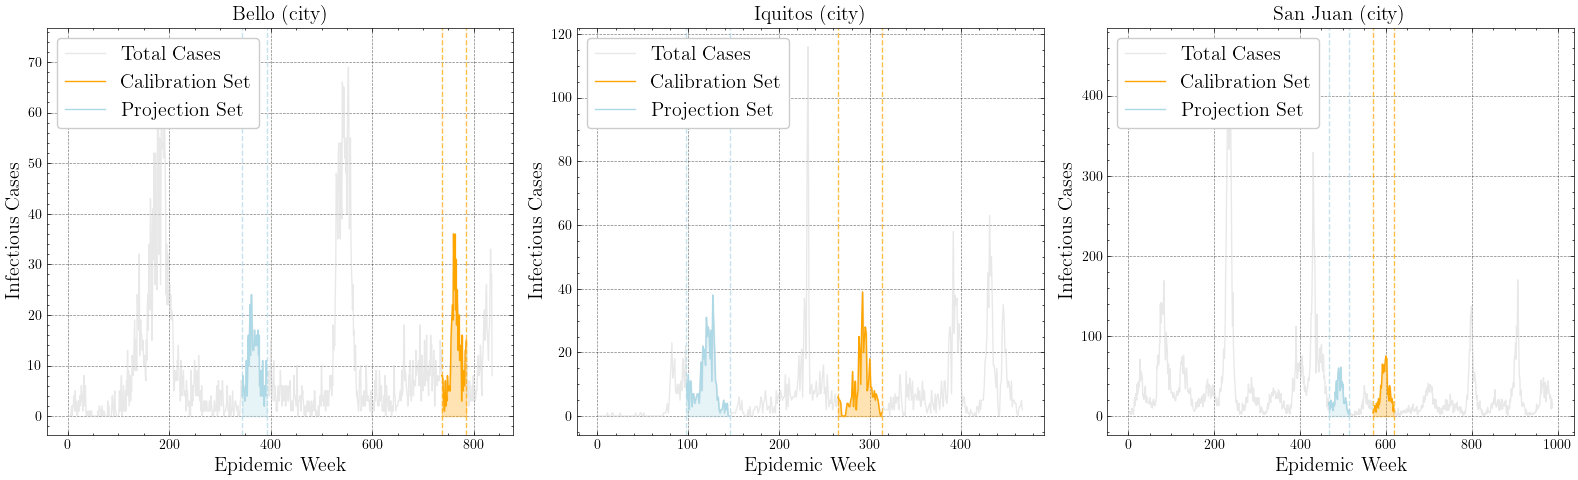

In [55]:
# First figure - top row
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# BELLO, IQUITOS, SAN JUAN
# Bello
bello_hi_true = pd.read_csv("../data/Dengue/bello/DataBello_full.csv").reset_index(drop=True)
bello_x = bello_hi_true['Epidemic_Week'].to_numpy(dtype=float)
bello_y = bello_hi_true['Cases'].to_numpy(dtype=float)
axs[0].plot(bello_x, bello_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
cali_start, cali_end = 737, 785
mask = (bello_x >= cali_start) & (bello_x <= cali_end)
axs[0].plot(bello_x[mask], bello_y[mask], label=f"Calibration Set", color="orange")
axs[0].fill_between(bello_x[mask], bello_y[mask], color="orange", alpha=0.3)
axs[0].axvline(cali_start, color="orange", linestyle="--", alpha=0.7)
axs[0].axvline(cali_end, color="orange", linestyle="--", alpha=0.7)

# Projection Set
proj_start, proj_end = 344, 392
mask = (bello_x >= proj_start) & (bello_x <= proj_end)
axs[0].plot(bello_x[mask], bello_y[mask], label=f"Projection Set", color="lightblue")
axs[0].fill_between(bello_x[mask], bello_y[mask], color="lightblue", alpha=0.3)
axs[0].axvline(proj_start, color="lightblue", linestyle="--", alpha=0.7)
axs[0].axvline(proj_end, color="lightblue", linestyle="--", alpha=0.7)

axs[0].set_title("Bello (city)", fontsize="x-large")
axs[0].set_xlabel("Epidemic Week", fontsize="x-large")
axs[0].set_ylabel("Infectious Cases", fontsize="x-large")
axs[0].legend(fontsize="x-large", loc='upper left')


# Iquitos
iquitos_hi_true = pd.read_csv("../data/Dengue/iquitos/DataIquitos_full.csv").reset_index(drop=True)
iquitos_x = iquitos_hi_true['Epidemic_Week'].to_numpy(dtype=float)
iquitos_y = iquitos_hi_true['Cases'].to_numpy(dtype=float)
axs[1].plot(iquitos_x, iquitos_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
cali_start, cali_end = 265, 313
mask = (iquitos_x >= cali_start) & (iquitos_x <= cali_end)
axs[1].plot(iquitos_x[mask], iquitos_y[mask], label=f"Calibration Set", color="orange")
axs[1].fill_between(iquitos_x[mask], iquitos_y[mask], color="orange", alpha=0.3)
axs[1].axvline(cali_start, color="orange", linestyle="--", alpha=0.7)
axs[1].axvline(cali_end, color="orange", linestyle="--", alpha=0.7)

# Projection Set
cali_start, cali_end = 98, 146
mask = (iquitos_x >= cali_start) & (iquitos_x <= cali_end)
axs[1].plot(iquitos_x[mask], iquitos_y[mask], label=f"Projection Set", color="lightblue")
axs[1].fill_between(iquitos_x[mask], iquitos_y[mask], color="lightblue", alpha=0.3)
axs[1].axvline(cali_start, color="lightblue", linestyle="--", alpha=0.7)
axs[1].axvline(cali_end, color="lightblue", linestyle="--", alpha=0.7)

axs[1].set_title("Iquitos (city)", fontsize="x-large")
axs[1].set_xlabel("Epidemic Week", fontsize="x-large")
axs[1].set_ylabel("Infectious Cases", fontsize="x-large")
axs[1].legend(fontsize="x-large", loc='upper left')


# San Juan
sanjuan_hi_true = pd.read_csv("../data/Dengue/sanjuan/DataSanJuan_full.csv").reset_index(drop=True)
sanjuan_x = sanjuan_hi_true['Epidemic_Week'].to_numpy(dtype=float)
sanjuan_y = sanjuan_hi_true['Cases'].to_numpy(dtype=float)
axs[2].plot(sanjuan_x, sanjuan_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
cali_start, cali_end = 570, 618
mask = (sanjuan_x >= cali_start) & (sanjuan_x <= cali_end)
axs[2].plot(sanjuan_x[mask], sanjuan_y[mask], label=f"Calibration Set", color="orange")
axs[2].fill_between(sanjuan_x[mask], sanjuan_y[mask], color="orange", alpha=0.3)
axs[2].axvline(cali_start, color="orange", linestyle="--", alpha=0.7)
axs[2].axvline(cali_end, color="orange", linestyle="--", alpha=0.7)

# Projection Set
cali_start, cali_end = 467, 515
mask = (sanjuan_x >= cali_start) & (sanjuan_x <= cali_end)
axs[2].plot(sanjuan_x[mask], sanjuan_y[mask], label=f"Projection Set", color="lightblue")
axs[2].fill_between(sanjuan_x[mask], sanjuan_y[mask], color="lightblue", alpha=0.3)
axs[2].axvline(cali_start, color="lightblue", linestyle="--", alpha=0.7)
axs[2].axvline(cali_end, color="lightblue", linestyle="--", alpha=0.7)

axs[2].set_title("San Juan (city)", fontsize="x-large")
axs[2].set_xlabel("Epidemic Week", fontsize="x-large")
axs[2].set_ylabel("Infectious Cases", fontsize="x-large")
axs[2].legend(fontsize="x-large", loc='upper left')

plt.tight_layout()
plt.savefig("final_figures/revise_version/bello_iquitos_sanjuan_time_window.tiff", dpi=900, format='tiff')
plt.show()

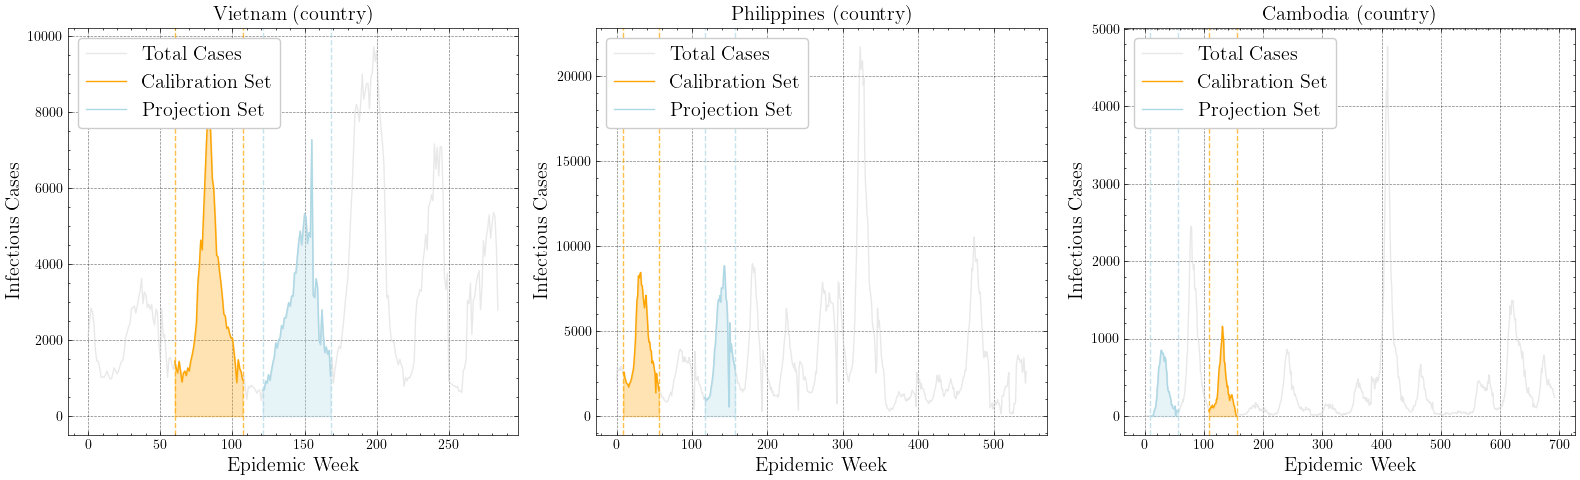

In [56]:
# Second figure - bottom row  
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# VIETNAM, PHILIPPINES, CAMBODIA
opendengue = pd.read_csv("open_dengue/masterDB_V1.3.csv", encoding="latin1")

# VIETNAM
vietnam = opendengue[opendengue["adm_0_name"] == "VIET NAM"].reset_index()
vietnam["calendar_start_date"] = pd.to_datetime(vietnam["calendar_start_date"])
vietnam["calendar_end_date"] = pd.to_datetime(vietnam["calendar_end_date"])
selected_columns = [
    "calendar_start_date", "calendar_end_date", "dengue_total"
]
# Calculate the difference in days
vietnam["period_days"] = (vietnam["calendar_end_date"] 
                          - vietnam["calendar_start_date"]).dt.days
# Filter for weekly data (difference == 6 or 7 days)
vietnam_cases = vietnam[vietnam["adm_1_name"].isnull() & 
    (vietnam["period_days"].between(6, 7))
].sort_values("calendar_start_date")
vietnam_cases = vietnam_cases[selected_columns].reset_index(drop=True)
vietnam_x = vietnam_cases.index.to_numpy(dtype=float)
vietnam_y = vietnam_cases['dengue_total'].to_numpy(dtype=float)
axs[0].plot(vietnam_x, vietnam_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
start_date, end_date = pd.to_datetime("2017-02-25"), pd.to_datetime("2018-02-01")
start_idx = vietnam_cases[vietnam_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = vietnam_cases[vietnam_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (vietnam_x >= start_idx) & (vietnam_x <= end_idx)
axs[0].plot(vietnam_x[mask], vietnam_y[mask], 
               label=f"Calibration Set", color="orange")
axs[0].fill_between(vietnam_x[mask], vietnam_y[mask], 
                       color="orange", alpha=0.3)
axs[0].axvline(start_idx, color="orange", linestyle="--", alpha=0.7)
axs[0].axvline(end_idx, color="orange", linestyle="--", alpha=0.7)

# Projection Set
start_date, end_date = pd.to_datetime("2018-04-25"), pd.to_datetime("2019-04-01")
start_idx = vietnam_cases[vietnam_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = vietnam_cases[vietnam_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (vietnam_x >= start_idx) & (vietnam_x <= end_idx)
axs[0].plot(vietnam_x[mask], vietnam_y[mask], 
               label=f"Projection Set", color="lightblue")
axs[0].fill_between(vietnam_x[mask], vietnam_y[mask], 
                       color="lightblue", alpha=0.3)
axs[0].axvline(start_idx, color="lightblue", linestyle="--", alpha=0.7)
axs[0].axvline(end_idx, color="lightblue", linestyle="--", alpha=0.7)

axs[0].set_title("Vietnam (country)", fontsize="x-large")
axs[0].set_xlabel("Epidemic Week", fontsize="x-large")
axs[0].set_ylabel("Infectious Cases", fontsize="x-large")
axs[0].legend(fontsize="x-large", loc='upper left')


# PHILIPPINES
philippines = opendengue[opendengue["adm_0_name"] == "PHILIPPINES"].reset_index()
philippines["calendar_start_date"] = pd.to_datetime(philippines["calendar_start_date"])
philippines["calendar_end_date"] = pd.to_datetime(philippines["calendar_end_date"])
selected_columns = [
    "calendar_start_date", "calendar_end_date", "dengue_total"
]
# Calculate the difference in days
philippines["period_days"] = (philippines["calendar_end_date"] 
                          - philippines["calendar_start_date"]).dt.days
# Filter for weekly data (difference == 6 or 7 days)
philippines_cases = philippines[philippines["adm_1_name"].isnull() & 
    (philippines["period_days"].between(6, 7))
].sort_values("calendar_start_date")
philippines_cases = philippines_cases[selected_columns].reset_index(drop=True)
philippines_x = philippines_cases.index.to_numpy(dtype=float)
philippines_y = philippines_cases['dengue_total'].to_numpy(dtype=float)
axs[1].plot(philippines_x, philippines_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
start_date, end_date = pd.to_datetime("2013-03-01"), pd.to_datetime("2014-02-01")
start_idx = philippines_cases[philippines_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = philippines_cases[philippines_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (philippines_x >= start_idx) & (philippines_x <= end_idx)
axs[1].plot(philippines_x[mask], philippines_y[mask], 
               label=f"Calibration Set", color="orange")
axs[1].fill_between(philippines_x[mask], philippines_y[mask], 
                       color="orange", alpha=0.3)
axs[1].axvline(start_idx, color="orange", linestyle="--", alpha=0.7)
axs[1].axvline(end_idx, color="orange", linestyle="--", alpha=0.7)

# Projection Set
start_date, end_date = pd.to_datetime("2015-04-01"), pd.to_datetime("2016-03-01")
start_idx = philippines_cases[philippines_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = philippines_cases[philippines_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (philippines_x >= start_idx) & (philippines_x <= end_idx)
axs[1].plot(philippines_x[mask], philippines_y[mask], 
               label=f"Projection Set", color="lightblue")
axs[1].fill_between(philippines_x[mask], philippines_y[mask], 
                       color="lightblue", alpha=0.3)
axs[1].axvline(start_idx, color="lightblue", linestyle="--", alpha=0.7)
axs[1].axvline(end_idx, color="lightblue", linestyle="--", alpha=0.7)

axs[1].set_title("Philippines (country)", fontsize="x-large")
axs[1].set_xlabel("Epidemic Week", fontsize="x-large")
axs[1].set_ylabel("Infectious Cases", fontsize="x-large")
axs[1].legend(fontsize="x-large", loc='upper left')


# CAMBODIA
cambodia = opendengue[opendengue["adm_0_name"] == "CAMBODIA"].reset_index()
cambodia["calendar_start_date"] = pd.to_datetime(cambodia["calendar_start_date"])
cambodia["calendar_end_date"] = pd.to_datetime(cambodia["calendar_end_date"])
selected_columns = [
    "calendar_start_date", "calendar_end_date", "dengue_total"
]
# Calculate the difference in days
cambodia["period_days"] = (cambodia["calendar_end_date"] 
                          - cambodia["calendar_start_date"]).dt.days
# Filter for weekly data (difference == 6 or 7 days)
cambodia_cases = cambodia[(cambodia["period_days"].between(6, 7))].sort_values("calendar_start_date")
cambodia_cases = cambodia_cases[selected_columns].reset_index(drop=True)
cambodia_x = cambodia_cases.index.to_numpy(dtype=float)
cambodia_y = cambodia_cases['dengue_total'].to_numpy(dtype=float)
axs[2].plot(cambodia_x, cambodia_y, color="lightgray", alpha=0.5, label="Total Cases")

# Calibration Set
start_date, end_date = pd.to_datetime("2013-01-25"), pd.to_datetime("2014-01-01")
start_idx = cambodia_cases[cambodia_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = cambodia_cases[cambodia_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (cambodia_x >= start_idx) & (cambodia_x <= end_idx)
axs[2].plot(cambodia_x[mask], cambodia_y[mask], 
               label=f"Calibration Set", color="orange")
axs[2].fill_between(cambodia_x[mask], cambodia_y[mask], 
                       color="orange", alpha=0.3)
axs[2].axvline(start_idx, color="orange", linestyle="--", alpha=0.7)
axs[2].axvline(end_idx, color="orange", linestyle="--", alpha=0.7)

# Projection Set
start_date, end_date = pd.to_datetime("2011-03-01"), pd.to_datetime("2012-02-05")
start_idx = cambodia_cases[cambodia_cases["calendar_start_date"] 
                          >= start_date].index.min()
end_idx = cambodia_cases[cambodia_cases["calendar_end_date"] 
                          <= end_date].index.max()
mask = (cambodia_x >= start_idx) & (cambodia_x <= end_idx)
axs[2].plot(cambodia_x[mask], cambodia_y[mask], 
               label=f"Projection Set", color="lightblue")
axs[2].fill_between(cambodia_x[mask], cambodia_y[mask], 
                       color="lightblue", alpha=0.3)
axs[2].axvline(start_idx, color="lightblue", linestyle="--", alpha=0.7)
axs[2].axvline(end_idx, color="lightblue", linestyle="--", alpha=0.7)

axs[2].set_title("Cambodia (country)", fontsize="x-large")
axs[2].set_xlabel("Epidemic Week", fontsize="x-large")
axs[2].set_ylabel("Infectious Cases", fontsize="x-large")
axs[2].legend(fontsize="x-large", loc='upper left')


plt.tight_layout()
plt.savefig("final_figures/revise_version/vietnam_philippines_cambodia_time_window.tiff", dpi=900, format='tiff')
plt.show()

# Visualise R0 (basic reproductive number) and SA
The value of R0 is being computed in Matlab and we include the output here for visualisation only

In [57]:
import h5py
import numpy as np

def compute_R0(beta_m, beta_h, theta_m, theta_h, mu_m, mu_h, gamma_h):
    numerator = beta_m * beta_h * theta_m * theta_h
    denominator = mu_m * (theta_m + mu_m) * (theta_h + mu_h) * (gamma_h + mu_h)
    return np.sqrt(numerator / denominator)

### Vietnam

dict_keys(['__header__', '__version__', '__globals__', 'ans'])


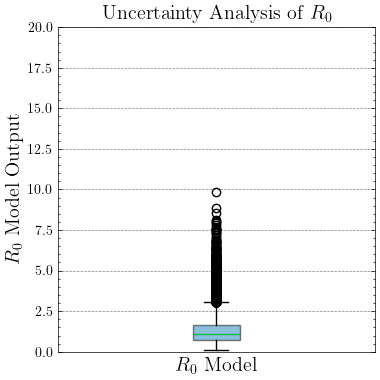

In [58]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load the R0 values from the .mat file
mat = scipy.io.loadmat("vietnam/R0_vietnam.mat")

# Inspect keys to find the correct variable name if needed
print(mat.keys())

# Assuming the variable is named 'R0_bello' in the .mat file
# If not, replace 'R0_bello' with the correct key from the printed keys
R0_values = mat['ans'].squeeze()

# Visualize R0 values with a box plot
plt.figure(figsize=(4, 4))
plt.boxplot(R0_values, vert=True, patch_artist=True, boxprops=dict(facecolor='#1a80bb', alpha=0.5))
plt.xlabel(r"$R_0$ Model", fontsize="x-large")
plt.ylabel(r"$R_0$ Model Output", fontsize="x-large")
plt.title(r"Uncertainty Analysis of $R_0$", fontsize="x-large")
# Increase y-axis tick label size
plt.tick_params(axis='x', labelsize="x-large")
plt.xticks([])
# Set x-axis limit
plt.ylim(0, 20)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/r0_sa/r0_vietnam.png", dpi=300)
plt.show()

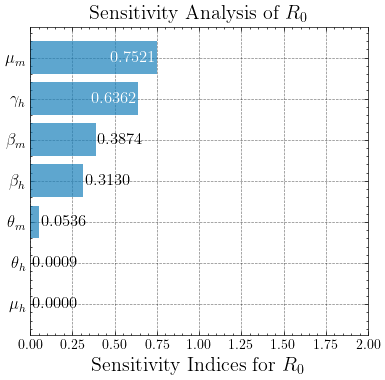

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Use the existing sa_r0 dictionary
sa_r0 = {r"$\beta_m$": 0.3874, r"$\beta_h$": 0.31299, r"$\theta_m$": 0.0536,
         r"$\theta_h$": 0.00087, r"$\mu_m$": 0.75206, r"$\gamma_h$": 0.6362, r"$\mu_h$": 0}

# Sort parameters by value in decreasing order
sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
params = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]
largest_indices = np.argsort(values)[-2:]

plt.figure(figsize=(4, 4))
bars = plt.barh(params, values, color="#1a80bb", alpha=0.7)

for idx, (bar, value) in enumerate(zip(bars, values)):
    if idx in largest_indices:
        # Place inside the bar, at the end
        plt.text(
            bar.get_width() - 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='right',
            fontsize="large",
            color='white' if bar.get_width() > 0.15 else 'black'
        )
    else:
        # Place outside the bar, at the end
        plt.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='left',
            fontsize="large",
            color='black'
        )

plt.xlabel(r"Sensitivity Indices for $R_0$", fontsize="x-large")
plt.title(r"Sensitivity Analysis of $R_0$", fontsize="x-large")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, 2)
plt.tight_layout()
plt.gca().set_yticklabels(params, fontweight='bold', fontsize="large")
# plt.savefig("final_figures/r0_sa/r0_sa_vietnam.png", dpi=300)
plt.show()

### Cambodia

dict_keys(['__header__', '__version__', '__globals__', 'ans'])


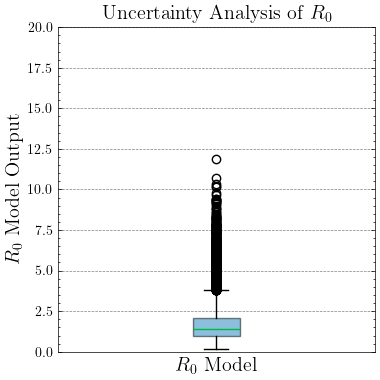

In [60]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load the R0 values from the .mat file
mat = scipy.io.loadmat("cambodia/R0_cambodia.mat")

# Inspect keys to find the correct variable name if needed
print(mat.keys())

# Assuming the variable is named 'R0_bello' in the .mat file
# If not, replace 'R0_bello' with the correct key from the printed keys
R0_values = mat['ans'].squeeze()

# Visualize R0 values with a box plot
plt.figure(figsize=(4, 4))
plt.boxplot(R0_values, vert=True, patch_artist=True, boxprops=dict(facecolor='#1a80bb', alpha=0.5))
plt.xlabel(r"$R_0$ Model", fontsize="x-large")
plt.ylabel(r"$R_0$ Model Output", fontsize="x-large")
plt.title(r"Uncertainty Analysis of $R_0$", fontsize="x-large")
# Increase y-axis tick label size
plt.tick_params(axis='x', labelsize="x-large")
plt.xticks([])
# Set x-axis limit
plt.ylim(0, 20)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/r0_sa/r0_cambodia.png", dpi=300)
plt.show()

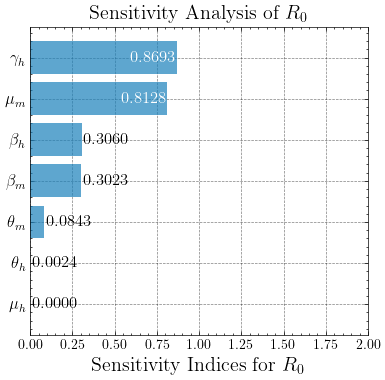

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Use the existing sa_r0 dictionary
sa_r0 = {r"$\beta_m$": 0.3023, r"$\beta_h$": 0.306, r"$\theta_m$": 0.0843,
         r"$\theta_h$": 0.0024, r"$\mu_m$": 0.8128, r"$\gamma_h$": 0.8693, r"$\mu_h$": 0}

# Sort parameters by value in decreasing order
sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
params = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]
largest_indices = np.argsort(values)[-2:]

plt.figure(figsize=(4, 4))
bars = plt.barh(params, values, color="#1a80bb", alpha=0.7)

for idx, (bar, value) in enumerate(zip(bars, values)):
    if idx in largest_indices:
        # Place inside the bar, at the end
        plt.text(
            bar.get_width() - 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='right',
            fontsize="large",
            color='white' if bar.get_width() > 0.15 else 'black'
        )
    else:
        # Place outside the bar, at the end
        plt.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='left',
            fontsize="large",
            color='black'
        )

plt.xlabel(r"Sensitivity Indices for $R_0$", fontsize="x-large")
plt.title(r"Sensitivity Analysis of $R_0$", fontsize="x-large")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, 2)
plt.tight_layout()
plt.gca().set_yticklabels(params, fontweight='bold', fontsize="large")
# plt.savefig("final_figures/r0_sa/r0_sa_cambodia.png", dpi=300)
plt.show()

### Philipines

dict_keys(['__header__', '__version__', '__globals__', 'ans'])


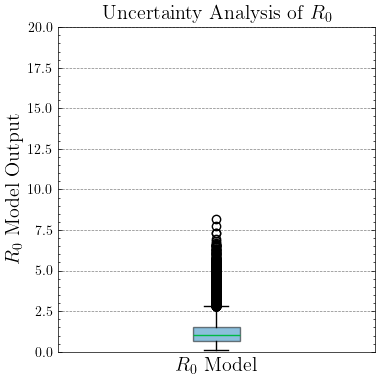

In [62]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load the R0 values from the .mat file
mat = scipy.io.loadmat("philippines/R0_philippines.mat")

# Inspect keys to find the correct variable name if needed
print(mat.keys())

# Assuming the variable is named 'R0_bello' in the .mat file
# If not, replace 'R0_bello' with the correct key from the printed keys
R0_values = mat['ans'].squeeze()

# Visualize R0 values with a box plot
plt.figure(figsize=(4, 4))
plt.boxplot(R0_values, vert=True, patch_artist=True, boxprops=dict(facecolor='#1a80bb', alpha=0.5))
plt.xlabel(r"$R_0$ Model", fontsize="x-large")
plt.ylabel(r"$R_0$ Model Output", fontsize="x-large")
plt.title(r"Uncertainty Analysis of $R_0$", fontsize="x-large")
# Increase y-axis tick label size
plt.tick_params(axis='x', labelsize="x-large")
plt.xticks([])
# Set x-axis limit
plt.ylim(0, 20)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/r0_sa/r0_philippines.png", dpi=300)
plt.show()

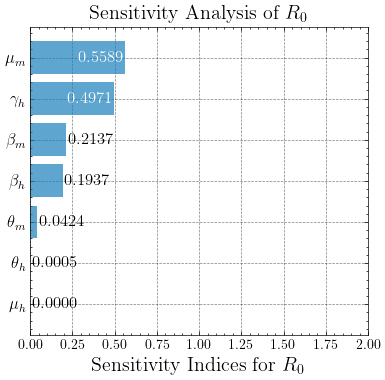

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# Use the existing sa_r0 dictionary
sa_r0 = {r"$\beta_m$": 0.2137, r"$\beta_h$": 0.1937, r"$\theta_m$": 0.0424,
         r"$\theta_h$": 0.0005, r"$\mu_m$": 0.5589, r"$\gamma_h$": 0.4971, r"$\mu_h$": 0}

# Sort parameters by value in decreasing order
sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
params = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]
largest_indices = np.argsort(values)[-2:]

plt.figure(figsize=(4, 4))
bars = plt.barh(params, values, color="#1a80bb", alpha=0.7)

for idx, (bar, value) in enumerate(zip(bars, values)):
    if idx in largest_indices:
        # Place inside the bar, at the end
        plt.text(
            bar.get_width() - 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='right',
            fontsize="large",
            color='white' if bar.get_width() > 0.15 else 'black'
        )
    else:
        # Place outside the bar, at the end
        plt.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='left',
            fontsize="large",
            color='black'
        )

plt.xlabel(r"Sensitivity Indices for $R_0$", fontsize="x-large")
plt.title(r"Sensitivity Analysis of $R_0$", fontsize="x-large")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, 2)
plt.tight_layout()
plt.gca().set_yticklabels(params, fontweight='bold', fontsize="large")
# plt.savefig("final_figures/r0_sa/r0_sa_philippines.png", dpi=300)
plt.show()

### 3 countries together

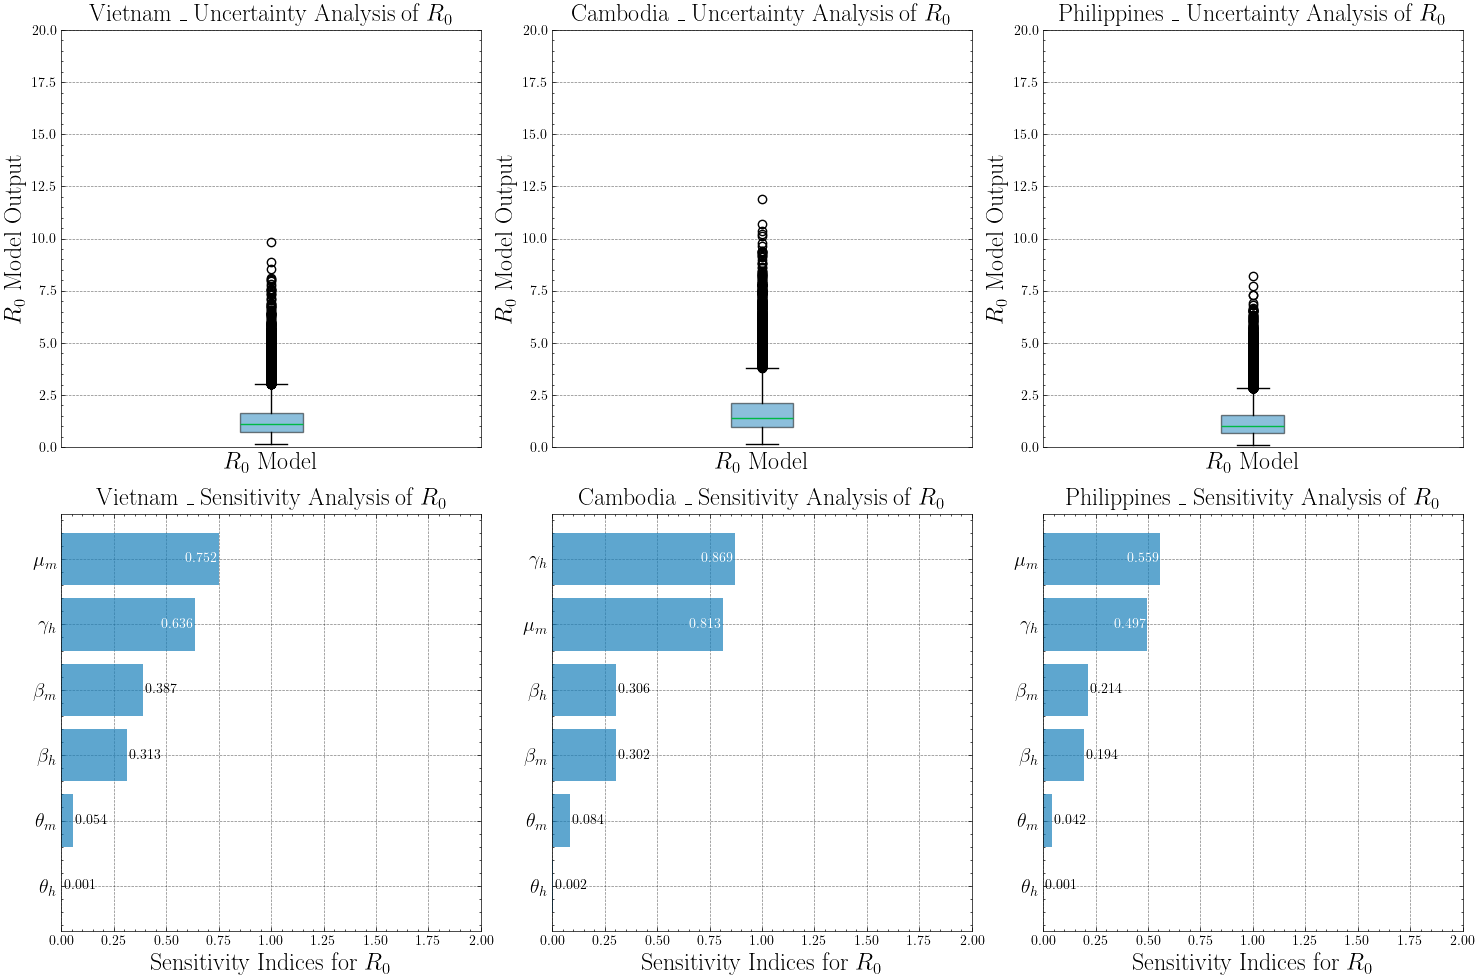

In [64]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# Country data configuration
countries = {
    'Vietnam': {
        'mat_file': 'vietnam/R0_vietnam.mat',
        'sa_data': {r"$\beta_m$": 0.3874, r"$\beta_h$": 0.31299, r"$\theta_m$": 0.0536,
                    r"$\theta_h$": 0.00087, r"$\mu_m$": 0.75206, r"$\gamma_h$": 0.6362}
    },
    'Cambodia': {
        'mat_file': 'cambodia/R0_cambodia.mat',
        'sa_data': {r"$\beta_m$": 0.3023, r"$\beta_h$": 0.306, r"$\theta_m$": 0.0843,
                    r"$\theta_h$": 0.0024, r"$\mu_m$": 0.8128, r"$\gamma_h$": 0.8693}
    },
    'Philippines': {
        'mat_file': 'philippines/R0_philippines.mat',
        'sa_data': {r"$\beta_m$": 0.2137, r"$\beta_h$": 0.1937, r"$\theta_m$": 0.0424,
                    r"$\theta_h$": 0.0005, r"$\mu_m$": 0.5589, r"$\gamma_h$": 0.4971}
    }
}

# Create the 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, (country_name, country_data) in enumerate(countries.items()):
    # Load R0 data
    mat = scipy.io.loadmat(country_data['mat_file'])
    R0_values = mat['ans'].squeeze()
    
    # Top row: R0 box plots
    ax_r0 = axes[0, col]
    ax_r0.boxplot(R0_values, vert=True, patch_artist=True, 
                  boxprops=dict(facecolor='#1a80bb', alpha=0.5))
    ax_r0.set_xlabel(r"$R_0$ Model", fontsize="xx-large")
    ax_r0.set_ylabel(r"$R_0$ Model Output", fontsize="xx-large")
    ax_r0.set_title(f"{country_name} _ Uncertainty Analysis of $R_0$", fontsize="xx-large")
    ax_r0.tick_params(axis='x', labelsize="x-large")
    ax_r0.set_xticks([])
    ax_r0.set_ylim(0, 20)
    ax_r0.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # Bottom row: Sensitivity analysis
    ax_sa = axes[1, col]
    sa_r0 = country_data['sa_data']
    
    # Sort parameters by value
    sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
    params = [k for k, v in sorted_items]
    values = [v for k, v in sorted_items]
    largest_indices = np.argsort(values)[-2:]
    
    bars = ax_sa.barh(params, values, color="#1a80bb", alpha=0.7)
    
    # Add value labels on bars
    for idx, (bar, value) in enumerate(zip(bars, values)):
        if idx in largest_indices:
            ax_sa.text(
                bar.get_width() - 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va='center',
                ha='right',
                fontsize="medium",
                color='white' if bar.get_width() > 0.15 else 'black'
            )
        else:
            ax_sa.text(
                bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va='center',
                ha='left',
                fontsize="medium",
                color='black'
            )
    
    ax_sa.set_xlabel(r"Sensitivity Indices for $R_0$", fontsize="xx-large")
    ax_sa.set_title(f"{country_name} _ Sensitivity Analysis of $R_0$", fontsize="xx-large")
    ax_sa.grid(axis='x', linestyle='--', alpha=0.5)
    ax_sa.set_xlim(0, 2.0)
    ax_sa.set_yticklabels(params, fontweight='bold', fontsize="x-large")

plt.tight_layout()
plt.savefig("final_figures/revise_version/r0_sa_analysis_country.tiff", dpi=900, format='tiff')
plt.show()

### Bello

dict_keys(['__header__', '__version__', '__globals__', 'ans'])


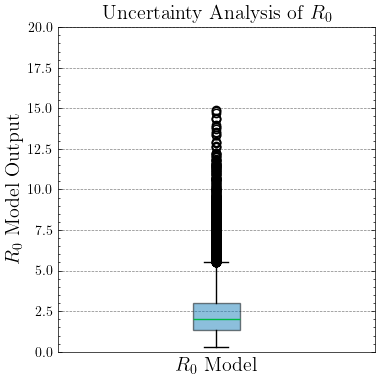

In [65]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load the R0 values from the .mat file
mat = scipy.io.loadmat("bello/R0_bello.mat")

# Inspect keys to find the correct variable name if needed
print(mat.keys())

# Assuming the variable is named 'R0_bello' in the .mat file
# If not, replace 'R0_bello' with the correct key from the printed keys
R0_values = mat['ans'].squeeze()

# Visualize R0 values with a box plot
plt.figure(figsize=(4, 4))
plt.boxplot(R0_values, vert=True, patch_artist=True, boxprops=dict(facecolor='#1a80bb', alpha=0.5))
plt.xlabel(r"$R_0$ Model", fontsize="x-large")
plt.ylabel(r"$R_0$ Model Output", fontsize="x-large")
plt.title(r"Uncertainty Analysis of $R_0$", fontsize="x-large")
# Increase y-axis tick label size
plt.tick_params(axis='x', labelsize="x-large")
plt.xticks([])
# Set x-axis limit
plt.ylim(0, 20)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/r0_sa/r0_bello.png", dpi=300)
plt.show()

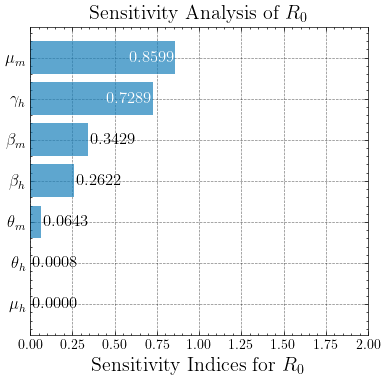

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Use the existing sa_r0 dictionary
sa_r0 = {r"$\beta_m$": 0.3429, r"$\beta_h$": 0.2622, r"$\theta_m$": 0.0643,
         r"$\theta_h$": 0.000758, r"$\mu_m$": 0.8599, r"$\gamma_h$": 0.7289, r"$\mu_h$": 0}

# Sort parameters by value in decreasing order
sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
params = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]
largest_indices = np.argsort(values)[-2:]

plt.figure(figsize=(4, 4))
bars = plt.barh(params, values, color="#1a80bb", alpha=0.7)

for idx, (bar, value) in enumerate(zip(bars, values)):
    if idx in largest_indices:
        # Place inside the bar, at the end
        plt.text(
            bar.get_width() - 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='right',
            fontsize="large",
            color='white' if bar.get_width() > 0.15 else 'black'
        )
    else:
        # Place outside the bar, at the end
        plt.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='left',
            fontsize="large",
            color='black'
        )

plt.xlabel(r"Sensitivity Indices for $R_0$", fontsize="x-large")
plt.title(r"Sensitivity Analysis of $R_0$", fontsize="x-large")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, 2)
plt.tight_layout()
plt.gca().set_yticklabels(params, fontweight='bold', fontsize="large")
# plt.savefig("final_figures/r0_sa/r0_sa_bello.png", dpi=300)
plt.show()

### Iquitos

dict_keys(['__header__', '__version__', '__globals__', 'ans'])


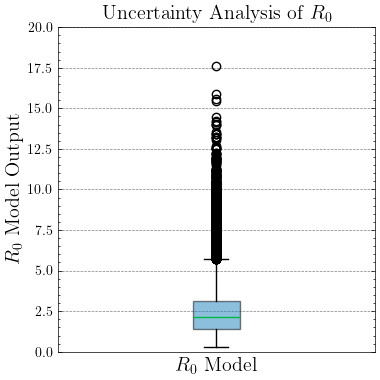

In [67]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load the R0 values from the .mat file
mat = scipy.io.loadmat("iquitos/R0_iquitos.mat")

# Inspect keys to find the correct variable name if needed
print(mat.keys())

# Assuming the variable is named 'R0_bello' in the .mat file
# If not, replace 'R0_bello' with the correct key from the printed keys
R0_values = mat['ans'].squeeze()

# Visualize R0 values with a box plot
plt.figure(figsize=(4, 4))
plt.boxplot(R0_values, vert=True, patch_artist=True, boxprops=dict(facecolor='#1a80bb', alpha=0.5))
plt.xlabel(r"$R_0$ Model", fontsize="x-large")
plt.ylabel(r"$R_0$ Model Output", fontsize="x-large")
plt.title(r"Uncertainty Analysis of $R_0$", fontsize="x-large")
# Increase y-axis tick label size
plt.tick_params(axis='x', labelsize="x-large")
plt.xticks([])
# Set x-axis limit
plt.ylim(0, 20)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/r0_sa/r0_iquitos.png", dpi=300)
plt.show()

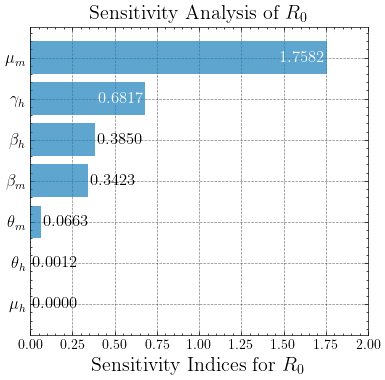

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Use the existing sa_r0 dictionary
sa_r0 = {r"$\beta_m$": 0.3423, r"$\beta_h$": 0.3850, r"$\theta_m$": 0.0663,
         r"$\theta_h$": 0.0012, r"$\mu_m$": 1.7582, r"$\gamma_h$": 0.6817, r"$\mu_h$": 0}

# Sort parameters by value in decreasing order
sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
params = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]
largest_indices = np.argsort(values)[-2:]

plt.figure(figsize=(4, 4))
bars = plt.barh(params, values, color="#1a80bb", alpha=0.7)

for idx, (bar, value) in enumerate(zip(bars, values)):
    if idx in largest_indices:
        # Place inside the bar, at the end
        plt.text(
            bar.get_width() - 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='right',
            fontsize="large",
            color='white' if bar.get_width() > 0.15 else 'black'
        )
    else:
        # Place outside the bar, at the end
        plt.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='left',
            fontsize="large",
            color='black'
        )

plt.xlabel(r"Sensitivity Indices for $R_0$", fontsize="x-large")
plt.title(r"Sensitivity Analysis of $R_0$", fontsize="x-large")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, 2)
plt.tight_layout()
plt.gca().set_yticklabels(params, fontweight='bold', fontsize="large")
# plt.savefig("final_figures/r0_sa/r0_sa_iquitos.png", dpi=300)
plt.show()

### San Juan

dict_keys(['__header__', '__version__', '__globals__', 'ans'])


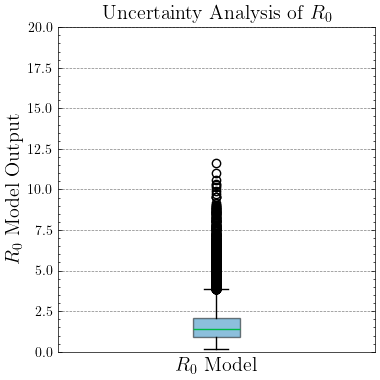

In [69]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt

# Load the R0 values from the .mat file
mat = scipy.io.loadmat("sanjuan/R0_sanjuan.mat")

# Inspect keys to find the correct variable name if needed
print(mat.keys())

# Assuming the variable is named 'R0_bello' in the .mat file
# If not, replace 'R0_bello' with the correct key from the printed keys
R0_values = mat['ans'].squeeze()

# Visualize R0 values with a box plot
plt.figure(figsize=(4, 4))
plt.boxplot(R0_values, vert=True, patch_artist=True, boxprops=dict(facecolor='#1a80bb', alpha=0.5))
plt.xlabel(r"$R_0$ Model", fontsize="x-large")
plt.ylabel(r"$R_0$ Model Output", fontsize="x-large")
plt.title(r"Uncertainty Analysis of $R_0$", fontsize="x-large")
# Increase y-axis tick label size
plt.tick_params(axis='x', labelsize="x-large")
plt.xticks([])
# Set x-axis limit
plt.ylim(0, 20)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/r0_sa/r0_sanjuan.png", dpi=300)
plt.show()

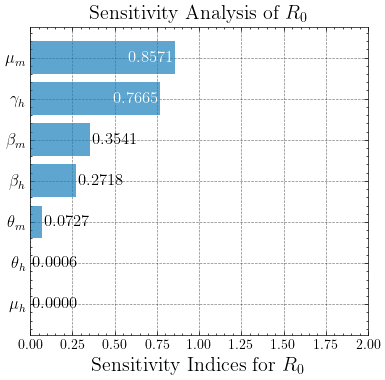

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Use the existing sa_r0 dictionary
sa_r0 = {r"$\beta_m$": 0.3541, r"$\beta_h$": 0.2718, r"$\theta_m$": 0.0727,
         r"$\theta_h$": 0.00055, r"$\mu_m$": 0.8571, r"$\gamma_h$": 0.7665, r"$\mu_h$": 0}

# Sort parameters by value in decreasing order
sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
params = [k for k, v in sorted_items]
values = [v for k, v in sorted_items]
largest_indices = np.argsort(values)[-2:]

plt.figure(figsize=(4, 4))
bars = plt.barh(params, values, color="#1a80bb", alpha=0.7)

for idx, (bar, value) in enumerate(zip(bars, values)):
    if idx in largest_indices:
        # Place inside the bar, at the end
        plt.text(
            bar.get_width() - 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='right',
            fontsize="large",
            color='white' if bar.get_width() > 0.15 else 'black'
        )
    else:
        # Place outside the bar, at the end
        plt.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.4f}",
            va='center',
            ha='left',
            fontsize="large",
            color='black'
        )

plt.xlabel(r"Sensitivity Indices for $R_0$", fontsize="x-large")
plt.title(r"Sensitivity Analysis of $R_0$", fontsize="x-large")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xlim(0, 2)
plt.tight_layout()
plt.gca().set_yticklabels(params, fontweight='bold', fontsize="large")
# plt.savefig("final_figures/r0_sa/r0_sa_sanjuan.png", dpi=300)
plt.show()

### 3 cities together

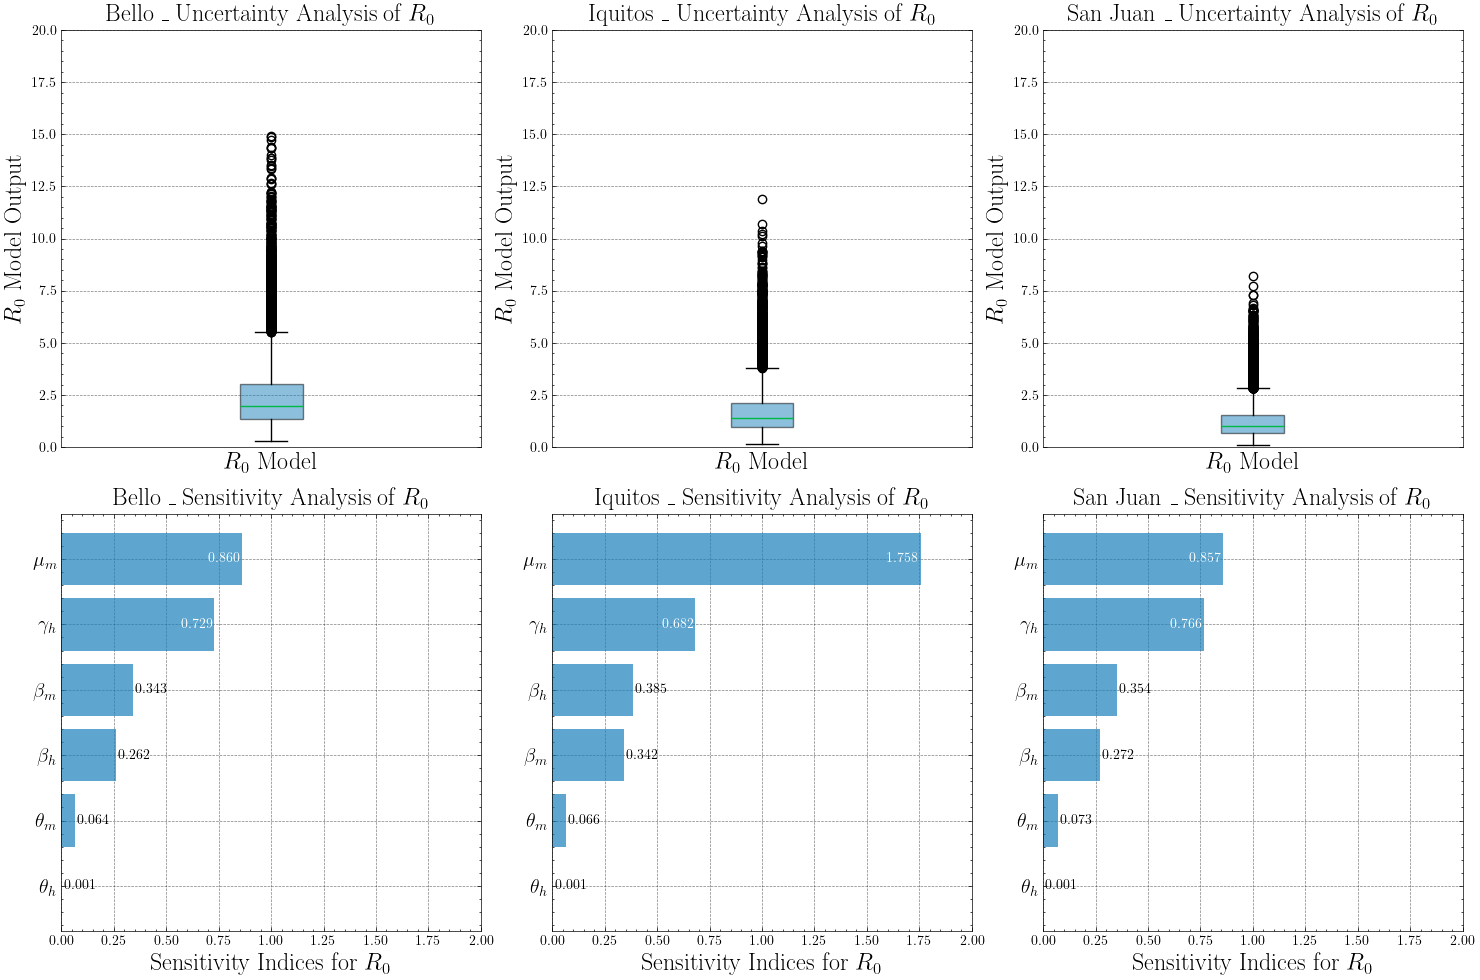

In [71]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# City data configuration
cities = {
    'Bello': {
        'mat_file': 'bello/R0_bello.mat',
        'sa_data': {r"$\beta_m$": 0.3429, r"$\beta_h$": 0.2622, r"$\theta_m$": 0.0643,
                    r"$\theta_h$": 0.000758, r"$\mu_m$": 0.8599, r"$\gamma_h$": 0.7289}
    },
    'Iquitos': {
        'mat_file': 'cambodia/R0_cambodia.mat',
        'sa_data': {r"$\beta_m$": 0.3423, r"$\beta_h$": 0.3850, r"$\theta_m$": 0.0663,
                    r"$\theta_h$": 0.0012, r"$\mu_m$": 1.7582, r"$\gamma_h$": 0.6817}
    },
    'San Juan': {
        'mat_file': 'philippines/R0_philippines.mat',
        'sa_data': {r"$\beta_m$": 0.3541, r"$\beta_h$": 0.2718, r"$\theta_m$": 0.0727,
                    r"$\theta_h$": 0.00055, r"$\mu_m$": 0.8571, r"$\gamma_h$": 0.7665}
    }
}

# Create the 2x3 subplot figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col, (city_name, city_data) in enumerate(cities.items()):
    # Load R0 data
    mat = scipy.io.loadmat(city_data['mat_file'])
    R0_values = mat['ans'].squeeze()
    
    # Top row: R0 box plots
    ax_r0 = axes[0, col]
    ax_r0.boxplot(R0_values, vert=True, patch_artist=True, 
                  boxprops=dict(facecolor='#1a80bb', alpha=0.5))
    ax_r0.set_xlabel(r"$R_0$ Model", fontsize="xx-large")
    ax_r0.set_ylabel(r"$R_0$ Model Output", fontsize="xx-large")
    ax_r0.set_title(f"{city_name} _ Uncertainty Analysis of $R_0$", fontsize="xx-large")
    ax_r0.tick_params(axis='x', labelsize="x-large")
    ax_r0.set_xticks([])
    ax_r0.set_ylim(0, 20)
    ax_r0.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # Bottom row: Sensitivity analysis
    ax_sa = axes[1, col]
    sa_r0 = city_data['sa_data']
    
    # Sort parameters by value
    sorted_items = sorted(sa_r0.items(), key=lambda x: x[1], reverse=False)
    params = [k for k, v in sorted_items]
    values = [v for k, v in sorted_items]
    largest_indices = np.argsort(values)[-2:]
    
    bars = ax_sa.barh(params, values, color="#1a80bb", alpha=0.7)
    
    # Add value labels on bars
    for idx, (bar, value) in enumerate(zip(bars, values)):
        if idx in largest_indices:
            ax_sa.text(
                bar.get_width() - 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va='center',
                ha='right',
                fontsize="medium",
                color='white' if bar.get_width() > 0.15 else 'black'
            )
        else:
            ax_sa.text(
                bar.get_width() + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.3f}",
                va='center',
                ha='left',
                fontsize="medium",
                color='black'
            )
    
    ax_sa.set_xlabel(r"Sensitivity Indices for $R_0$", fontsize="xx-large")
    ax_sa.set_title(f"{city_name} _ Sensitivity Analysis of $R_0$", fontsize="xx-large")
    ax_sa.grid(axis='x', linestyle='--', alpha=0.5)
    ax_sa.set_xlim(0, 2.0)
    ax_sa.set_yticklabels(params, fontweight='bold', fontsize="x-large")

plt.tight_layout()
plt.savefig("final_figures/revise_version/r0_sa_analysis_city.tiff", dpi=900, format='tiff')
plt.show()

# Visualizse MSE along training epochs

### Bello

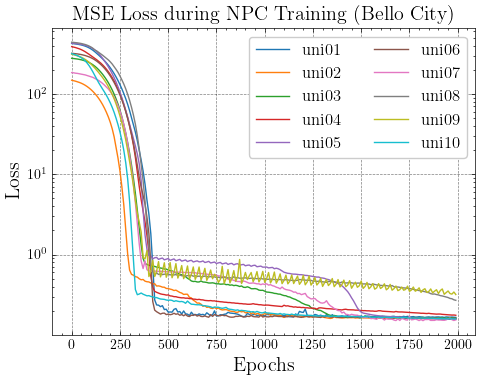

In [72]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Plot the loss of each uni in one plot
plt.figure(figsize=(5, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for i in range(1, 11):
    folder = f"bello/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        # Assume loss is shape (n_samples,) or (n_samples, 1)
        loss = hf["Dengue"]["loss"][:]
        if loss.ndim > 1:
            loss = loss.squeeze()
        x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
        plt.plot(x, loss, label=f"uni{str(i).zfill(2)}", color=colors[i-1])

plt.xlabel("Epochs", fontsize="x-large")
plt.ylabel("Loss", fontsize="x-large")
plt.title("MSE Loss during NPC Training (Bello City)", fontsize="x-large")
plt.yscale("log")  # <-- Use log scale for y-axis
plt.legend(fontsize="large", ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/npc_loss/loss_per_uni_bello.jpg", dpi=300)
plt.show()

### Iquitos

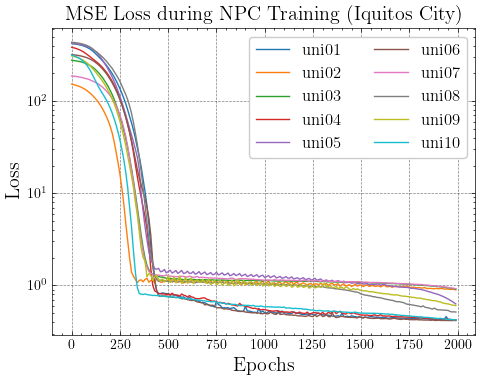

In [73]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Plot the loss of each uni in one plot
plt.figure(figsize=(5, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for i in range(1, 11):
    folder = f"iquitos/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        # Assume loss is shape (n_samples,) or (n_samples, 1)
        loss = hf["Dengue"]["loss"][:]
        if loss.ndim > 1:
            loss = loss.squeeze()
        x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
        plt.plot(x, loss, label=f"uni{str(i).zfill(2)}", color=colors[i-1])

plt.xlabel("Epochs", fontsize="x-large")
plt.ylabel("Loss", fontsize="x-large")
plt.title("MSE Loss during NPC Training (Iquitos City)", fontsize="x-large")
plt.yscale("log")  # <-- Use log scale for y-axis
plt.legend(fontsize="large", ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/npc_loss/loss_per_uni_iquitos.jpg", dpi=300)
plt.show()

### San Juan

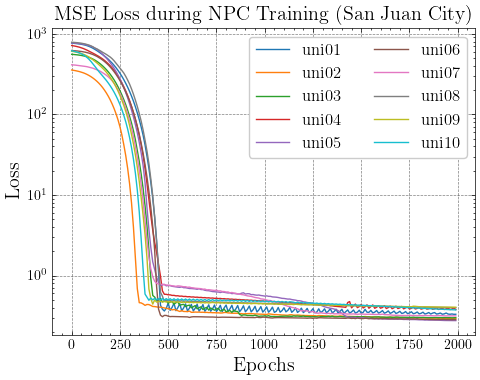

In [74]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Plot the loss of each uni in one plot
plt.figure(figsize=(5, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for i in range(1, 11):
    folder = f"sanjuan/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        # Assume loss is shape (n_samples,) or (n_samples, 1)
        loss = hf["Dengue"]["loss"][:]
        if loss.ndim > 1:
            loss = loss.squeeze()
        x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
        plt.plot(x, loss, label=f"uni{str(i).zfill(2)}", color=colors[i-1])

plt.xlabel("Epochs", fontsize="x-large")
plt.ylabel("Loss", fontsize="x-large")
plt.title("MSE Loss during NPC Training (San Juan City)", fontsize="x-large")
plt.yscale("log")  # <-- Use log scale for y-axis
plt.legend(fontsize="large", ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/npc_loss/loss_per_uni_sanjuan.jpg", dpi=300)
plt.show()

### Visualise MSE for 3 cities

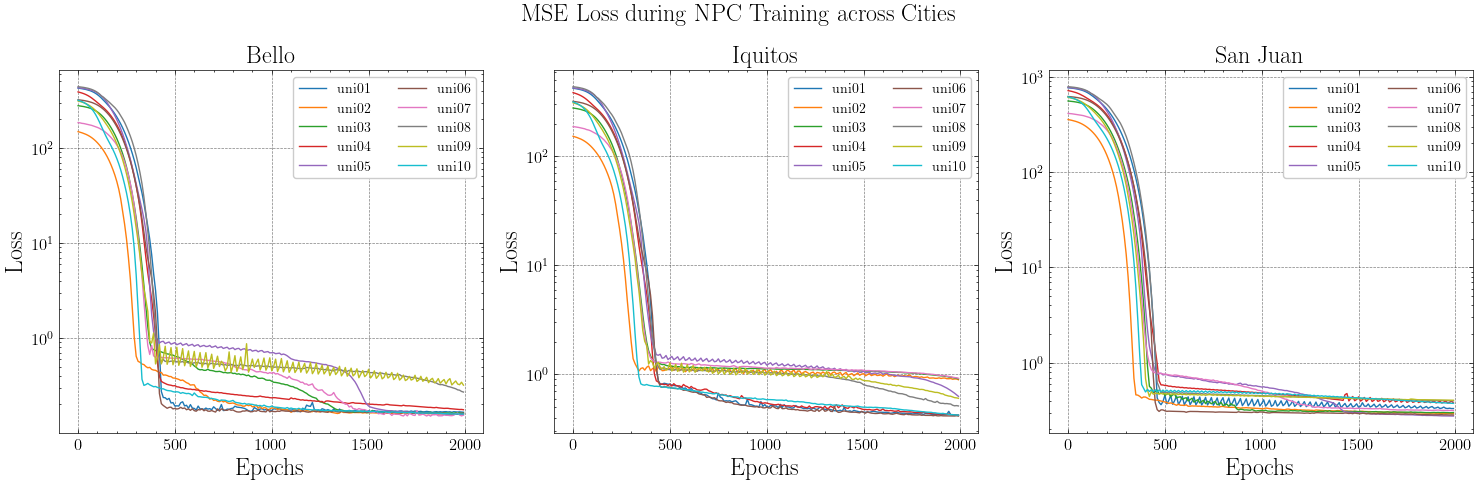

In [75]:
# Combined loss plots for 3 cities in one figure (1 row, 3 columns)
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Configuration for cities
cities = [
    {"name": "Bello", "folder": "bello", "ax": axes[0]},
    {"name": "Iquitos", "folder": "iquitos", "ax": axes[1]}, 
    {"name": "San Juan", "folder": "sanjuan", "ax": axes[2]}
]

colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for city in cities:
    ax = city["ax"]
    
    # Plot loss for each uni (1-10) for this city
    for i in range(1, 11):
        folder = f"{city['folder']}/data/uni{str(i).zfill(2)}"
        h5_path = os.path.join(folder, "data.h5")
        if not os.path.exists(h5_path):
            print(f"File not found: {h5_path}")
            continue
        
        with h5py.File(h5_path, "r") as hf:
            # Assume loss is shape (n_samples,) or (n_samples, 1)
            loss = hf["Dengue"]["loss"][:]
            if loss.ndim > 1:
                loss = loss.squeeze()
            x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
            ax.plot(x, loss, label=f"uni{str(i).zfill(2)}", color=colors[i-1])
    
    # Set properties for each subplot
    ax.set_xlabel("Epochs", fontsize="xx-large")
    ax.set_ylabel("Loss", fontsize="xx-large")
    ax.set_title(f"{city['name']}", fontsize="xx-large")
    ax.set_yscale("log")  # Use log scale for y-axis
    ax.tick_params(labelsize='large')
    ax.legend(fontsize="medium", ncol=2)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add overall title
fig.suptitle("MSE Loss during NPC Training across Cities", fontsize="xx-large", fontweight="bold")

plt.tight_layout()
plt.savefig("final_figures/revise_version/npc_loss_3_cities.tiff", dpi=900, format='tiff')
plt.show()

### Vietnam

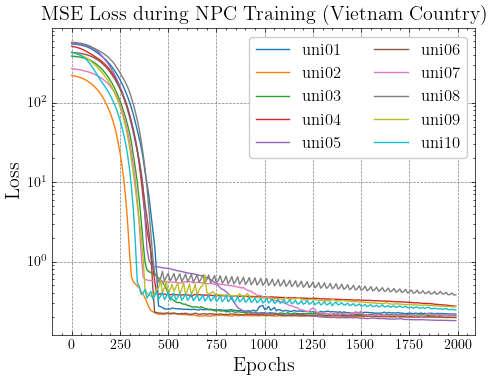

In [76]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Plot the loss of each uni in one plot
plt.figure(figsize=(5, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for i in range(1, 11):
    folder = f"vietnam/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        # Assume loss is shape (n_samples,) or (n_samples, 1)
        loss = hf["Dengue"]["loss"][:]
        if loss.ndim > 1:
            loss = loss.squeeze()
        x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
        plt.plot(x, loss, label=f"uni{str(i).zfill(2)}", color=colors[i-1])

plt.xlabel("Epochs", fontsize="x-large")
plt.ylabel("Loss", fontsize="x-large")
plt.title("MSE Loss during NPC Training (Vietnam Country)", fontsize="x-large")
plt.yscale("log")  # <-- Use log scale for y-axis
plt.legend(fontsize="large", ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/npc_loss/loss_per_uni_vietnam.jpg", dpi=300)
plt.show()

### Philippines

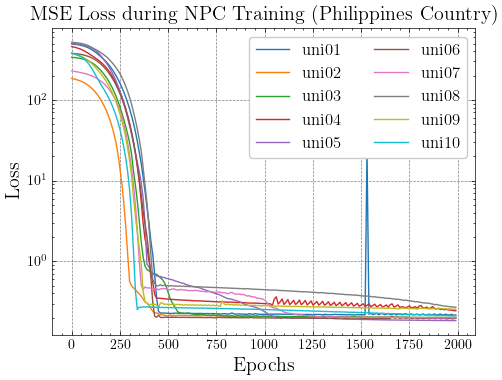

In [77]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Plot the loss of each uni in one plot
plt.figure(figsize=(5, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for i in range(1, 11):
    folder = f"philippines/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        # Assume loss is shape (n_samples,) or (n_samples, 1)
        loss = hf["Dengue"]["loss"][:]
        if loss.ndim > 1:
            loss = loss.squeeze()
        x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
        plt.plot(x, loss, label=f"uni{str(i).zfill(2)}", color=colors[i-1])

plt.xlabel("Epochs", fontsize="x-large")
plt.ylabel("Loss", fontsize="x-large")
plt.title("MSE Loss during NPC Training (Philippines Country)", fontsize="x-large")
plt.yscale("log")  # <-- Use log scale for y-axis
plt.legend(fontsize="large", ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/npc_loss/loss_per_uni_philippines.jpg", dpi=300)
plt.show()

### Cambodia

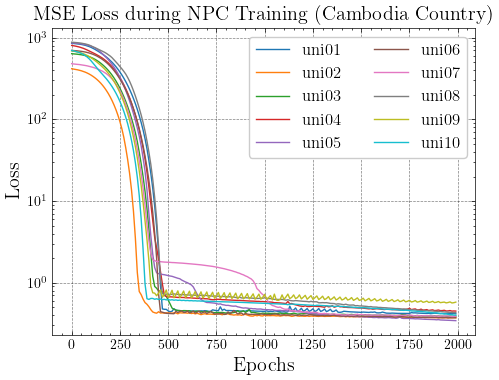

In [78]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Plot the loss of each uni in one plot
plt.figure(figsize=(5, 4))
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for i in range(1, 11):
    folder = f"cambodia/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        # Assume loss is shape (n_samples,) or (n_samples, 1)
        loss = hf["Dengue"]["loss"][:]
        if loss.ndim > 1:
            loss = loss.squeeze()
        x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
        plt.plot(x, loss, label=f"uni{str(i).zfill(2)}", color=colors[i-1])

plt.xlabel("Epochs", fontsize="x-large")
plt.ylabel("Loss", fontsize="x-large")
plt.title("MSE Loss during NPC Training (Cambodia Country)", fontsize="x-large")
plt.yscale("log")  # <-- Use log scale for y-axis
plt.legend(fontsize="large", ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig("final_figures/npc_loss/loss_per_uni_cambodia.jpg", dpi=300)
plt.show()

### NPC loss in 3 countries

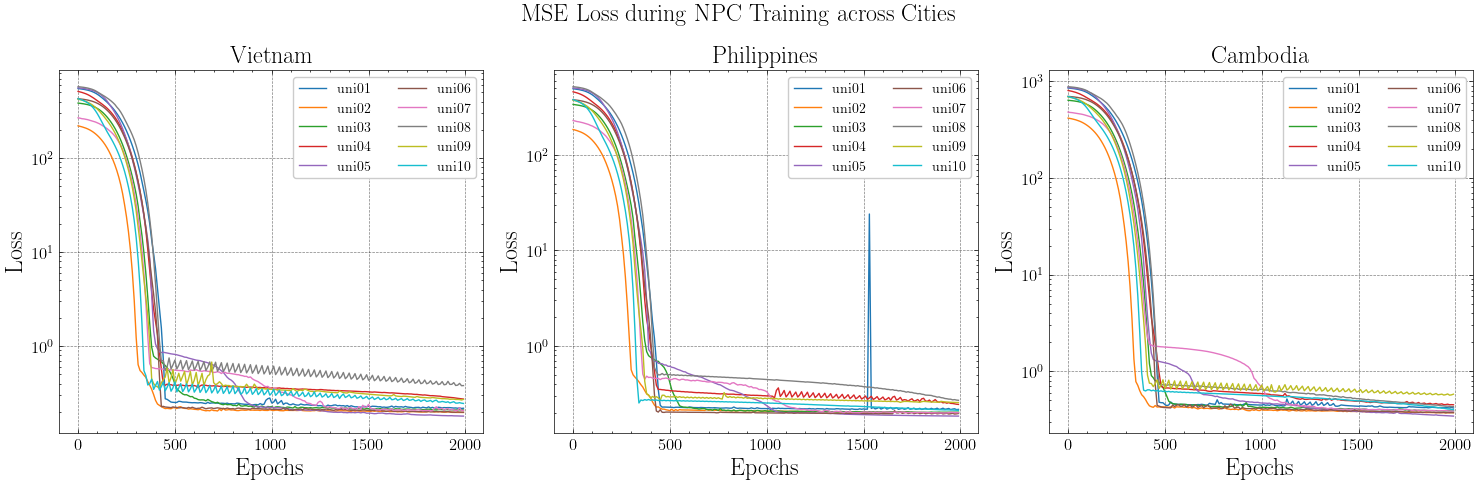

In [79]:
# Combined loss plots for 3 cities in one figure (1 row, 3 columns)
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Configuration for cities
cities = [
    {"name": "Vietnam", "folder": "vietnam", "ax": axes[0]},
    {"name": "Philippines", "folder": "philippines", "ax": axes[1]}, 
    {"name": "Cambodia", "folder": "cambodia", "ax": axes[2]}
]

colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct colors

for city in cities:
    ax = city["ax"]
    
    # Plot loss for each uni (1-10) for this city
    for i in range(1, 11):
        folder = f"{city['folder']}/data/uni{str(i).zfill(2)}"
        h5_path = os.path.join(folder, "data.h5")
        if not os.path.exists(h5_path):
            print(f"File not found: {h5_path}")
            continue
        
        with h5py.File(h5_path, "r") as hf:
            # Assume loss is shape (n_samples,) or (n_samples, 1)
            loss = hf["Dengue"]["loss"][:]
            if loss.ndim > 1:
                loss = loss.squeeze()
            x = np.arange(len(loss)) * 10  # Multiply x-axis by 10
            ax.plot(x, loss, label=f"uni{str(i).zfill(2)}", color=colors[i-1])
    
    # Set properties for each subplot
    ax.set_xlabel("Epochs", fontsize="xx-large")
    ax.set_ylabel("Loss", fontsize="xx-large")
    ax.set_title(f"{city['name']}", fontsize="xx-large")
    ax.set_yscale("log")  # Use log scale for y-axis
    ax.tick_params(labelsize='large')
    ax.legend(fontsize="medium", ncol=2)
    ax.grid(True, linestyle="--", alpha=0.5)

# Add overall title
fig.suptitle("MSE Loss during NPC Training across Cities", fontsize="xx-large", fontweight="bold")

plt.tight_layout()
plt.savefig("final_figures/revise_version/npc_loss_3_countries.tiff", dpi=900, format='tiff')
plt.show()

# Parameter ranges from Neural Parameter Calibration for MCMC

### Bello

In [80]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 11):
    folder = f"bello/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        print(f"Processed {h5_path}")

print("\nParameter ranges across all uni01-uni10 folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Processed bello/data/uni01/data.h5
Processed bello/data/uni02/data.h5
Processed bello/data/uni03/data.h5
Processed bello/data/uni04/data.h5
Processed bello/data/uni05/data.h5
Processed bello/data/uni06/data.h5
Processed bello/data/uni07/data.h5
Processed bello/data/uni08/data.h5
Processed bello/data/uni09/data.h5
Processed bello/data/uni10/data.h5

Parameter ranges across all uni01-uni10 folders:
Hi0: min=0.000005, max=2.275488
Me0: min=0.000007, max=2.144732
Hr0: min=0.000044, max=2.839061
Hs0: min=0.069471, max=2.674560
He0: min=0.078077, max=2.741943
Ms0: min=0.000171, max=3.048463
Mi0: min=0.000003, max=1.250669
beta_h: min=0.091781, max=1.363546
beta_m: min=0.046334, max=1.706547
gamma_h: min=0.000005, max=1.116707
lambda: min=0.000015, max=2.245631
mu_m: min=0.000000, max=1.078039
theta_h: min=0.073964, max=1.419167
theta_m: min=0.008861, max=1.011342


### Iquitos

In [81]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 11):
    folder = f"iquitos/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        print(f"Processed {h5_path}")

print("\nParameter ranges across all uni01-uni10 folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Processed iquitos/data/uni01/data.h5
Processed iquitos/data/uni02/data.h5
Processed iquitos/data/uni03/data.h5
Processed iquitos/data/uni04/data.h5
Processed iquitos/data/uni05/data.h5
Processed iquitos/data/uni06/data.h5
Processed iquitos/data/uni07/data.h5
Processed iquitos/data/uni08/data.h5
Processed iquitos/data/uni09/data.h5
Processed iquitos/data/uni10/data.h5

Parameter ranges across all uni01-uni10 folders:
Hi0: min=0.000002, max=2.201129
Me0: min=0.000004, max=2.109463
Hr0: min=0.000043, max=2.818763
Hs0: min=0.068991, max=3.249560
He0: min=0.080190, max=2.796118
Ms0: min=0.000220, max=2.513258
Mi0: min=0.000003, max=1.234392
beta_h: min=0.092616, max=1.219537
beta_m: min=0.048139, max=1.765099
gamma_h: min=0.000000, max=1.115463
lambda: min=0.000004, max=2.471828
mu_m: min=0.000001, max=1.081748
theta_h: min=0.062759, max=1.407776
theta_m: min=0.011172, max=0.997235


### San Juan

In [82]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 11):
    folder = f"sanjuan/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        print(f"Processed {h5_path}")

print("\nParameter ranges across all uni01-uni10 folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Processed sanjuan/data/uni01/data.h5
Processed sanjuan/data/uni02/data.h5
Processed sanjuan/data/uni03/data.h5
Processed sanjuan/data/uni04/data.h5
Processed sanjuan/data/uni05/data.h5
Processed sanjuan/data/uni06/data.h5
Processed sanjuan/data/uni07/data.h5
Processed sanjuan/data/uni08/data.h5
Processed sanjuan/data/uni09/data.h5
Processed sanjuan/data/uni10/data.h5

Parameter ranges across all uni01-uni10 folders:
Hi0: min=0.000004, max=2.598330
Me0: min=0.000001, max=2.411903
Hr0: min=0.000021, max=3.328683
Hs0: min=0.069180, max=3.210711
He0: min=0.079379, max=3.469993
Ms0: min=0.000038, max=2.366602
Mi0: min=0.000014, max=1.323977
beta_h: min=0.078089, max=1.390598
beta_m: min=0.045623, max=1.805687
gamma_h: min=0.000001, max=1.115954
lambda: min=0.000004, max=2.689426
mu_m: min=0.000003, max=1.080306
theta_h: min=0.090977, max=1.451898
theta_m: min=0.015543, max=1.070861


### Vietnam

In [83]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 11):
    folder = f"vietnam/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        print(f"Processed {h5_path}")

print("\nParameter ranges across all uni01-uni10 folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Processed vietnam/data/uni01/data.h5
Processed vietnam/data/uni02/data.h5
Processed vietnam/data/uni03/data.h5
Processed vietnam/data/uni04/data.h5
Processed vietnam/data/uni05/data.h5
Processed vietnam/data/uni06/data.h5
Processed vietnam/data/uni07/data.h5
Processed vietnam/data/uni08/data.h5
Processed vietnam/data/uni09/data.h5
Processed vietnam/data/uni10/data.h5

Parameter ranges across all uni01-uni10 folders:
Hi0: min=0.000002, max=2.326189
Me0: min=0.000000, max=2.234832
Hr0: min=0.000009, max=3.150932
Hs0: min=0.072022, max=2.860070
He0: min=0.061242, max=2.937912
Ms0: min=0.000056, max=2.871681
Mi0: min=0.000001, max=1.284510
beta_h: min=0.086550, max=1.359254
beta_m: min=0.034951, max=1.693779
gamma_h: min=0.000004, max=1.124185
lambda: min=0.000006, max=2.197881
mu_m: min=0.000003, max=1.055268
theta_h: min=0.096893, max=1.426212
theta_m: min=0.014797, max=1.042877


### Cambodia

In [84]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 11):
    folder = f"cambodia/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        print(f"Processed {h5_path}")

print("\nParameter ranges across all uni01-uni10 folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Processed cambodia/data/uni01/data.h5
Processed cambodia/data/uni02/data.h5
Processed cambodia/data/uni03/data.h5
Processed cambodia/data/uni04/data.h5
Processed cambodia/data/uni05/data.h5
Processed cambodia/data/uni06/data.h5
Processed cambodia/data/uni07/data.h5
Processed cambodia/data/uni08/data.h5
Processed cambodia/data/uni09/data.h5
Processed cambodia/data/uni10/data.h5

Parameter ranges across all uni01-uni10 folders:
Hi0: min=0.000007, max=2.673657
Me0: min=0.000003, max=2.380507
Hr0: min=0.000010, max=3.252257
Hs0: min=0.071029, max=3.340985
He0: min=0.068925, max=3.494425
Ms0: min=0.000105, max=2.325986
Mi0: min=0.000007, max=1.348711
beta_h: min=0.088680, max=1.632070
beta_m: min=0.039445, max=1.825927
gamma_h: min=0.000004, max=1.120955
lambda: min=0.000002, max=2.523237
mu_m: min=0.000001, max=1.064016
theta_h: min=0.083292, max=1.449913
theta_m: min=0.018091, max=1.085231


### Philippines

In [85]:
import h5py
import numpy as np
import os

param_names = ['Hi0', 'Me0', 'Hr0', 'Hs0', 'He0', 'Ms0', 'Mi0', 
               'beta_h', 'beta_m', 'gamma_h', 'lambda', 'mu_m', 'theta_h', 'theta_m']

# Store min and max for each parameter across all folders
param_min = {name: np.inf for name in param_names}
param_max = {name: -np.inf for name in param_names}

for i in range(1, 11):
    folder = f"philippines/data/uni{str(i).zfill(2)}"
    h5_path = os.path.join(folder, "data.h5")
    if not os.path.exists(h5_path):
        print(f"File not found: {h5_path}")
        continue
    with h5py.File(h5_path, "r") as hf:
        params = hf["Dengue"]["parameters"][:]  # shape: (n_samples, n_parameters)
        for idx, name in enumerate(param_names):
            values = params[:, idx]
            param_min[name] = min(param_min[name], values.min())
            param_max[name] = max(param_max[name], values.max())
        print(f"Processed {h5_path}")

print("\nParameter ranges across all uni01-uni10 folders:")
for name in param_names:
    print(f"{name}: min={param_min[name]:.6f}, max={param_max[name]:.6f}")

Processed philippines/data/uni01/data.h5
Processed philippines/data/uni02/data.h5
Processed philippines/data/uni03/data.h5
Processed philippines/data/uni04/data.h5
Processed philippines/data/uni05/data.h5
Processed philippines/data/uni06/data.h5
Processed philippines/data/uni07/data.h5
Processed philippines/data/uni08/data.h5
Processed philippines/data/uni09/data.h5
Processed philippines/data/uni10/data.h5

Parameter ranges across all uni01-uni10 folders:
Hi0: min=0.000000, max=2.252554
Me0: min=0.000003, max=2.196068
Hr0: min=0.000087, max=2.874603
Hs0: min=0.072159, max=2.704505
He0: min=0.060443, max=2.790906
Ms0: min=0.000079, max=2.486444
Mi0: min=0.000005, max=1.287299
beta_h: min=0.086356, max=1.325014
beta_m: min=0.034614, max=1.605706
gamma_h: min=0.000008, max=1.124651
lambda: min=0.000014, max=2.024584
mu_m: min=0.000000, max=1.054664
theta_h: min=0.097843, max=1.424559
theta_m: min=0.013334, max=1.039641
